#Initialize Global Parameters

In [ ]:
!pip install linearmodels


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 6.2 MB/s eta 0:00:00


In [ ]:
#Copany Region mapping based on folder name s
company_region_mapping = {
    "India Life Insurance": "Asia",
    "People Insurance China": "Asia",
    "New China Life": "Asia",
    "MSAD": "Asia",
    "Ping An": "Asia",
    "Japan Post": "Asia",
    "Daichi": "Asia",
    "Sompo": "Asia",
    "China Life": "Asia",
    "Tokio Marine": "Asia",
    "Zurich": "Europe",
    "Swiss RE": "Europe",
    "Chubb": "Europe",
    "Allianz": "Europe",
    "Munich RE": "Europe",
    "Assicurazioni Generali": "Europe",
    "Talanx": "Europe",
    "AXA": "Europe",
    "Power Corp Canada": "N. America",
    "Prudentials": "N. America",
    "AIG": "N. America",
    "Allstate": "N. America",
    "Progressive": "N. America",
    "Travelers": "N. America",
    "MetLife": "N. America"
}

In [ ]:
# Mapping known abbreviations to full names (expand as needed)
abbr_to_full = {
    "SR": "Swiss RE",
    "Daichi": "Daichi",
    "LifeIndia": "India Life Insurance",
    "MSAD": "MSAD",
    "TM": "Tokio Marine",
    "AIG": "AIG",
    "MR": "Munich RE",
    "Allianz": "Allianz",
    "ALLI": "Allianz",
    "AGEN": "Assicurazioni Generali",
    "AXA": "AXA",
    "CHUBB": "Chubb",
    "TAL": "Talanx",
    "ALL": "Allstate",
    "MET": "MetLife",
    "PCC": "Power Corp Canada",
    "PRO": "Progressive",
    "PRU": "Prudentials",
    "TRA": "Travelers",
    "Chinalife": "China Life",
    "CL": "China Life",
    "NewChinaLife": "New China Life",
    "NCL": "New China Life",
    "PIC": "People Insurance China",
    "PA":"Ping An",
    "SO":"Sompo",
    "ZUR":"Zurich"
}

def map_abbreviation_to_full(abbreviation, choices, threshold=80):
    match, score = process.extractOne(abbreviation, choices)
    if score >= threshold:
        return match
    else:
        return abbreviation  # fallback if no good match

def get_full_company_name(abbr):
    # Try exact mapping first
    if abbr in abbr_to_full:
        return abbr_to_full[abbr]
    # Otherwise fuzzy match from known full names
    return map_abbreviation_to_full(abbr, list(abbr_to_full.values()))

In [ ]:
# Your mapping dictionary (use the keys you expect in your 'Company' column)
company_region_mapping = {
    "India Life Insurance": "Asia",
    "People Insurance China": "Asia",
    "New China Life": "Asia",
    "MSAD": "Asia",
    "Ping An": "Asia",
    "Japan Post": "Asia",
    "Daichi": "Asia",
    "Sompo": "Asia",
    "China Life": "Asia",
    "Tokio Marine": "Asia",
    "Zurich": "Europe",
    "Swiss RE": "Europe",
    "Chubb": "Europe",
    "Allianz": "Europe",
    "Munich RE": "Europe",
    "Assicurazioni Generali": "Europe",
    "Talanx": "Europe",
    "AXA": "Europe",
    "Power Corp Canada": "N. America",
    "Prudentials": "N. America",
    "AIG": "N. America",
    "Allstate": "N. America",
    "Progressive": "N. America",
    "Travelers": "N. America",
    "MetLife": "N. America"
}

def map_company_to_region(company_name, mapping):
    return mapping.get(company_name, "Unknown")



# Extract data from Bloomberg Terminal

## Extract Market Cap and Total Assets and calculate TobinsQ

In [ ]:
import os
import pandas as pd
import numpy as np
from IPython.display import display
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

folder_path = '/content/drive/MyDrive/phd/BloombergData'

# Check if the folder exists
if not os.path.exists(folder_path):
    print(f"Error: The specified folder does not exist: {folder_path}")
    print("Please ensure your Google Drive is mounted correctly and the folder path is accurate.")
    print("You might need to create the 'phd' and 'BloombergData' folders in your Google Drive's 'My Drive'.")
else:
    print(f"Accessing data from: {folder_path}")

def extract_financials(file_path, label, start_year=2012, end_year=2024):
    df = pd.read_excel(file_path, header=None)

    # Find row index for label
    row_idx = None
    for idx, val in enumerate(df.iloc[:, 0]):
        if isinstance(val, str) and label.lower() in val.lower():
            row_idx = idx
            break
    if row_idx is None:
        print(f"'{label}' row not found in {file_path}")
        return None, None

    # Find fiscal year header row
    fy_header_row = None    # row where FYxxxx headers sit
    for i in range(10):
        for val in df.iloc[i]:
            if isinstance(val, str) and val.strip().startswith('FY'):
                fy_header_row = i
                break
        if fy_header_row is not None:
            break
    if fy_header_row is None:
        print(f"Fiscal Year header row not found in {file_path}")
        return None, None

    # Find FY columns in range
    available_cols = []
    available_years = []
    for col_idx, val in enumerate(df.iloc[fy_header_row]):
        if isinstance(val, str) and val.strip().startswith('FY'):
            try:
                year = int(val.strip().replace('FY', '').strip())
                if start_year <= year <= end_year:
                    available_cols.append(col_idx)
                    available_years.append(year)
            except:
                continue

    if not available_cols:
        print(f"No fiscal year columns in range FY{start_year}-FY{end_year} found in {file_path}")
        return None, None

    # Clean and convert values to float
    raw_values = df.iloc[row_idx, available_cols].values
    cleaned_values = []
    for v in raw_values:
        try:
            cleaned_values.append(float(v))
        except (ValueError, TypeError):
            cleaned_values.append(np.nan)
    values = cleaned_values

    return available_years, values


def process_company(company_name, cap_path, ass_path):
    # Market value of equity (Market Cap) from _CAP file
    cap_years, cap_values = extract_financials(cap_path, "Market Capitalization")

    # Total Assets from _ASS file
    ass_years, ass_values = extract_financials(ass_path, "Total Assets")

    # Total Liabilities from _ASS file
    liab_years, liab_values = extract_financials(ass_path, "Total Liabilities")

    if cap_years is None or ass_years is None:
        print(f"Skipping {company_name} due to missing Market Cap or Total Assets.")
        return None

    # Find common years available in both Market Cap and Total Assets
    common_years = sorted(set(cap_years).intersection(set(ass_years)))
    if not common_years:
        print(f"No overlapping fiscal years for {company_name}")
        return None

    # Map years to values for quick lookup
    cap_map = dict(zip(cap_years, cap_values))
    ass_map = dict(zip(ass_years, ass_values))
    liab_map = dict(zip(liab_years, liab_values)) if liab_years is not None else {}

    data = []
    for year in common_years:
        market_cap = cap_map.get(year)
        total_assets = ass_map.get(year)
        total_liab = liab_map.get(year) if year in liab_map else np.nan

        # Compute Tobin's Q
        if total_assets is None or np.isnan(total_assets) or total_assets == 0:
            tobin_q = np.nan
        else:
            # If Total Liabilities available, use full formula: (MC + Liab) / Assets
            if total_liab is not None and not np.isnan(total_liab):
                tobin_q = (market_cap + total_liab) / total_assets if market_cap is not None else np.nan
            else:
                # Fallback: MC / Assets (simplified Q)
                tobin_q = market_cap / total_assets if market_cap is not None else np.nan

        data.append({
            'Company': company_name,
            'Year': year,
            'Market Capitalization (Million USD)': market_cap,
            'Total Assets (Million USD)': total_assets,
            'Total Liabilities (Million USD)': total_liab,
            'Tobins Q': tobin_q
        })

    return pd.DataFrame(data)


def main(folder_path):
    tobinsq_df = pd.DataFrame()

    files = os.listdir(folder_path)
    cap_files = [f for f in files if f.endswith('_CAP.xlsx')]

    for cap_file in cap_files:
        company = cap_file.replace('_CAP.xlsx', '')
        ass_file = f"{company}_ASS.xlsx"

        cap_path = os.path.join(folder_path, cap_file)
        ass_path = os.path.join(folder_path, ass_file)

        if not os.path.exists(ass_path):
            print(f"Assets file missing for {company}")
            continue

        print(f"Processing {company}...")
        df = process_company(company, cap_path, ass_path)
        if df is not None:
            tobinsq_df = pd.concat([tobinsq_df, df], ignore_index=True)

    # Map to full company name & region (your existing helper functions)
    tobinsq_df['Company'] = tobinsq_df['Company'].apply(get_full_company_name)
    tobinsq_df['Region'] = tobinsq_df['Company'].apply(
        lambda x: map_company_to_region(x, company_region_mapping)
    )

    # Sort the data by Company alphabetically
    tobinsq_df = tobinsq_df.sort_values(by='Company')

    print("\ntobinsq_df DataFrame with full company names:")
    display(tobinsq_df)

    # Save to Excel and CSV
    output_path_xlsx = os.path.join('/content/drive/MyDrive/phd/Data/', 'TobinsQ_Results_FullNames.xlsx')
    tobinsq_df.to_excel(output_path_xlsx, index=False)
    print(f"\nSaved tobinsq_df results with full company names to {output_path_xlsx}")

    output_path_csv = os.path.join('/content/drive/MyDrive/phd/Data/', 'TobinsQ_Results_FullNames.csv')
    tobinsq_df.to_csv(output_path_csv, index=False)
    print(f"\nSaved tobinsq_df results with full company names to {output_path_csv}")

    return tobinsq_df

# Run main and display final dataframe
tobinsq_df = main(folder_path)


Mounted at /content/drive
Accessing data from: /content/drive/MyDrive/phd/BloombergData
Processing SR...
Processing Daichi...
Processing LifeIndia...
Processing MSAD...
Processing Chinalife...
Processing NewChinaLife...
Processing PIC...
Processing PA...
Processing SO...
Processing TM...
Processing Allianz...
Processing AGEN...
Processing AXA...
Processing CHUBB...
Processing TAL...
Processing ALL...
Processing AIG...
Processing MET...
Processing PCC...
Processing PRO...
Processing PRU...
Processing TRA...
Processing MR...
Processing ZUR...

tobinsq_df DataFrame with full company names:


,Company,Year,Market Capitalization (Million USD),Total Assets (Million USD),Total Liabilities (Million USD),Tobins Q,Region
213,AIG,2024,44128.4081,161322.0,118772.0,1.009784,N. America
210,AIG,2021,46550.5635,596112.0,527200.0,0.962488,N. America
209,AIG,2020,32618.5877,586481.0,519282.0,0.941037,N. America
208,AIG,2019,44657.0503,525064.0,457637.0,0.956634,N. America
212,AIG,2023,46668.8945,539306.0,488005.0,0.991411,N. America
...,...,...,...,...,...,...,...
294,Zurich,2014,46748.5806,406529.0,369699.0,1.024398,Europe
293,Zurich,2013,42986.0210,415053.0,380319.0,1.019882,Europe
303,Zurich,2023,75426.6912,361382.0,335103.0,1.135999,Europe
297,Zurich,2017,46104.5657,422065.0,387172.0,1.026564,Europe



Saved tobinsq_df results with full company names to /content/drive/MyDrive/phd/Data/TobinsQ_Results_FullNames.xlsx

Saved tobinsq_df results with full company names to /content/drive/MyDrive/phd/Data/TobinsQ_Results_FullNames.csv


/tmp/ipykernel_812/376250334.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Year'] = df['Year'].astype(int)


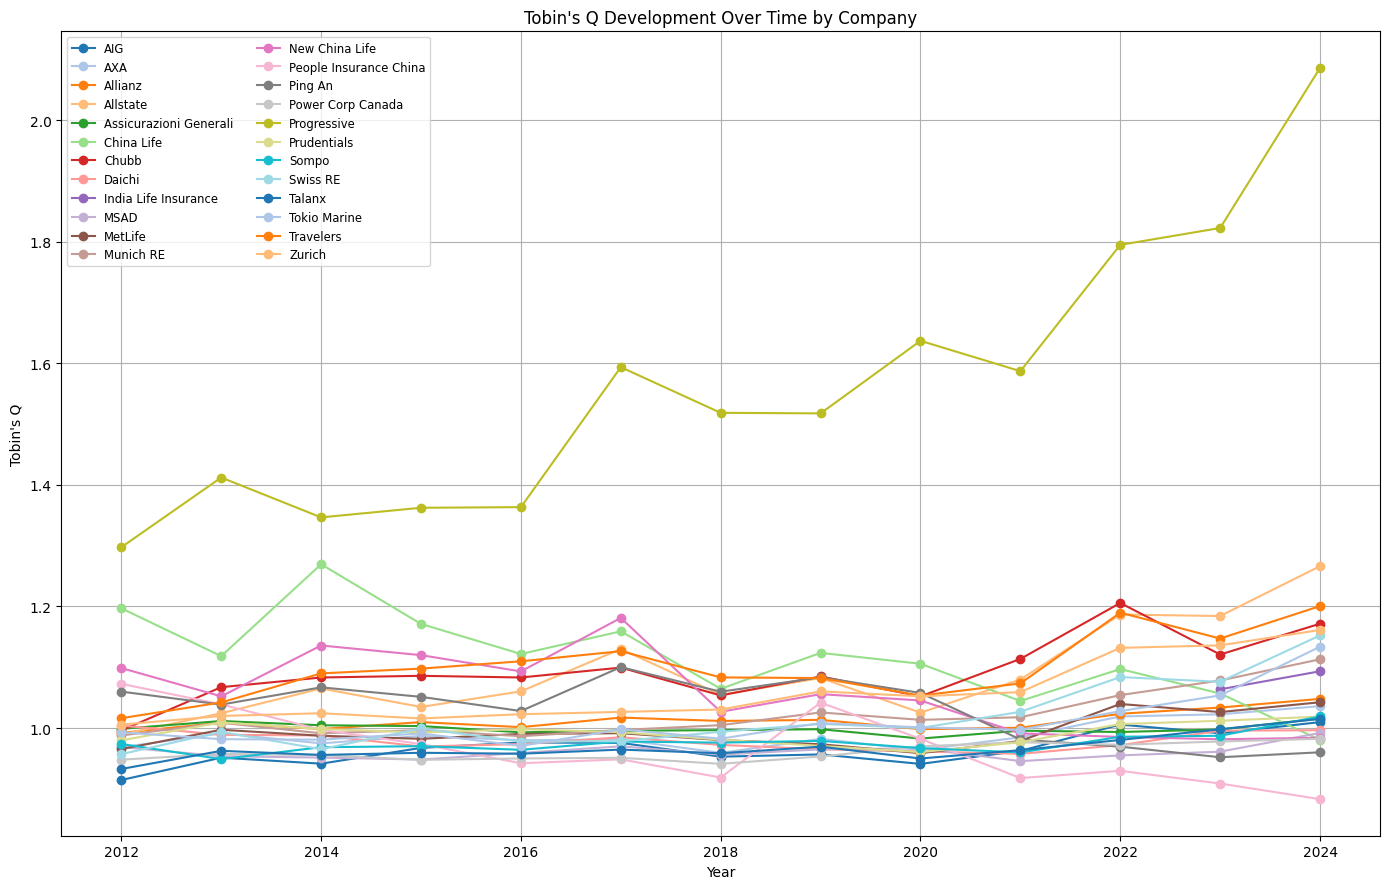

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_tobins_q(df):
    df = df.dropna(subset=["Tobins Q"])
    df['Year'] = df['Year'].astype(int)
    df = df.sort_values(by=['Company', 'Year'])

    companies = df['Company'].unique()
    n = len(companies)

    # Get a colormap with enough distinct colors
    cmap = plt.get_cmap('tab20')
    colors = [cmap(i % 20) for i in range(n)]  # cycle if >20 companies

    plt.figure(figsize=(14, 9))
    for i, company in enumerate(companies):
        company_data = df[df['Company'] == company]
        plt.plot(company_data['Year'], company_data["Tobins Q"],
                 marker='o', label=company, color=colors[i])

    plt.title("Tobin's Q Development Over Time by Company")
    plt.xlabel("Year")
    plt.ylabel("Tobin's Q")
    plt.legend(loc='best', fontsize='small', ncol=2)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Call the function with your DataFrame
plot_tobins_q(tobinsq_df)


/tmp/ipykernel_812/1467678565.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Year'] = df['Year'].astype(int)


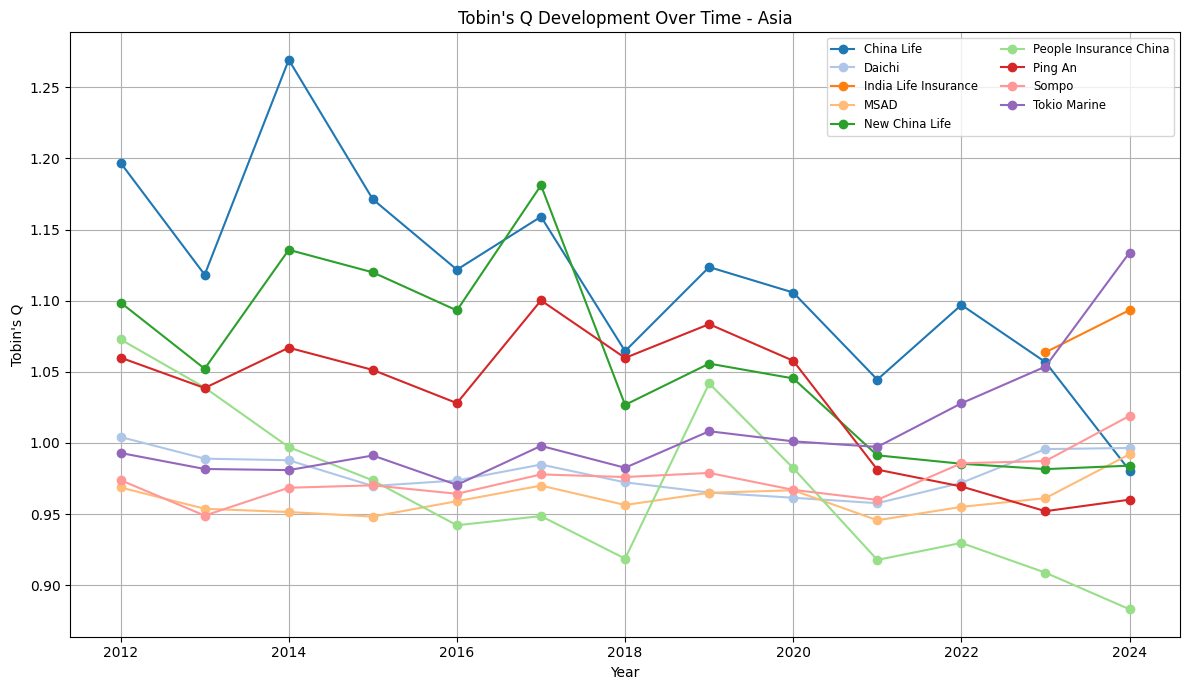

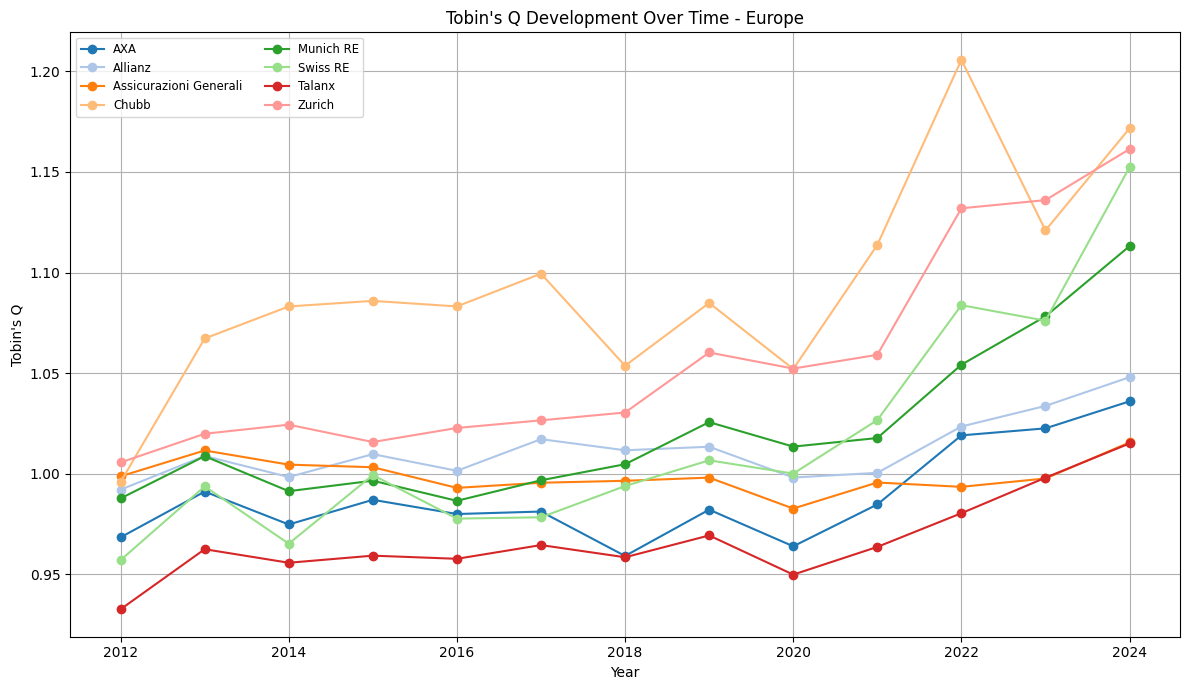

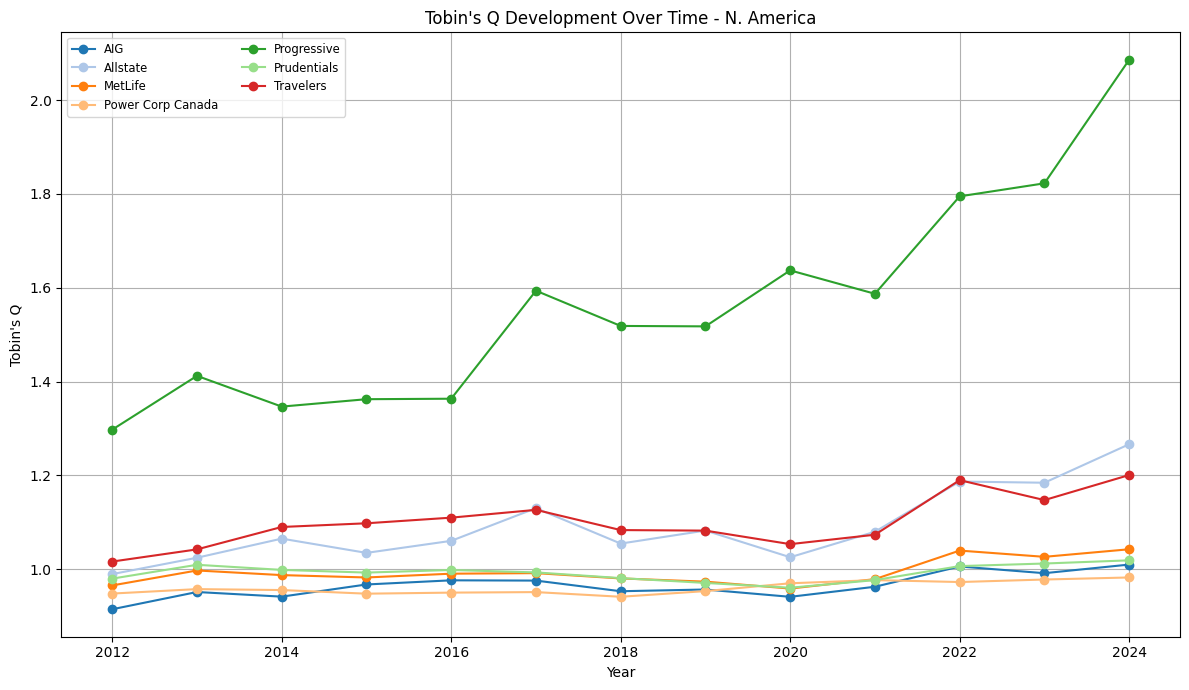

In [ ]:
import matplotlib.pyplot as plt

def plot_tobins_q_by_region_separately(df):
    df = df.dropna(subset=["Tobins Q"])
    df['Year'] = df['Year'].astype(int)
    df = df.sort_values(by=['Company', 'Year'])

    regions = ['Asia', 'Europe', 'N. America']

    for region in regions:
        region_df = df[df['Region'] == region]
        if region_df.empty:
            print(f"No data for region: {region}")
            continue

        plt.figure(figsize=(12, 7))
        companies = region_df['Company'].unique()

        # Use a colormap with enough distinct colors
        cmap = plt.get_cmap('tab20')
        colors = [cmap(i % 20) for i in range(len(companies))]

        for i, company in enumerate(companies):
            comp_data = region_df[region_df['Company'] == company]
            plt.plot(comp_data['Year'], comp_data["Tobins Q"], marker='o', label=company, color=colors[i])

        plt.title(f"Tobin's Q Development Over Time - {region}")
        plt.xlabel("Year")
        plt.ylabel("Tobin's Q")
        plt.legend(loc='best', fontsize='small', ncol=2)
        plt.grid(True)
        plt.tight_layout()
        plt.show()

# Call this with your dataframe
plot_tobins_q_by_region_separately(tobinsq_df)


## Extract ESG data

In [ ]:
import os
import pandas as pd
import numpy as np
from IPython.display import display
from zipfile import BadZipFile # Import BadZipFile

folder_path = '/content/drive/MyDrive/phd/BloombergData'

def extract_financials(file_path, label, start_year=2012, end_year=2024):
    try:
        df = pd.read_excel(file_path, header=None, engine='openpyxl')
    except BadZipFile:
        print(f"Error: '{file_path}' is a corrupted or invalid Excel file. Skipping this file.")
        return None, None
    except Exception as e:
        print(f"An error occurred while reading '{file_path}': {e}")
        return None, None

    # Find row index for label
    row_idx = None
    for idx, val in enumerate(df.iloc[:, 0]):
        if isinstance(val, str) and label.lower() in val.lower():
            row_idx = idx
            break
    if row_idx is None:
        print(f"'{label}' row not found in {file_path}")
        return None, None

    # Find fiscal year header row
    fy_header_row = None
    for i in range(10):
        for val in df.iloc[i]:
            if isinstance(val, str) and val.strip().startswith('FY'):
                fy_header_row = i
                break
        if fy_header_row is not None:
            break
    if fy_header_row is None:
        print(f"Fiscal Year header row not found in {file_path}")
        return None, None

    # Find FY columns in range
    available_cols = []
    available_years = []
    for col_idx, val in enumerate(df.iloc[fy_header_row]):
        if isinstance(val, str) and val.strip().startswith('FY'):
            try:
                year = int(val.strip().replace('FY', '').strip())
                if start_year <= year <= end_year:
                    available_cols.append(col_idx)
                    available_years.append(year)
            except:
                continue

    if not available_cols:
        print(f"No fiscal year columns in range FY{start_year}-FY{end_year} found in {file_path}")
        return None, None

    # Clean and convert values to float
    raw_values = df.iloc[row_idx, available_cols].values
    cleaned_values = []
    for v in raw_values:
        try:
            cleaned_values.append(float(v))
        except (ValueError, TypeError):
            cleaned_values.append(np.nan)
    values = cleaned_values

    return available_years, values

def process_company(company_name, cap_path, ass_path, esg_path):
    # Extract Market Capitalization and Total Assets
    cap_years, cap_values = extract_financials(cap_path, "Market Capitalization")
    ass_years, ass_values = extract_financials(ass_path, "Total Assets")

    # Extract individual ESG scores
    environmental_years, environmental_scores = extract_financials(esg_path, label="Environmental Disclosure Score")
    social_years, social_scores = extract_financials(esg_path, label="Social Disclosure Score")
    governance_years, governance_scores = extract_financials(esg_path, label="Governance Disclosure Score")
    besg_years, besg_scores = extract_financials(esg_path, label="BESG ESG Score")


    # Check if any crucial data is missing due to file errors or missing labels
    if cap_years is None or ass_years is None or environmental_years is None or social_years is None or governance_years is None or besg_years is None:
        print(f"Skipping {company_name} due to missing or unreadable financial/ESG data.")
        return None

    # Find common years available in both financials and ESG data
    # Ensure all required years are available from all sources
    common_years_set = set(cap_years).intersection(set(ass_years)).intersection(set(environmental_years)).intersection(set(social_years)).intersection(set(governance_years)).intersection(set(besg_years))
    common_years = sorted(list(common_years_set))

    if not common_years:
        print(f"No overlapping fiscal years for {company_name} across all required data points.")
        return None

    # Map years to index for quick lookup
    cap_map = dict(zip(cap_years, cap_values))
    ass_map = dict(zip(ass_years, ass_values))
    environmental_map = dict(zip(environmental_years, environmental_scores))
    social_map = dict(zip(social_years, social_scores))
    governance_map = dict(zip(governance_years, governance_scores))
    besg_map = dict(zip(besg_years, besg_scores))


    data = []
    for year in common_years:
        market_cap = cap_map.get(year)
        total_assets = ass_map.get(year)
        environmental_score = environmental_map.get(year)
        social_score = social_map.get(year)
        governance_score = governance_map.get(year)
        besg_score = besg_map.get(year)

        # Calculate ESG Disclosure Score by averaging the three scores
        if all(score is not None and not np.isnan(score) for score in [environmental_score, social_score, governance_score]):
            esg_score = (environmental_score + social_score + governance_score) / 3
        else:
            esg_score = np.nan  # If any score is missing, set ESG Disclosure Score as NaN

        if total_assets == 0 or total_assets is None or np.isnan(total_assets):
            tobin_q = np.nan
        else:
            tobin_q = market_cap / total_assets if market_cap is not None else np.nan

        # Append the data
        data.append({
            'Company': company_name,
            'Year': year,
            'Market Capitalization (Million USD)': market_cap,
            'Total Assets (Million USD)': total_assets,
            'Tobins Q': tobin_q,
            'ESG Disclosure Score': esg_score,
            'Environmental Disclosure Score': environmental_score,
            'Social Disclosure Score': social_score,
            'Governance Disclosure Score': governance_score,
            'BESG ESG Score': besg_score   # NEW FIELD

        })

    return pd.DataFrame(data)


def main(folder_path):
    tobinsq_df = pd.DataFrame()

    files = os.listdir(folder_path)
    cap_files = [f for f in files if f.endswith('_CAP.xlsx')]

    for cap_file in cap_files:
        company = cap_file.replace('_CAP.xlsx', '')
        ass_file = f"{company}_ASS.xlsx"
        esg_file = f"{company}_ESG.xlsx"  # Adding logic for ESG file

        cap_path = os.path.join(folder_path, cap_file)
        ass_path = os.path.join(folder_path, ass_file)
        esg_path = os.path.join(folder_path, esg_file)

        if not os.path.exists(ass_path):
            print(f"Assets file missing for {company}")
            continue
        if not os.path.exists(esg_path):
            print(f"ESG file missing for {company}")
            continue

        print(f"Processing {company}...")

        # Call the updated process_company function with esg_path as an argument
        df = process_company(company, cap_path, ass_path, esg_path)
        if df is not None:
            tobinsq_df = pd.concat([tobinsq_df, df], ignore_index=True)

    # Add full company name column via fuzzy matching (if required)
    tobinsq_df['Company'] = tobinsq_df['Company'].apply(get_full_company_name)
    tobinsq_df['Region'] = tobinsq_df['Company'].apply(lambda x: map_company_to_region(x, company_region_mapping))

    # Sort the data by Company alphabetically
    tobinsq_df = tobinsq_df.sort_values(by='Company')

    print("\ntobinsq_df DataFrame with full company names:")
    display(tobinsq_df)

    # Save the resulting DataFrame to an Excel file
    output_path = os.path.join(folder_path, 'TobinsQ_Results_FullNames.xlsx')
    tobinsq_df.to_excel(output_path, index=False)
    print(f"\nSaved tobinsq_df results with full company names to {output_path}")

    return tobinsq_df


# Run main and display final dataframe
tobinsq_df = main(folder_path)

Processing SR...
Processing Daichi...
Processing LifeIndia...
Processing MSAD...
Processing Chinalife...
Processing NewChinaLife...
Processing PIC...
Processing PA...
Processing SO...
Processing TM...
Processing Allianz...
Processing AGEN...
Processing AXA...
Processing CHUBB...
Processing TAL...
Processing ALL...
Processing AIG...
Processing MET...
Processing PCC...
Processing PRO...
Processing PRU...
Processing TRA...
Processing MR...
Processing ZUR...

tobinsq_df DataFrame with full company names:


,Company,Year,Market Capitalization (Million USD),Total Assets (Million USD),Tobins Q,ESG Disclosure Score,Environmental Disclosure Score,Social Disclosure Score,Governance Disclosure Score,BESG ESG Score,Region
209,AIG,2024,44128.4081,161322.0,0.273542,NaN,NaN,NaN,NaN,NaN,N. America
206,AIG,2021,46550.5635,596112.0,0.078090,49.676000,30.2326,31.3180,87.4774,3.05,N. America
205,AIG,2020,32618.5877,586481.0,0.055617,44.711333,20.0544,26.6022,87.4774,1.87,N. America
204,AIG,2019,44657.0503,525064.0,0.085051,39.783867,20.0544,11.8198,87.4774,1.98,N. America
203,AIG,2018,34153.0776,491984.0,0.069419,38.364333,15.7958,11.8198,87.4774,1.85,N. America
...,...,...,...,...,...,...,...,...,...,...,...
290,Zurich,2014,46748.5806,406529.0,0.114994,44.879800,9.3325,33.5248,91.7821,NaN,Europe
289,Zurich,2013,42986.0210,415053.0,0.103568,39.187067,7.6110,18.1681,91.7821,NaN,Europe
299,Zurich,2023,75426.6912,361382.0,0.208717,NaN,NaN,NaN,NaN,NaN,Europe
293,Zurich,2017,46104.5657,422065.0,0.109236,49.444567,35.9710,19.1959,93.1668,2.16,Europe



Saved tobinsq_df results with full company names to /content/drive/MyDrive/phd/BloombergData/TobinsQ_Results_FullNames.xlsx


    Company  Year  Market Capitalization (Million USD)  \
209     AIG  2024                           44128.4081   
206     AIG  2021                           46550.5635   
205     AIG  2020                           32618.5877   
204     AIG  2019                           44657.0503   
203     AIG  2018                           34153.0776   

     Total Assets (Million USD)  Tobins Q  ESG Disclosure Score  \
209                    161322.0  0.273542                   NaN   
206                    596112.0  0.078090             49.676000   
205                    586481.0  0.055617             44.711333   
204                    525064.0  0.085051             39.783867   
203                    491984.0  0.069419             38.364333   

     Environmental Disclosure Score  Social Disclosure Score  \
209                             NaN                      NaN   
206                         30.2326                  31.3180   
205                         20.0544                  26.

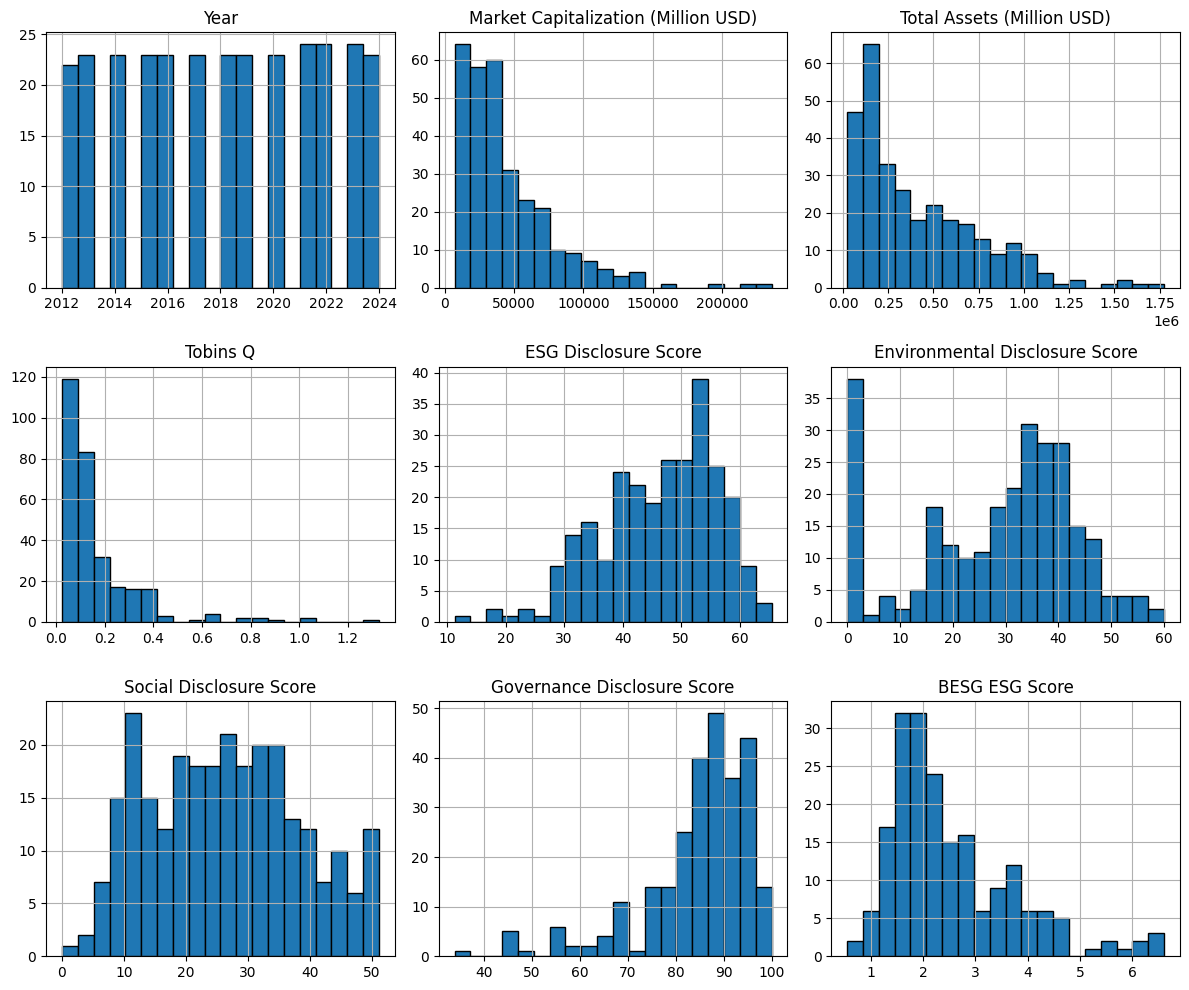

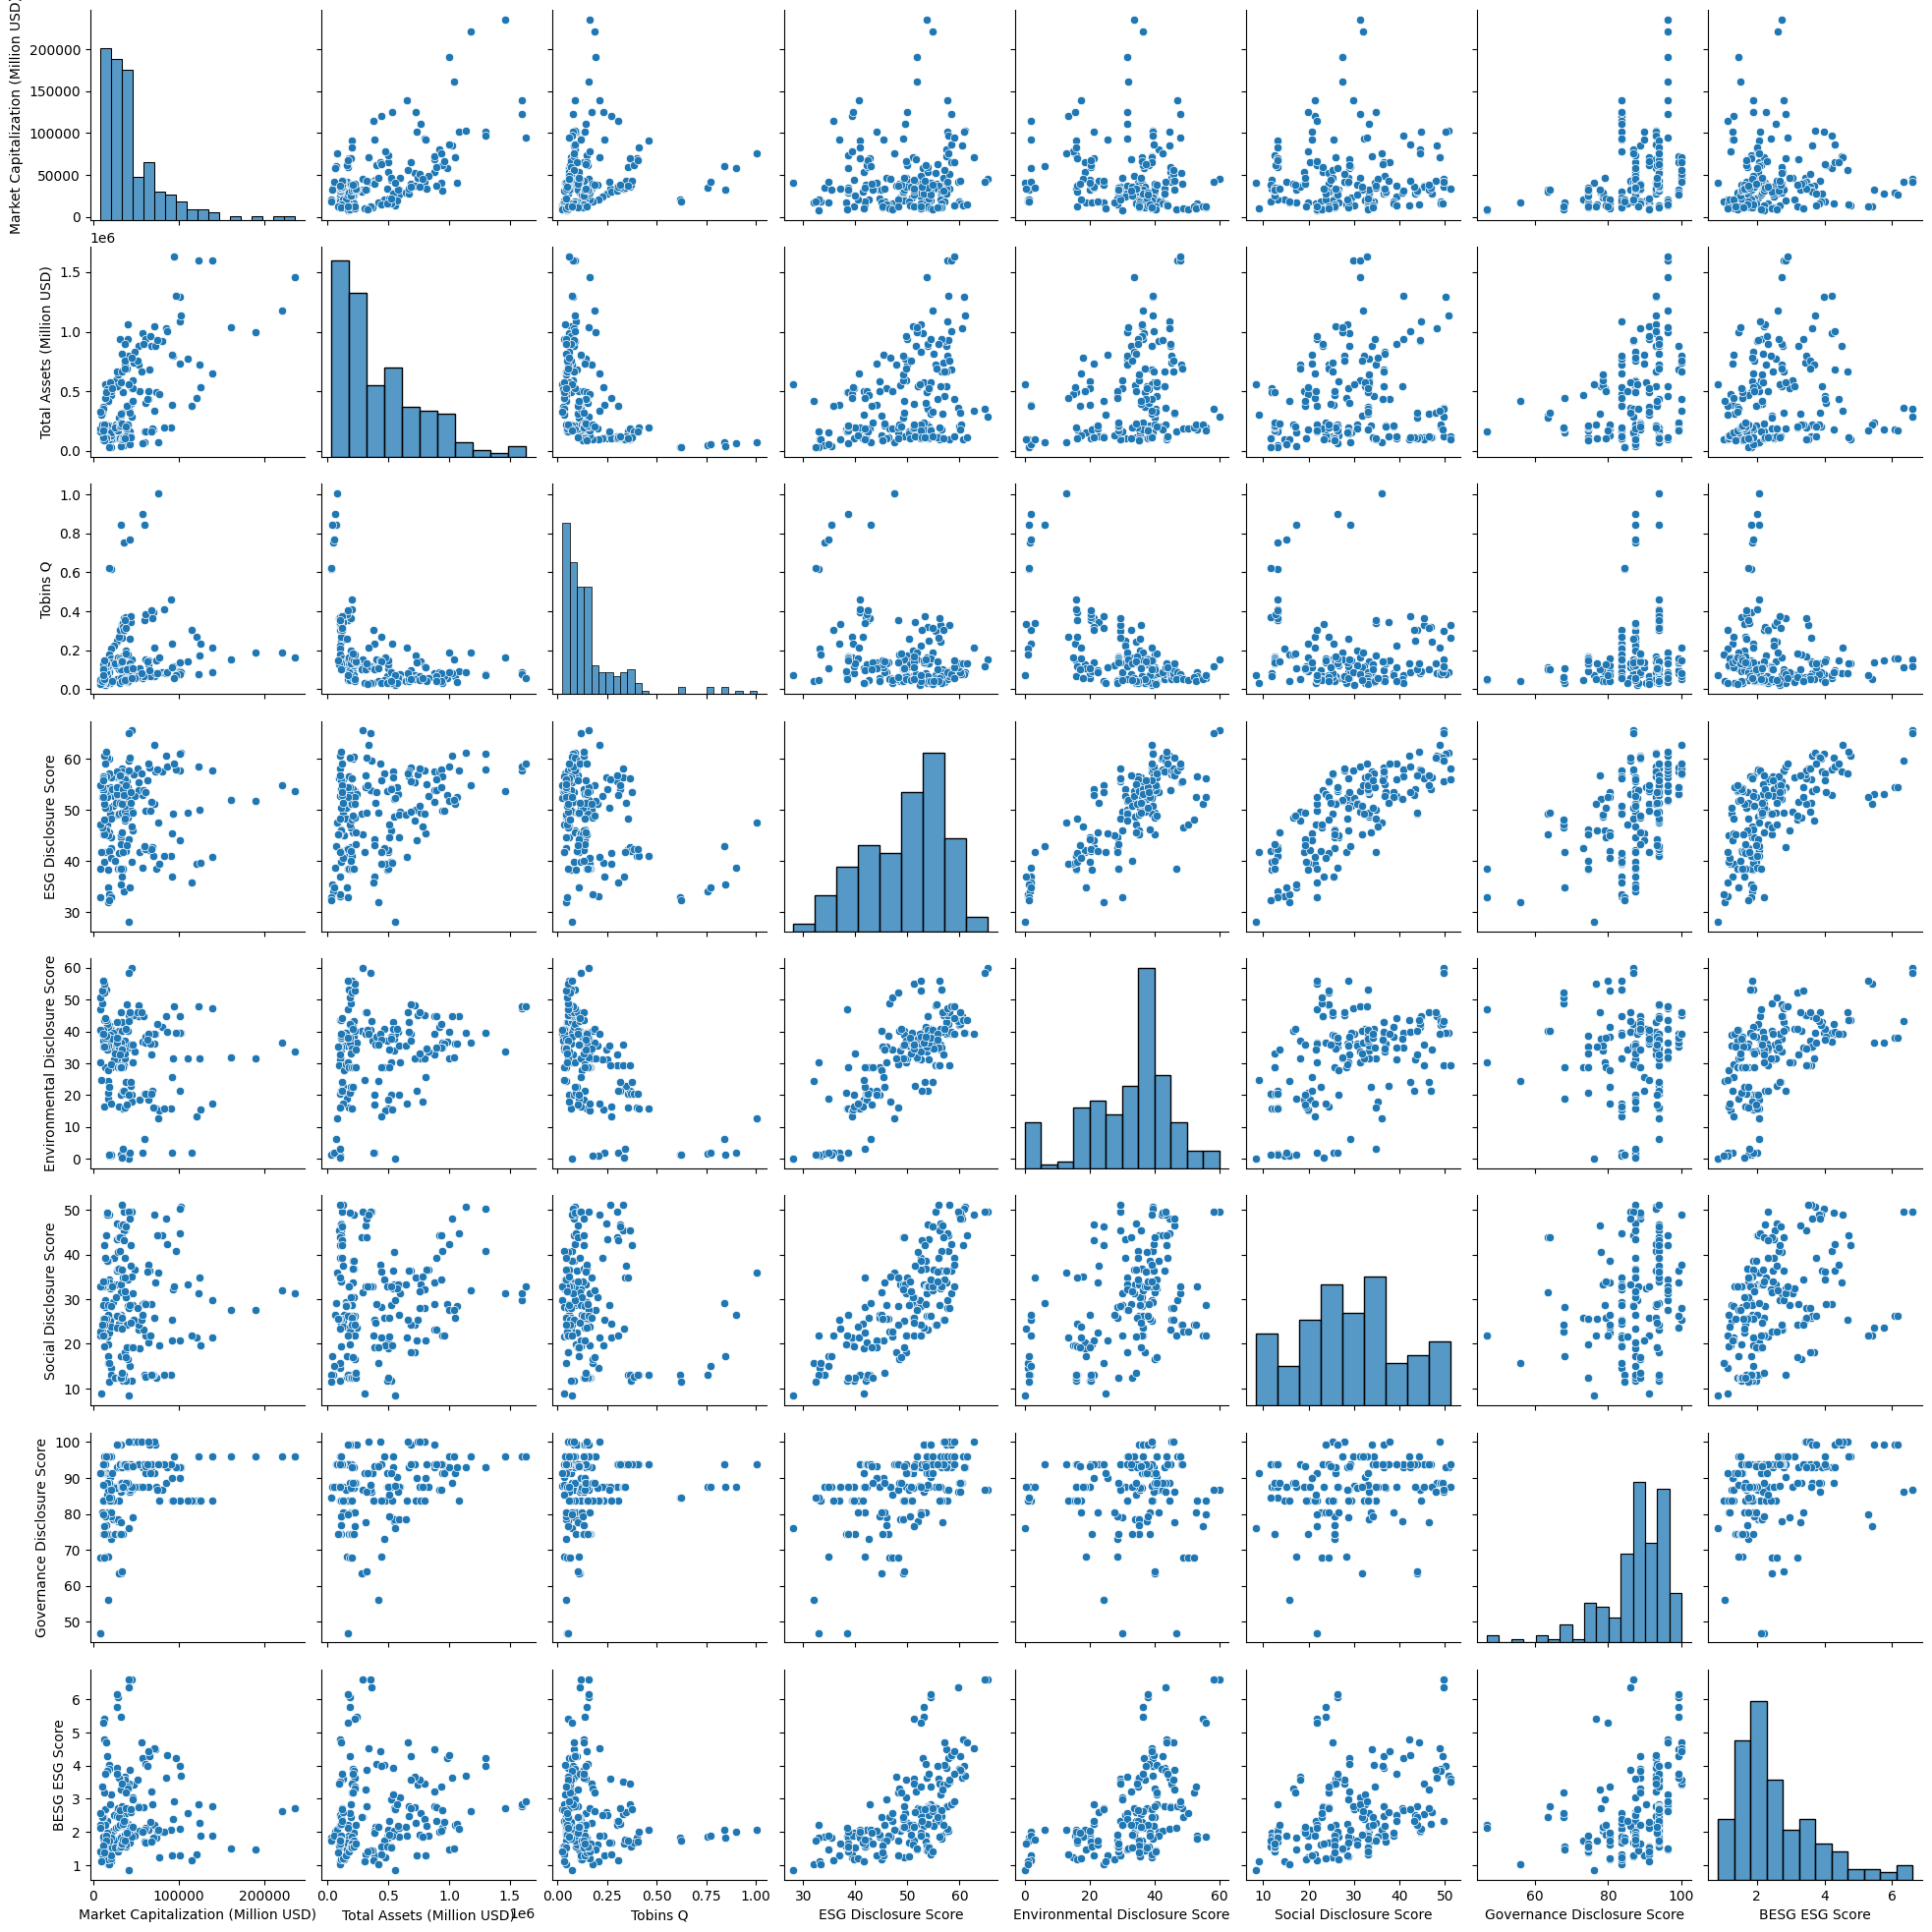

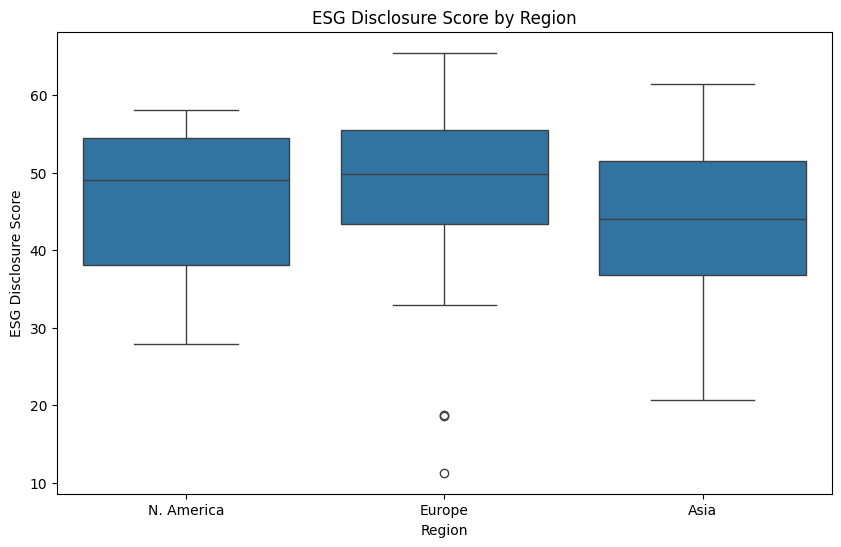

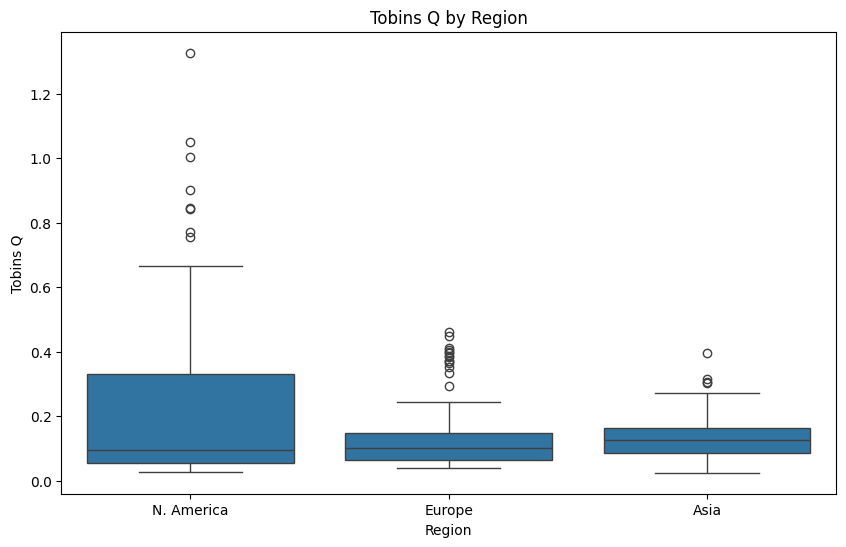

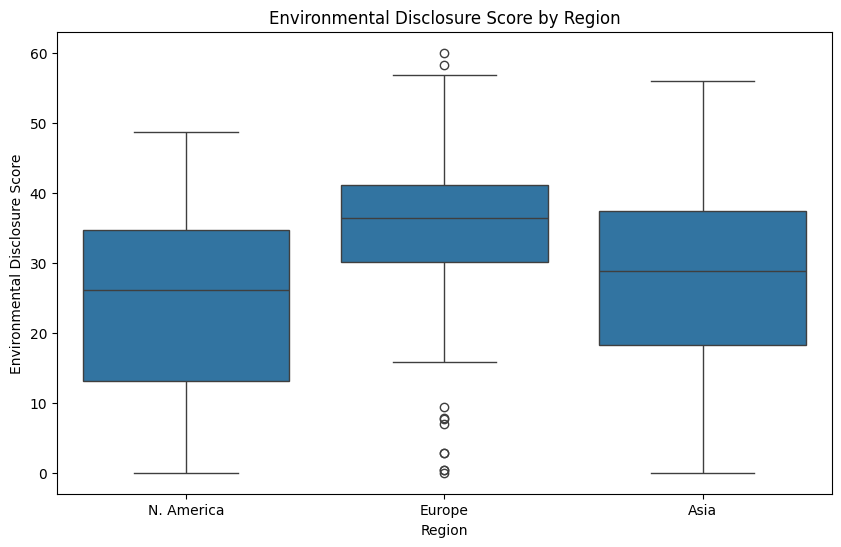

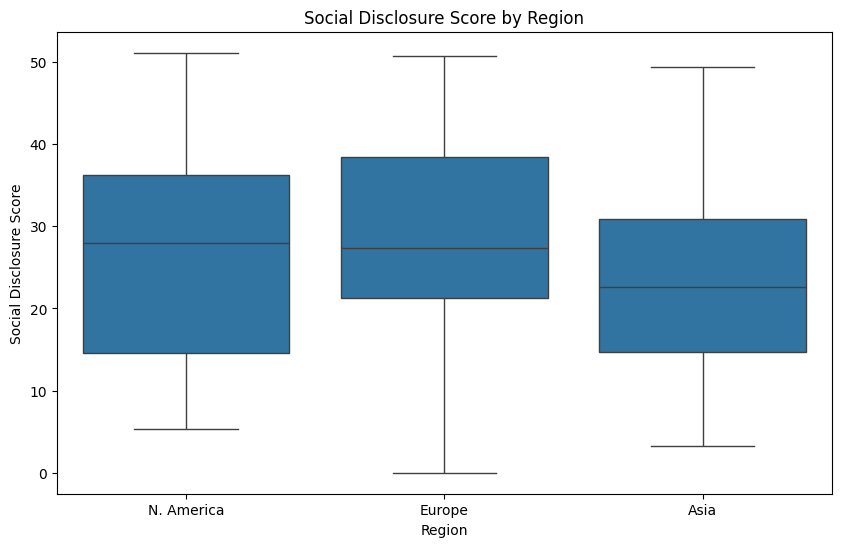

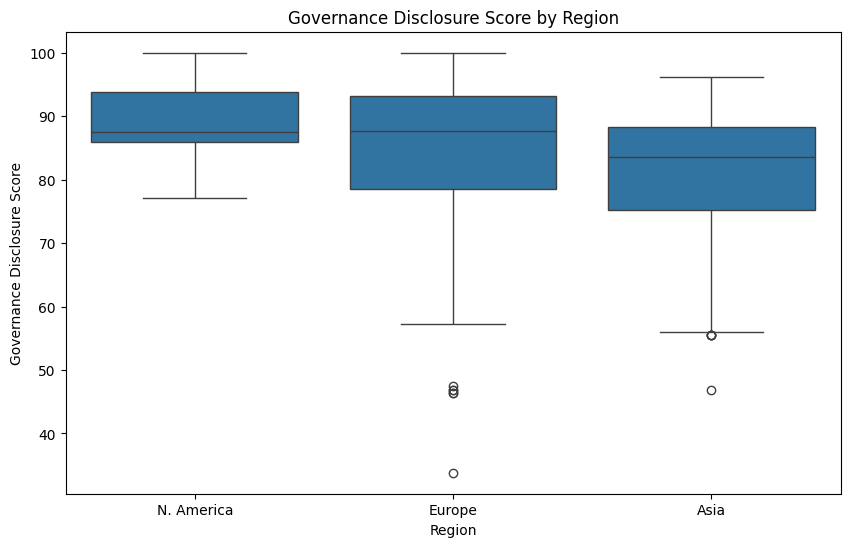

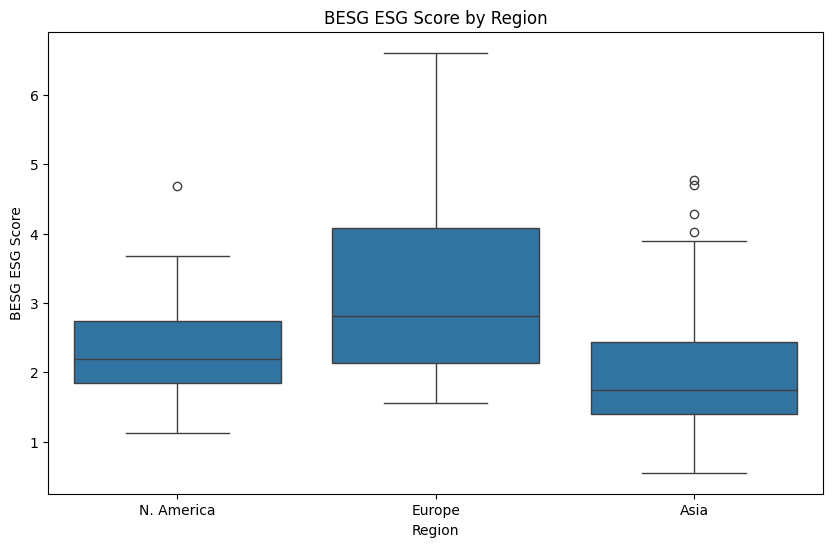

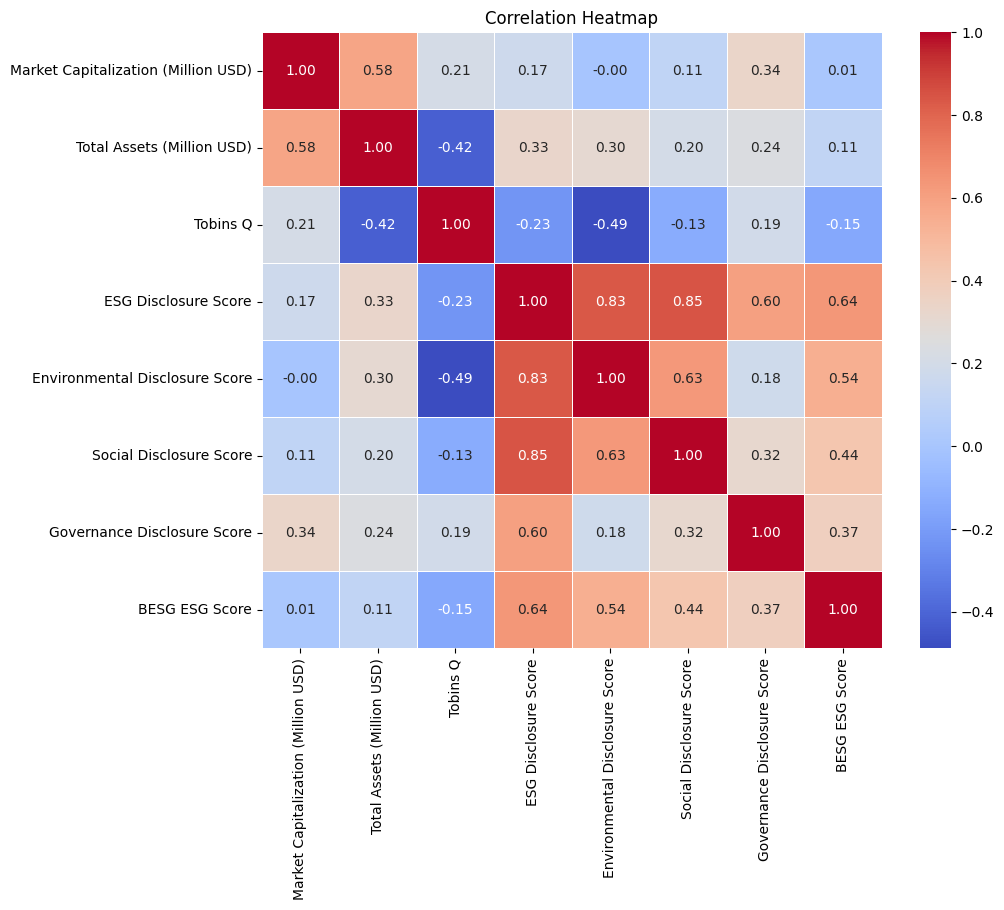

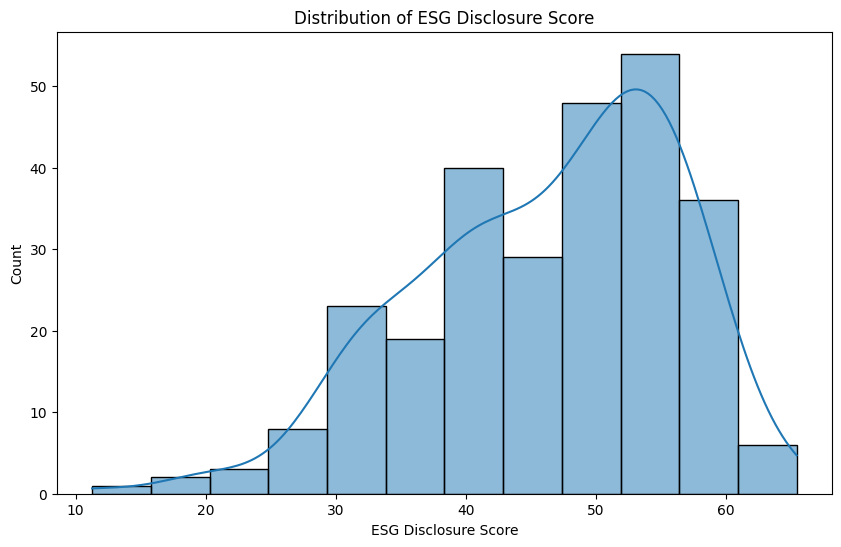

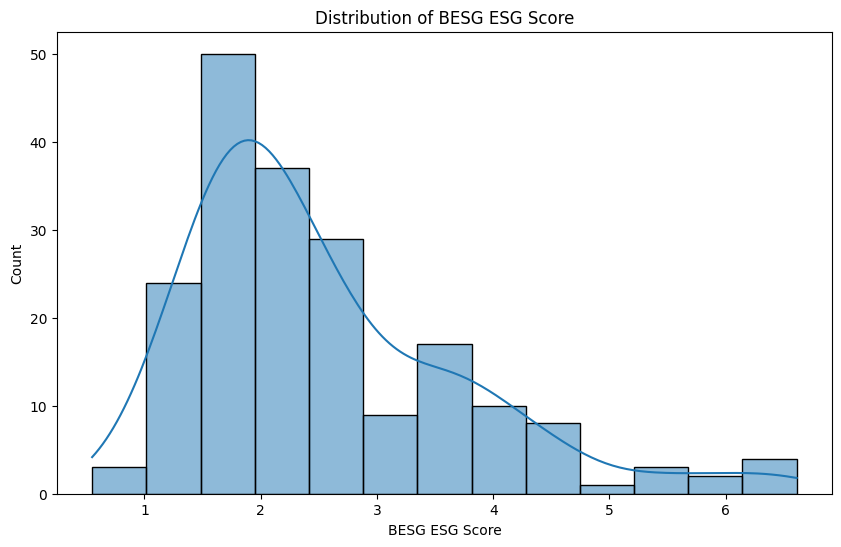

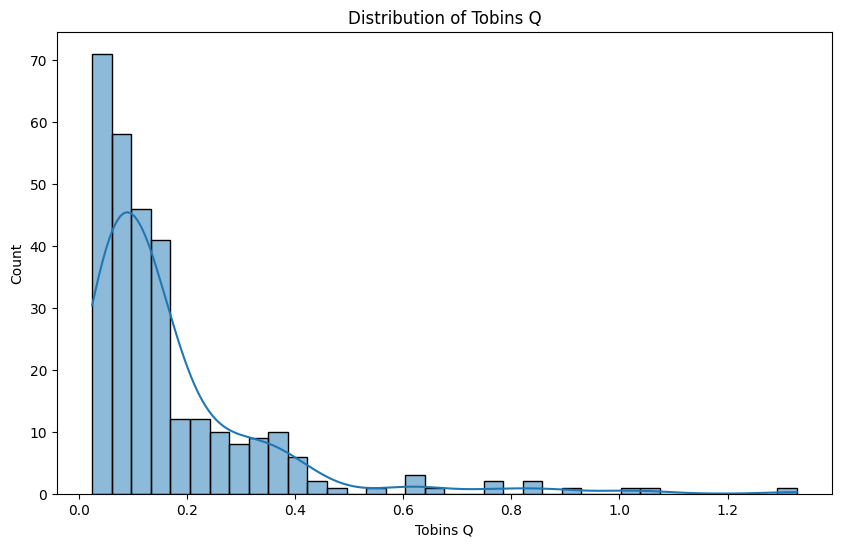

In [ ]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your DataFrame is stored in 'tobinsq_df', you can load it like this if you have it as a CSV
# tobinsq_df = pd.read_csv('your_file.csv')

# Check the first few rows of the dataframe to ensure it's loaded correctly
print(tobinsq_df.head())

# General Information about the dataframe
print("\nGeneral Information:")
print(tobinsq_df.info())

# Descriptive statistics of the numerical columns
print("\nDescriptive Statistics:")
print(tobinsq_df.describe())

# Check for missing values
print("\nMissing Values:")
print(tobinsq_df.isnull().sum())

# Plot histograms for each numerical column
tobinsq_df.hist(figsize=(12, 10), bins=20, edgecolor='black')
plt.tight_layout()
plt.show()

# ---- Pairplot including BESG ESG Score ----
pairplot_cols = [
    'Market Capitalization (Million USD)',
    'Total Assets (Million USD)',
    'Tobins Q',
    'ESG Disclosure Score',
    'Environmental Disclosure Score',
    'Social Disclosure Score',
    'Governance Disclosure Score',
    'BESG ESG Score'  # NEW
]

# Filter to only columns that actually exist (defensive)
pairplot_cols = [c for c in pairplot_cols if c in tobinsq_df.columns]

sns.pairplot(tobinsq_df[pairplot_cols].dropna())
plt.show()

# Boxplot for the ESG Disclosure Score across different regions
plt.figure(figsize=(10, 6))
sns.boxplot(x='Region', y='ESG Disclosure Score', data=tobinsq_df)
plt.title("ESG Disclosure Score by Region")
plt.show()

# Boxplot for Tobins Q across different regions
plt.figure(figsize=(10, 6))
sns.boxplot(x='Region', y='Tobins Q', data=tobinsq_df)
plt.title("Tobins Q by Region")
plt.show()

# Boxplot for the Environmental Disclosure Score across different regions
plt.figure(figsize=(10, 6))
sns.boxplot(x='Region', y='Environmental Disclosure Score', data=tobinsq_df)
plt.title("Environmental Disclosure Score by Region")
plt.show()

# Boxplot for the Social Disclosure Score across different regions
plt.figure(figsize=(10, 6))
sns.boxplot(x='Region', y='Social Disclosure Score', data=tobinsq_df)
plt.title("Social Disclosure Score by Region")
plt.show()

# Boxplot for the Governance Disclosure Score across different regions
plt.figure(figsize=(10, 6))
sns.boxplot(x='Region', y='Governance Disclosure Score', data=tobinsq_df)
plt.title("Governance Disclosure Score by Region")
plt.show()

# ---- NEW: Boxplot for the BESG ESG Score across different regions ----
if 'BESG ESG Score' in tobinsq_df.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Region', y='BESG ESG Score', data=tobinsq_df)
    plt.title("BESG ESG Score by Region")
    plt.show()

# ---- Correlation heatmap including BESG ESG Score ----
corr_cols = [
    'Market Capitalization (Million USD)',
    'Total Assets (Million USD)',
    'Tobins Q',
    'ESG Disclosure Score',
    'Environmental Disclosure Score',
    'Social Disclosure Score',
    'Governance Disclosure Score',
    'BESG ESG Score'  # NEW
]

corr_cols = [c for c in corr_cols if c in tobinsq_df.columns]

correlation_matrix = tobinsq_df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

# Checking the distribution of 'ESG Disclosure Score' with a histogram
plt.figure(figsize=(10, 6))
sns.histplot(tobinsq_df['ESG Disclosure Score'].dropna(), kde=True)
plt.title('Distribution of ESG Disclosure Score')
plt.show()

# ---- NEW: Distribution of BESG ESG Score ----
if 'BESG ESG Score' in tobinsq_df.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(tobinsq_df['BESG ESG Score'].dropna(), kde=True)
    plt.title('Distribution of BESG ESG Score')
    plt.show()

# Checking the distribution of 'Tobins Q' with a histogram
plt.figure(figsize=(10, 6))
sns.histplot(tobinsq_df['Tobins Q'].dropna(), kde=True)
plt.title('Distribution of Tobins Q')
plt.show()


In [ ]:
# Display rows where 'Tobins Q' has missing values
missing_tobinsq = tobinsq_df[tobinsq_df['Tobins Q'].isnull()]
print("Missing rows of Tobins Q")
display(missing_tobinsq)

# Display rows where 'Environmental Disclosure Score' has missing values
missing_esg_disclosure = tobinsq_df[tobinsq_df['Environmental Disclosure Score'].isnull()]
print("Missing rows of Environmental Disclosure Score")
display(missing_esg_disclosure)


Missing rows of Tobins Q


,Company,Year,Market Capitalization (Million USD),Total Assets (Million USD),Tobins Q,ESG Disclosure Score,Environmental Disclosure Score,Social Disclosure Score,Governance Disclosure Score,BESG ESG Score,Region
25,India Life Insurance,2021,NaN,523434.3481,NaN,20.637400,0.0,5.1693,56.7429,0.55,Asia
26,India Life Insurance,2022,NaN,560385.3530,NaN,28.671367,0.0,9.9154,76.0987,0.91,Asia


Missing rows of Environmental Disclosure Score


,Company,Year,Market Capitalization (Million USD),Total Assets (Million USD),Tobins Q,ESG Disclosure Score,Environmental Disclosure Score,Social Disclosure Score,Governance Disclosure Score,BESG ESG Score,Region
209,AIG,2024,44128.4081,1.613220e+05,0.273542,NaN,NaN,NaN,NaN,NaN,N. America
208,AIG,2023,46668.8945,5.393060e+05,0.086535,NaN,NaN,NaN,NaN,NaN,N. America
156,AXA,2023,74071.1274,7.129476e+05,0.103894,NaN,NaN,NaN,NaN,NaN,Europe
157,AXA,2024,78664.6815,6.765783e+05,0.116268,NaN,NaN,NaN,NaN,NaN,Europe
131,Allianz,2024,118178.9167,1.081000e+06,0.109324,NaN,NaN,NaN,NaN,NaN,Europe
196,Allstate,2024,51089.3500,1.116170e+05,0.457720,NaN,NaN,NaN,NaN,NaN,N. America
143,Assicurazioni Generali,2023,33301.4270,5.627272e+05,0.059179,NaN,NaN,NaN,NaN,NaN,Europe
144,Assicurazioni Generali,2024,42942.4411,5.574458e+05,0.077034,NaN,NaN,NaN,NaN,NaN,Europe
54,China Life,2024,53416.8230,9.274113e+05,0.057598,NaN,NaN,NaN,NaN,NaN,Asia
170,Chubb,2024,110714.4221,2.465480e+05,0.449058,NaN,NaN,NaN,NaN,NaN,Europe


/tmp/ipykernel_812/376250334.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Year'] = df['Year'].astype(int)


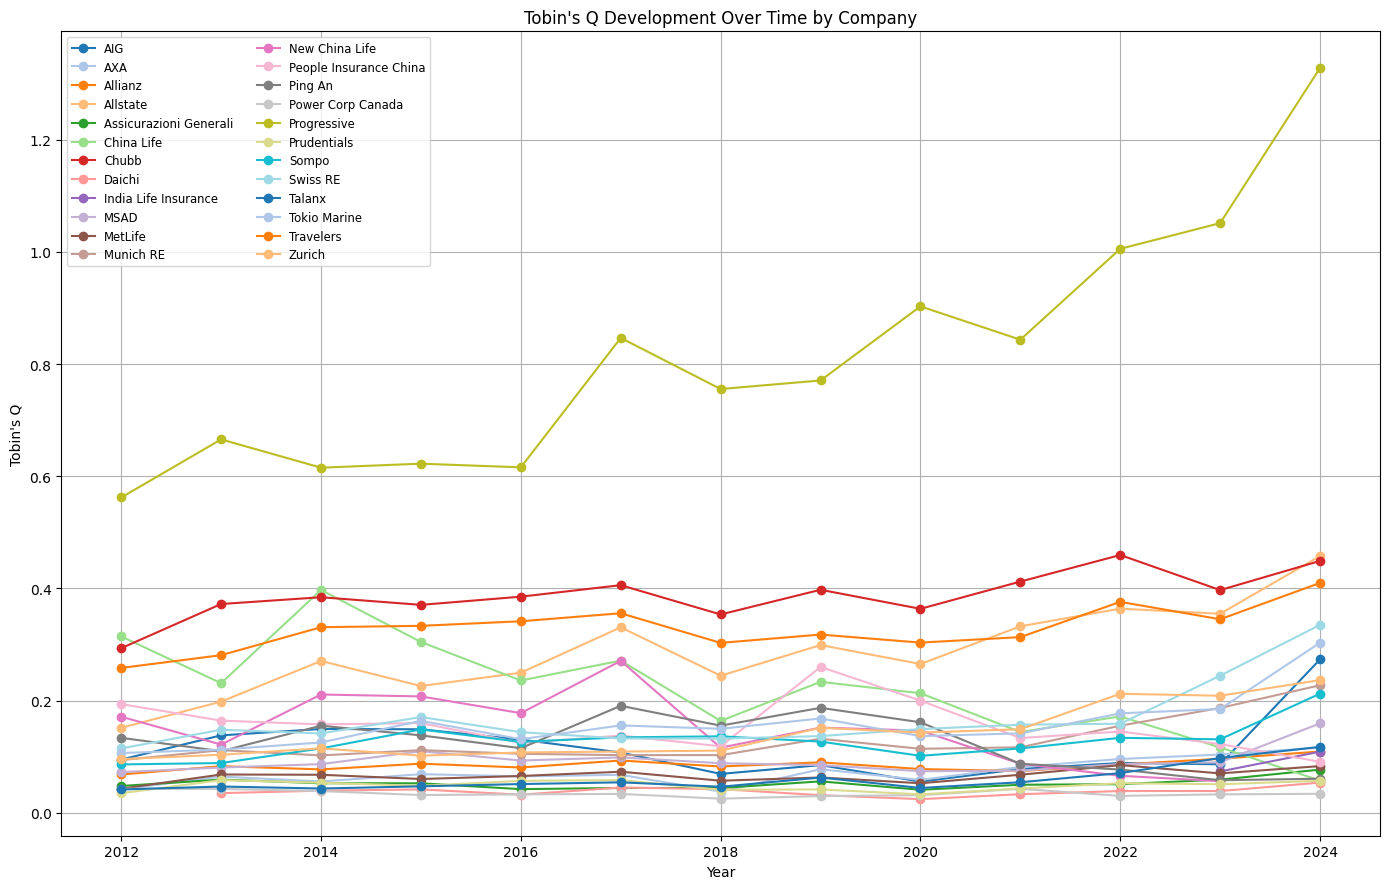

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_tobins_q(df):
    df = df.dropna(subset=["Tobins Q"])
    df['Year'] = df['Year'].astype(int)
    df = df.sort_values(by=['Company', 'Year'])

    companies = df['Company'].unique()
    n = len(companies)

    # Get a colormap with enough distinct colors
    cmap = plt.get_cmap('tab20')
    colors = [cmap(i % 20) for i in range(n)]  # cycle if >20 companies

    plt.figure(figsize=(14, 9))
    for i, company in enumerate(companies):
        company_data = df[df['Company'] == company]
        plt.plot(company_data['Year'], company_data["Tobins Q"],
                 marker='o', label=company, color=colors[i])

    plt.title("Tobin's Q Development Over Time by Company")
    plt.xlabel("Year")
    plt.ylabel("Tobin's Q")
    plt.legend(loc='best', fontsize='small', ncol=2)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Call the function with your DataFrame
plot_tobins_q(tobinsq_df)


/tmp/ipykernel_812/1467678565.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Year'] = df['Year'].astype(int)


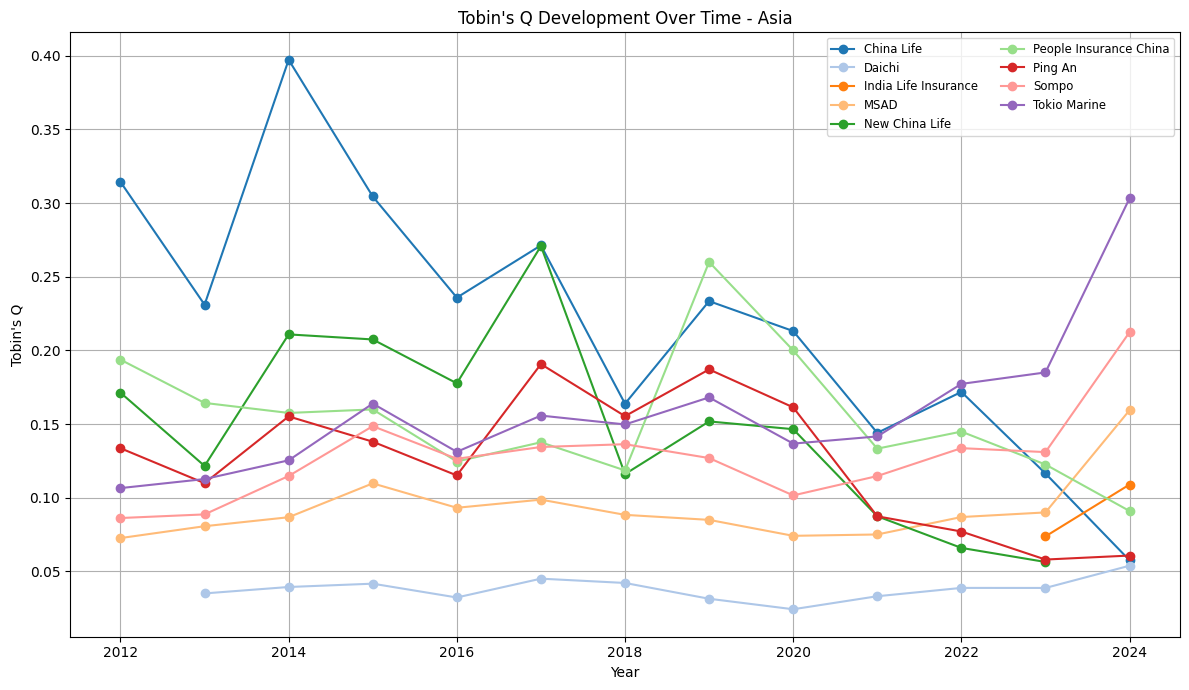

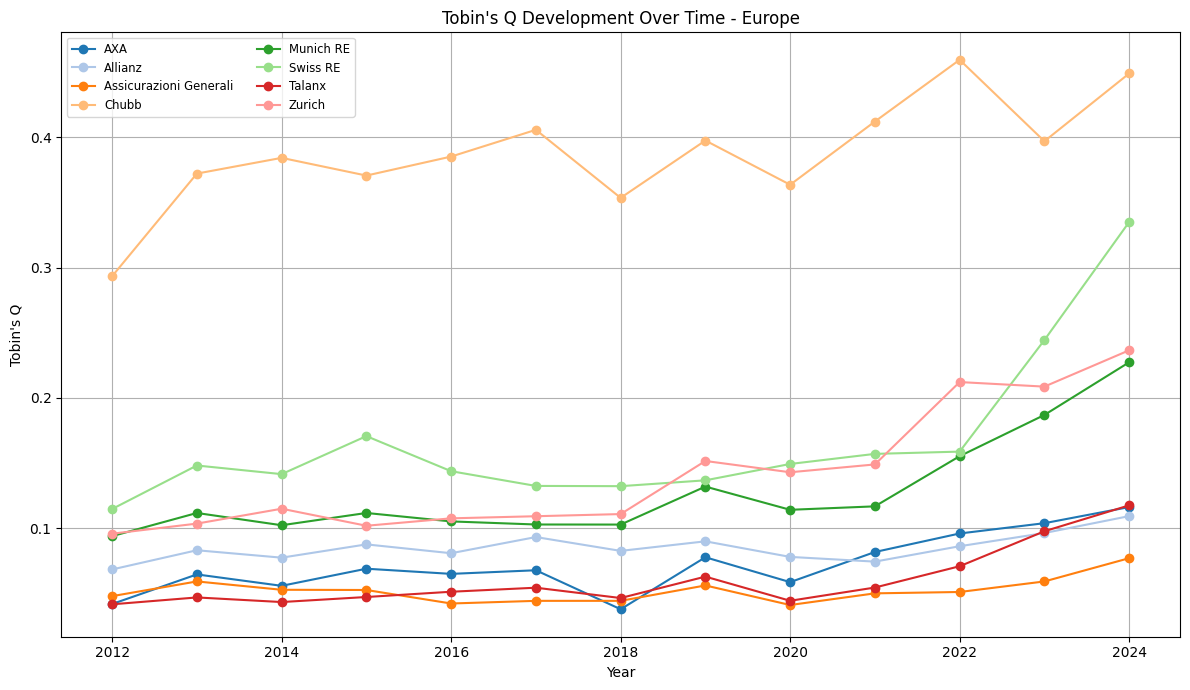

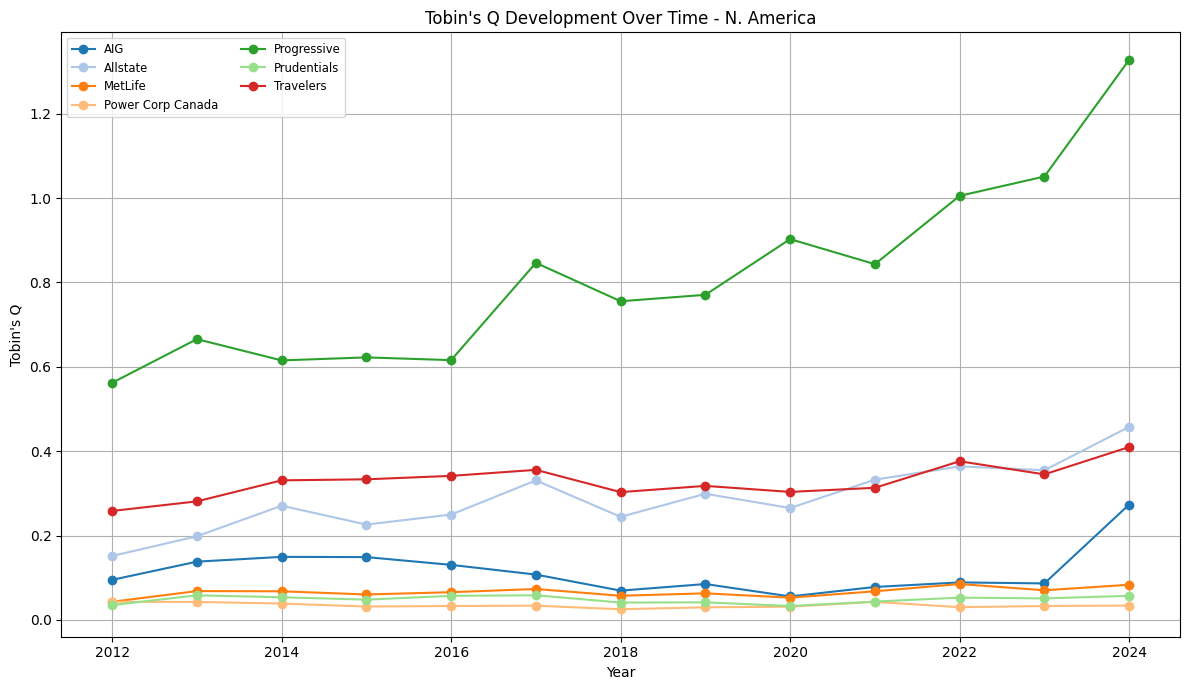

In [ ]:
import matplotlib.pyplot as plt

def plot_tobins_q_by_region_separately(df):
    df = df.dropna(subset=["Tobins Q"])
    df['Year'] = df['Year'].astype(int)
    df = df.sort_values(by=['Company', 'Year'])

    regions = ['Asia', 'Europe', 'N. America']

    for region in regions:
        region_df = df[df['Region'] == region]
        if region_df.empty:
            print(f"No data for region: {region}")
            continue

        plt.figure(figsize=(12, 7))
        companies = region_df['Company'].unique()

        # Use a colormap with enough distinct colors
        cmap = plt.get_cmap('tab20')
        colors = [cmap(i % 20) for i in range(len(companies))]

        for i, company in enumerate(companies):
            comp_data = region_df[region_df['Company'] == company]
            plt.plot(comp_data['Year'], comp_data["Tobins Q"], marker='o', label=company, color=colors[i])

        plt.title(f"Tobin's Q Development Over Time - {region}")
        plt.xlabel("Year")
        plt.ylabel("Tobin's Q")
        plt.legend(loc='best', fontsize='small', ncol=2)
        plt.grid(True)
        plt.tight_layout()
        plt.show()

# Call this with your dataframe
plot_tobins_q_by_region_separately(tobinsq_df)


### Descriptive Analysis of Bloomberg ESG data

/tmp/ipykernel_812/1813607531.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Year'] = df['Year'].astype(int)


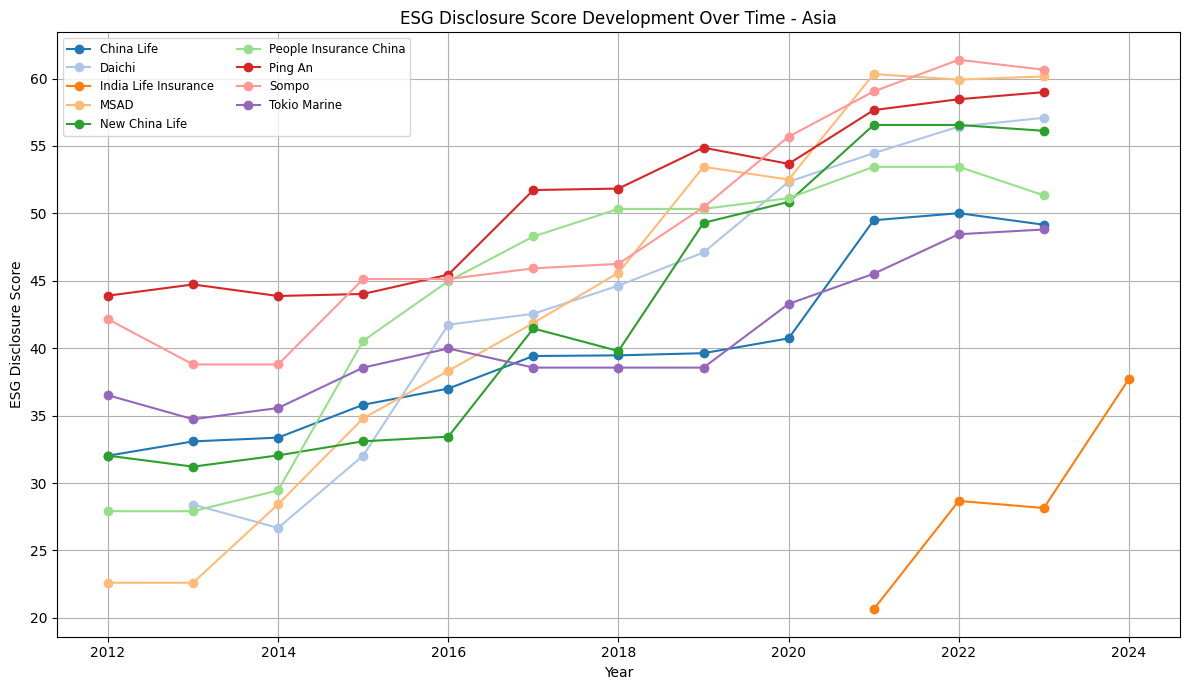

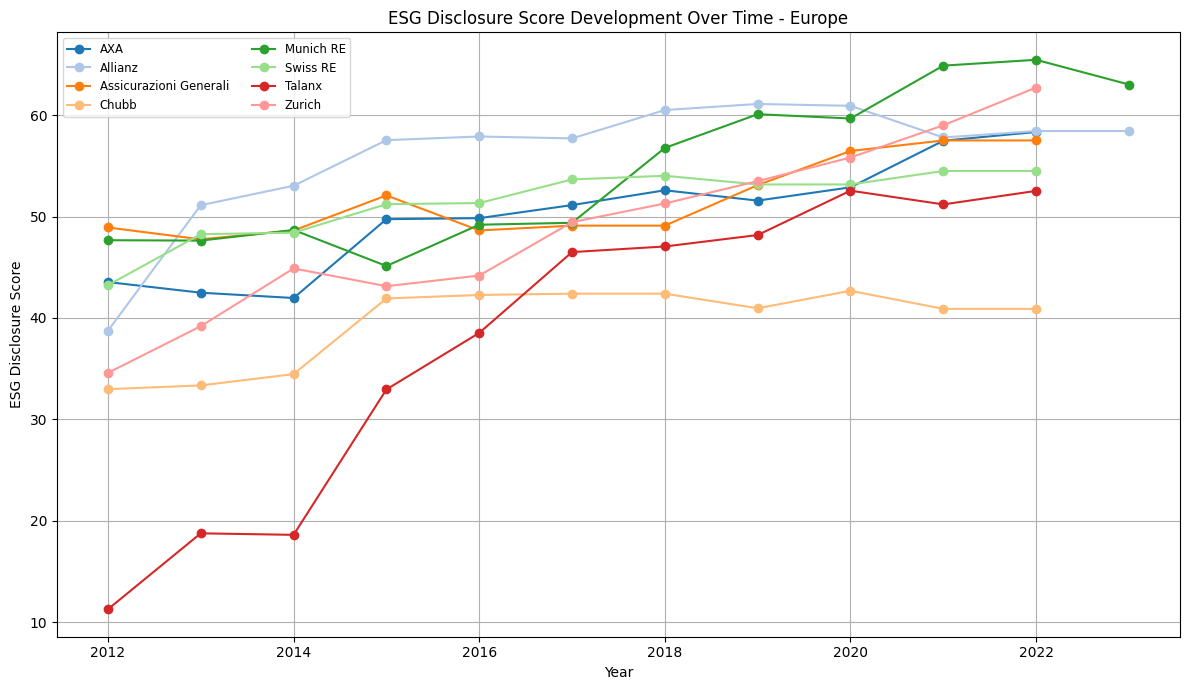

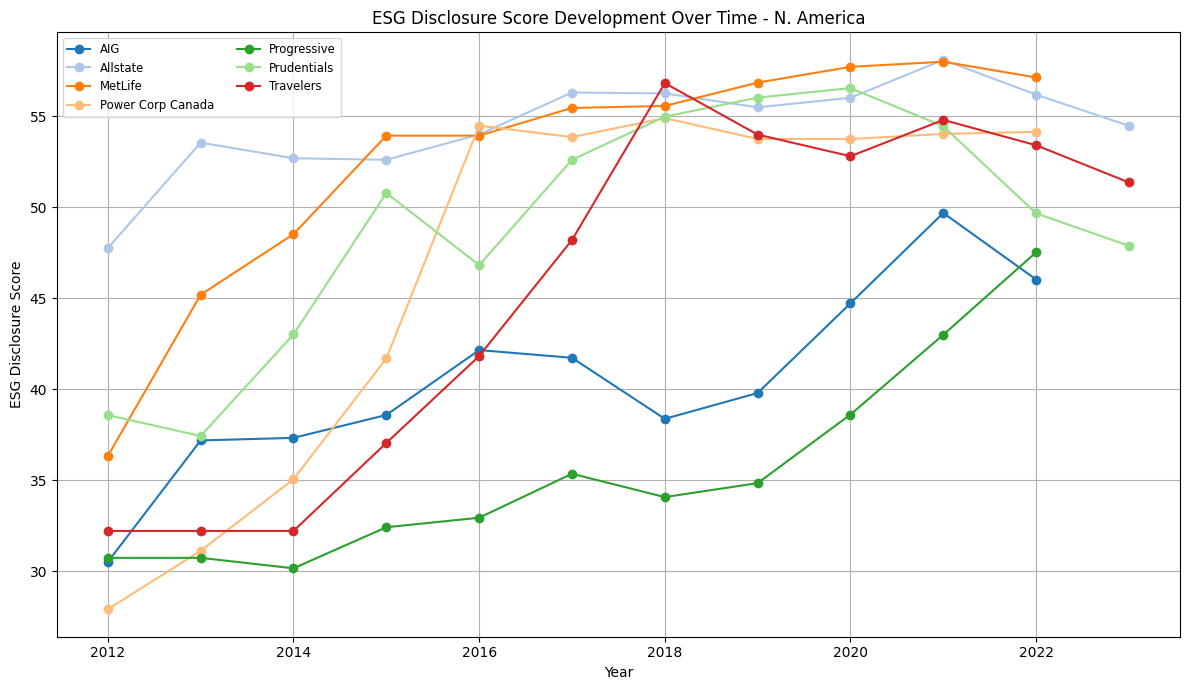

In [ ]:
import matplotlib.pyplot as plt

def plot_esg_score_by_region_separately(df):
    # Drop rows with missing ESG Disclosure Scores
    df = df.dropna(subset=["ESG Disclosure Score"])

    # Sort values by Company and Year
    df['Year'] = df['Year'].astype(int)
    df = df.sort_values(by=['Company', 'Year'])

    # Define the regions for which plots will be created
    regions = ['Asia', 'Europe', 'N. America']

    # Iterate through each region and create a plot
    for region in regions:
        region_df = df[df['Region'] == region]

        if region_df.empty:
            print(f"No data for region: {region}")
            continue

        plt.figure(figsize=(12, 7))
        companies = region_df['Company'].unique()

        # Use a colormap with enough distinct colors
        cmap = plt.get_cmap('tab20')
        colors = [cmap(i % 20) for i in range(len(companies))]

        for i, company in enumerate(companies):
            comp_data = region_df[region_df['Company'] == company]
            plt.plot(comp_data['Year'], comp_data["ESG Disclosure Score"], marker='o', label=company, color=colors[i])

        plt.title(f"ESG Disclosure Score Development Over Time - {region}")
        plt.xlabel("Year")
        plt.ylabel("ESG Disclosure Score")
        plt.legend(loc='best', fontsize='small', ncol=2)
        plt.grid(True)
        plt.tight_layout()
        plt.show()

# Call this function with your dataframe
plot_esg_score_by_region_separately(tobinsq_df)


/tmp/ipykernel_812/1813607531.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Year'] = df['Year'].astype(int)


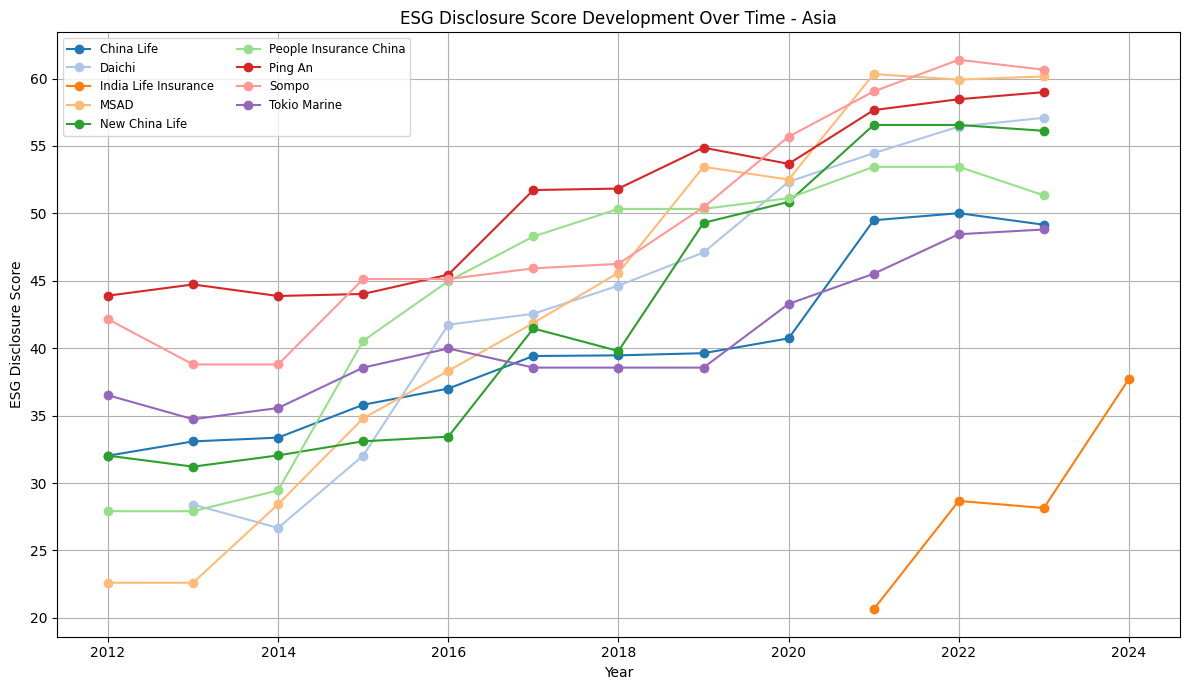

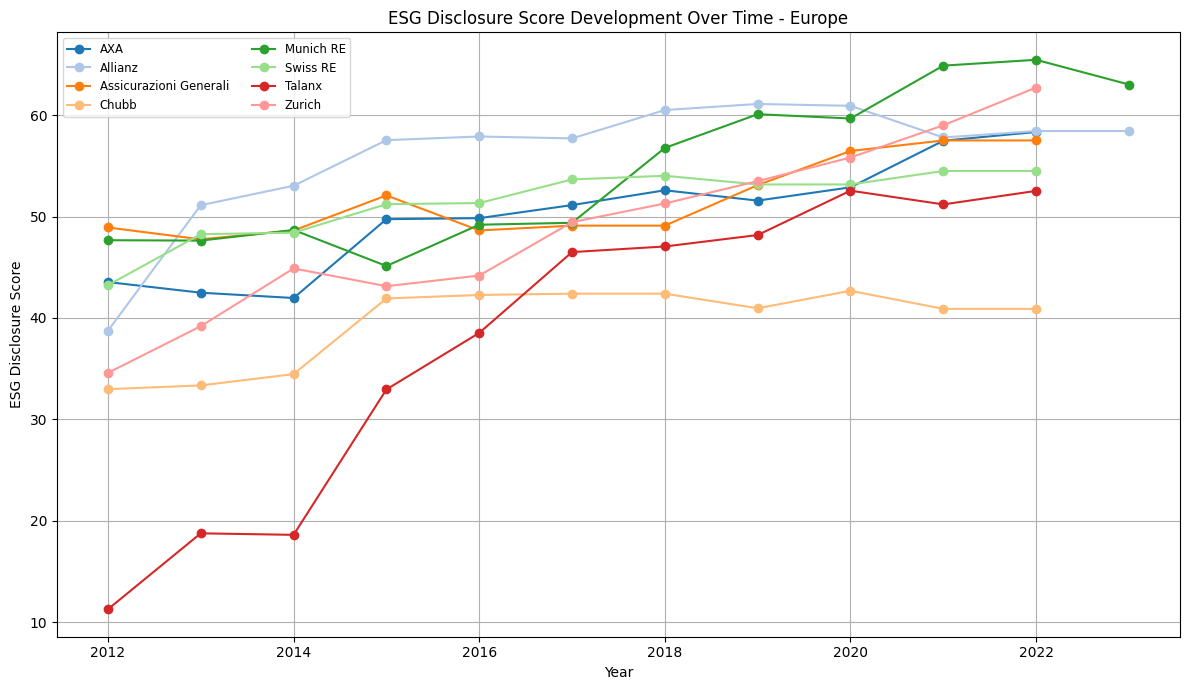

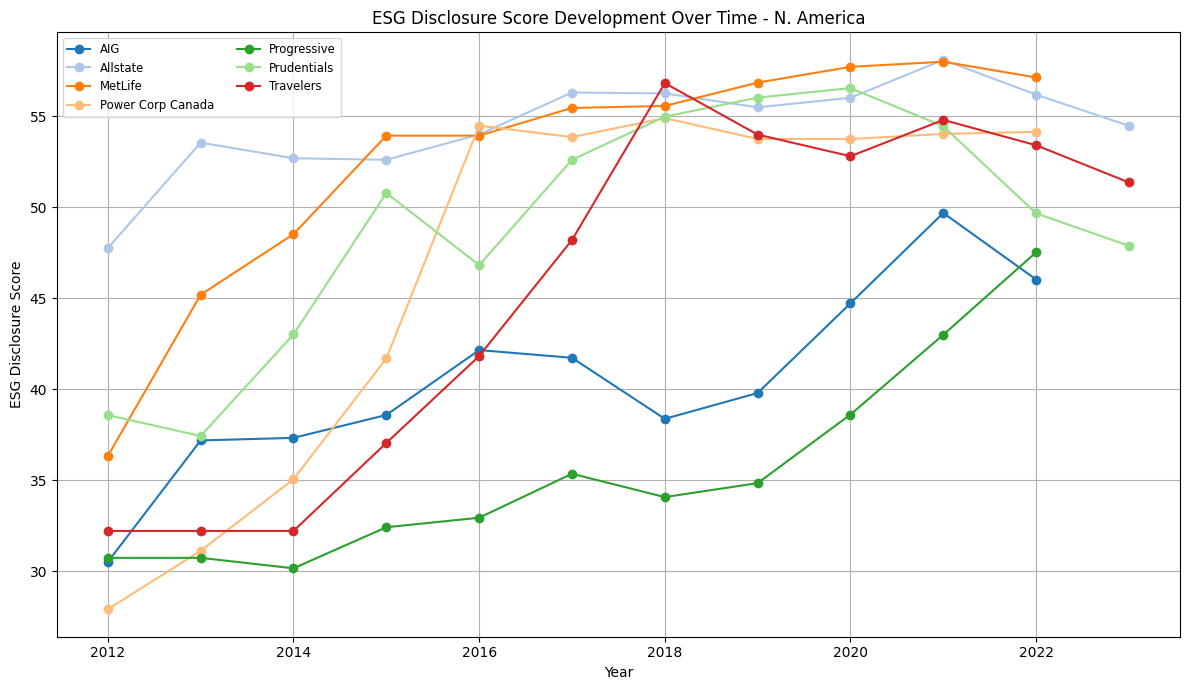

In [ ]:
import matplotlib.pyplot as plt

def plot_esg_score_by_region_separately(df):
    # Drop rows with missing ESG Disclosure Scores
    df = df.dropna(subset=["ESG Disclosure Score"])

    # Sort values by Company and Year
    df['Year'] = df['Year'].astype(int)
    df = df.sort_values(by=['Company', 'Year'])

    # Define the regions for which plots will be created
    regions = ['Asia', 'Europe', 'N. America']

    # Iterate through each region and create a plot
    for region in regions:
        region_df = df[df['Region'] == region]

        if region_df.empty:
            print(f"No data for region: {region}")
            continue

        plt.figure(figsize=(12, 7))
        companies = region_df['Company'].unique()

        # Use a colormap with enough distinct colors
        cmap = plt.get_cmap('tab20')
        colors = [cmap(i % 20) for i in range(len(companies))]

        for i, company in enumerate(companies):
            comp_data = region_df[region_df['Company'] == company]
            plt.plot(comp_data['Year'], comp_data["ESG Disclosure Score"], marker='o', label=company, color=colors[i])

        plt.title(f"ESG Disclosure Score Development Over Time - {region}")
        plt.xlabel("Year")
        plt.ylabel("ESG Disclosure Score")
        plt.legend(loc='best', fontsize='small', ncol=2)
        plt.grid(True)
        plt.tight_layout()
        plt.show()

# Call this function with your dataframe
plot_esg_score_by_region_separately(tobinsq_df)


## Extract Covariates values
Size, ROA, Leverage, Dividens, Sales growth


In [ ]:
import os
import pandas as pd
import numpy as np
from IPython.display import display

folder_path = '/content/drive/MyDrive/phd/BloombergData'

def extract_financials(file_path, labels, start_year=2012, end_year=2024):
    """
    Extract financial values for given labels from an Excel file.
    Returns dict of {label: (years, values)}.
    """
    df = pd.read_excel(file_path, header=None)

    # Find fiscal year header row
    fy_header_row = None
    for i in range(10):
        for val in df.iloc[i]:
            if isinstance(val, str) and val.strip().startswith('FY'):
                fy_header_row = i
                break
        if fy_header_row is not None:
            break
    if fy_header_row is None:
        print(f"Fiscal Year header row not found in {file_path}")
        return None

    # Identify fiscal year columns within desired range
    available_cols = []
    available_years = []
    for col_idx, val in enumerate(df.iloc[fy_header_row]):
        if isinstance(val, str) and val.strip().startswith('FY'):
            try:
                year = int(val.strip().replace('FY', '').strip())
                if start_year <= year <= end_year:
                    available_cols.append(col_idx)
                    available_years.append(year)
            except:
                continue
    if not available_cols:
        print(f"No fiscal year columns in range FY{start_year}-FY{end_year} found in {file_path}")
        return None

    results = {}
    for label in labels:
        row_idx = None
        for idx, val in enumerate(df.iloc[:, 0]):
            if isinstance(val, str) and label.lower() in val.lower():
                row_idx = idx
                break
        if row_idx is None:
            print(f"'{label}' row not found in {file_path}")
            results[label] = (None, None)
            continue

        raw_values = df.iloc[row_idx, available_cols].values
        cleaned_values = []
        for v in raw_values:
            try:
                cleaned_values.append(float(v))
            except (ValueError, TypeError):
                cleaned_values.append(np.nan)
        results[label] = (available_years, cleaned_values)

    return results

def process_assets_liabilities_equity(company_name, ass_path):
    # Now extract Total Assets, Total Liabilities, and Total Equity
    ass_results = extract_financials(ass_path, ["Total Assets", "Total Liabilities", "Total Equity"])
    if ass_results is None:
        return None

    ass_years, assets = ass_results.get("Total Assets", (None, None))
    _, liabilities = ass_results.get("Total Liabilities", (None, None))
    _, equity = ass_results.get("Total Equity", (None, None))

    if ass_years is None or assets is None:
        print(f"Total Assets not found for {company_name}")
        return None

    data = []
    for i, year in enumerate(ass_years):
        total_assets = assets[i] if assets and i < len(assets) else np.nan
        total_liabilities = liabilities[i] if liabilities and i < len(liabilities) else np.nan
        total_equity = equity[i] if equity and i < len(equity) else np.nan

        # Recalculate leverage as Total Liabilities / Total Equity
        if total_equity and total_equity != 0 and not np.isnan(total_liabilities) and not np.isnan(total_equity):
            leverage = total_liabilities / total_equity
        else:
            leverage = np.nan

        data.append({
            'Company': company_name,
            'Year': year,
            'Total Assets (Million USD)': total_assets,
            'Total Liabilities (Million USD)': total_liabilities,
            'Total Equity (Million USD)': total_equity,
            'Leverage': leverage
        })
    return pd.DataFrame(data)

def process_revenue_growth(company_name, cap_path):
    """
    Extract Revenue Growth YoY (%) from an Excel file.
    """
    growth_results = extract_financials(cap_path, ["Growth %, YoY"])
    if growth_results is None:
        return None

    growth_years, growth_values = growth_results.get("Growth %, YoY", (None, None))

    if growth_years is None or growth_values is None:
        print(f"Growth %, YoY not found for {company_name}")
        return None

    data = []
    for i, year in enumerate(growth_years):
        revenue_growth = growth_values[i] if growth_values and i < len(growth_values) else np.nan
        data.append({
            'Company': company_name,
            'Year': year,
            'Revenue Growth YoY (%)': revenue_growth
        })
    return pd.DataFrame(data)

def process_net_income(company_name, cap_path):
    """
    Extract Net Income, Adj from an Excel file.
    """
    net_income_results = extract_financials(cap_path, ["Net Income, Adj"])
    if net_income_results is None:
        return None

    net_income_years, net_income_values = net_income_results.get("Net Income, Adj", (None, None))

    if net_income_years is None or net_income_values is None:
        print(f"Net Income, Adj not found for {company_name}")
        return None

    data = []
    for i, year in enumerate(net_income_years):
        net_income = net_income_values[i] if net_income_values and i < len(net_income_values) else np.nan
        data.append({
            'Company': company_name,
            'Year': year,
            'Net Income, Adj': net_income
        })
    return pd.DataFrame(data)


def main(folder_path):
    cov_df = pd.DataFrame()

    files = os.listdir(folder_path)
    cap_files = [f for f in files if f.endswith('_CAP.xlsx')]

    for cap_file in cap_files:
        company = cap_file.replace('_CAP.xlsx', '')
        cap_path = os.path.join(folder_path, cap_file)
        ass_file = f"{company}_ASS.xlsx"
        ass_path = os.path.join(folder_path, ass_file)

        if not os.path.exists(ass_path):
            print(f"Assets file missing for {company}")
            continue

        print(f"Processing {company}...")

        # Use the updated function that also gets Total Equity
        df_assets = process_assets_liabilities_equity(company, ass_path)
        df_growth = process_revenue_growth(company, cap_path)
        df_net_income = process_net_income(company, cap_path)


        if df_assets is None or df_growth is None or df_net_income is None:
            print(f"Skipping {company} due to missing data.")
            continue


        # Merge dataframes on Company and Year
        df_merge1 = pd.merge(df_assets, df_growth, on=['Company', 'Year'], how='inner')
        df_merged = pd.merge(df_merge1, df_net_income, on=['Company', 'Year'], how='inner')


        # Calculate ROA
        # Avoid division by zero or NaN assets
        df_merged['ROA'] = np.where(
            (df_merged['Total Assets (Million USD)'].notna()) & (df_merged['Total Assets (Million USD)'] != 0),
            df_merged['Net Income, Adj'] / df_merged['Total Assets (Million USD)'],
            np.nan
        )


        # Calculate Size (Natural logarithm of Total Assets)
        df_merged['Size'] = np.log(df_merged['Total Assets (Million USD)'])

        cov_df = pd.concat([cov_df, df_merged], ignore_index=True)


    # Map company full names and regions as needed (add mapping functions here)
    # Ensure get_full_company_name is defined elsewhere or passed in if needed
    # Assuming get_full_company_name and company_region_mapping are defined in an earlier cell
    try:
        cov_df['Company'] = cov_df['Company'].apply(get_full_company_name)
    except NameError:
        print("Warning: get_full_company_name is not defined. Company names will not be mapped.")
        pass # Keep original company names if mapping function isn't available

    cov_df = cov_df.sort_values(by=['Company', 'Year']) # Sort by company and year


    try:
         cov_df['Region'] = cov_df['Company'].map(company_region_mapping)
    except NameError:
        print("Warning: company_region_mapping is not defined. Region column will not be added.")
        pass # Skip adding region if mapping isn't available


    print("\nCombined DataFrame with ROA:")
    display(cov_df)


    output_path = os.path.join(folder_path, 'Combined_Financials_With_ROA.xlsx')
    cov_df.to_excel(output_path, index=False)
    print(f"\nSaved combined results to {output_path}")
    output_path = os.path.join(folder_path, 'Combined_Financials_With_ROA.csv')
    cov_df.to_csv(output_path, index=False)
    print(f"\nSaved combined results to {output_path}")



    return cov_df

# Assuming get_full_company_name and company_region_mapping are defined in earlier cells.
# If not, define them here or ensure they are run before this cell.

# Run main
cov_df = main(folder_path)

Processing SR...
Processing Daichi...
Processing LifeIndia...
'Growth %, YoY' row not found in /content/drive/MyDrive/phd/BloombergData/LifeIndia_CAP.xlsx
Growth %, YoY not found for LifeIndia
'Net Income, Adj' row not found in /content/drive/MyDrive/phd/BloombergData/LifeIndia_CAP.xlsx
Net Income, Adj not found for LifeIndia
Skipping LifeIndia due to missing data.
Processing MSAD...
Processing Chinalife...
Processing NewChinaLife...
Processing PIC...
Processing PA...
Processing SO...
Processing TM...
Processing Allianz...
Processing AGEN...
Processing AXA...
Processing CHUBB...
Processing TAL...
Processing ALL...
Processing AIG...
Processing MET...
Processing PCC...
Processing PRO...
Processing PRU...
Processing TRA...
Processing MR...
Processing ZUR...

Combined DataFrame with ROA:


,Company,Year,Total Assets (Million USD),Total Liabilities (Million USD),Total Equity (Million USD),Leverage,Revenue Growth YoY (%),"Net Income, Adj",ROA,Size,Region
195,AIG,2012,548633.0,449630.0,99003.0,4.541580,8.6607,6074.5000,0.011072,13.215185,N. America
196,AIG,2013,541329.0,440218.0,101111.0,4.353809,-4.7897,6545.0000,0.012091,13.201783,N. America
197,AIG,2014,515581.0,408309.0,107272.0,3.806296,-4.6530,7908.0000,0.015338,13.153050,N. America
198,AIG,2015,496842.0,406632.0,90210.0,4.507616,-9.5387,3728.0000,0.007503,13.116027,N. America
199,AIG,2016,498264.0,421406.0,76858.0,5.482917,-5.9086,-911.3077,-0.001829,13.118885,N. America
...,...,...,...,...,...,...,...,...,...,...,...
294,Zurich,2020,439299.0,399453.0,39846.0,10.024921,-17.2901,4047.1200,0.009213,12.992936,Europe
295,Zurich,2021,435826.0,396657.0,39169.0,10.126809,18.8867,5455.8000,0.012518,12.984998,Europe
296,Zurich,2022,335412.0,308482.0,26930.0,11.454957,-20.7012,4460.0000,0.013297,12.723115,Europe
297,Zurich,2023,361382.0,335103.0,26279.0,12.751741,9.3714,5195.8000,0.014378,12.797691,Europe



Saved combined results to /content/drive/MyDrive/phd/BloombergData/Combined_Financials_With_ROA.xlsx

Saved combined results to /content/drive/MyDrive/phd/BloombergData/Combined_Financials_With_ROA.csv


In [ ]:
# Display basic information about the DataFrame
print("DataFrame Info:")
cov_df.info()
print("\n" + "="*50 + "\n")

# Display the first few rows
print("First 5 rows:")
display(cov_df.head())
print("\n" + "="*50 + "\n")

# Display descriptive statistics for numerical columns
print("Descriptive Statistics:")
display(cov_df.describe())
print("\n" + "="*50 + "\n")

# Display value counts for categorical columns (Company and Region)
print("Value Counts for Company:")
print(cov_df['Company'].value_counts())
print("\n" + "="*50 + "\n")

print("Value Counts for Region:")
print(cov_df['Region'].value_counts())
print("\n" + "="*50 + "\n")

# Check for missing values
print("Missing Values per Column:")
print(cov_df.isnull().sum())
print("\n" + "="*50 + "\n")

# You can also explore specific columns further
print("Descriptive statistics for Leverage:")
print(cov_df['Leverage'].describe())
print("\n" + "="*50 + "\n")

print("Descriptive statistics for ROA:")
print(cov_df['ROA'].describe())
print("\n" + "="*50 + "\n")

print("Descriptive statistics for Revenue Growth YoY (%):")
print(cov_df['Revenue Growth YoY (%)'].describe())
print("\n" + "="*50 + "\n")

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Index: 299 entries, 195 to 298
Data columns (total 11 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Company                          299 non-null    object 
 1   Year                             299 non-null    int64  
 2   Total Assets (Million USD)       299 non-null    float64
 3   Total Liabilities (Million USD)  299 non-null    float64
 4   Total Equity (Million USD)       299 non-null    float64
 5   Leverage                         299 non-null    float64
 6   Revenue Growth YoY (%)           299 non-null    float64
 7   Net Income, Adj                  299 non-null    float64
 8   ROA                              299 non-null    float64
 9   Size                             299 non-null    float64
 10  Region                           299 non-null    object 
dtypes: float64(8), int64(1), object(2)
memory usage: 28.0+ KB


First 5 row

,Company,Year,Total Assets (Million USD),Total Liabilities (Million USD),Total Equity (Million USD),Leverage,Revenue Growth YoY (%),"Net Income, Adj",ROA,Size,Region
195,AIG,2012,548633.0,449630.0,99003.0,4.541580,8.6607,6074.5000,0.011072,13.215185,N. America
196,AIG,2013,541329.0,440218.0,101111.0,4.353809,-4.7897,6545.0000,0.012091,13.201783,N. America
197,AIG,2014,515581.0,408309.0,107272.0,3.806296,-4.6530,7908.0000,0.015338,13.153050,N. America
198,AIG,2015,496842.0,406632.0,90210.0,4.507616,-9.5387,3728.0000,0.007503,13.116027,N. America
199,AIG,2016,498264.0,421406.0,76858.0,5.482917,-5.9086,-911.3077,-0.001829,13.118885,N. America




Descriptive Statistics:


,Year,Total Assets (Million USD),Total Liabilities (Million USD),Total Equity (Million USD),Leverage,Revenue Growth YoY (%),"Net Income, Adj",ROA,Size
count,299.00000,2.990000e+02,2.990000e+02,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000
mean,2018.00000,4.132750e+05,3.734727e+05,39802.241182,9.162351,4.857885,3831.962855,0.012736,12.584549
std,3.74793,3.384668e+05,3.151668e+05,27955.079219,5.072123,15.570911,4025.155990,0.011813,0.875302
min,2012.00000,2.269470e+04,1.668770e+04,5754.290300,2.197900,-57.685000,-11200.769200,-0.022478,10.029887
25%,2015.00000,1.582075e+05,1.193797e+05,22722.500000,4.975721,-0.194950,1547.928900,0.005663,11.971613
50%,2018.00000,3.029246e+05,2.687755e+05,31037.000000,8.711013,4.943700,3050.000000,0.009072,12.621239
75%,2021.00000,5.911787e+05,5.578590e+05,50323.890500,11.984946,10.345250,4770.481700,0.016800,13.289873
max,2024.00000,1.775200e+06,1.596400e+06,178742.362400,32.747254,86.552500,29408.303600,0.078157,14.389424




Value Counts for Company:
Company
AIG                       13
AXA                       13
Allianz                   13
Allstate                  13
Assicurazioni Generali    13
China Life                13
Chubb                     13
Daichi                    13
MSAD                      13
MetLife                   13
Munich RE                 13
New China Life            13
People Insurance China    13
Ping An                   13
Power Corp Canada         13
Progressive               13
Prudentials               13
Sompo                     13
Swiss RE                  13
Talanx                    13
Tokio Marine              13
Travelers                 13
Zurich                    13
Name: count, dtype: int64


Value Counts for Region:
Region
Europe        104
Asia          104
N. America     91
Name: count, dtype: int64


Missing Values per Column:
Company                            0
Year                               0
Total Assets (Million USD)         0
Total Liabilities

# Load ESG and Financial Data

In [ ]:
#Load ESG data
import pandas as pd
from google.colab import drive

# Mount Google Drive to access files
drive.mount('/content/drive')

df_ceo_esg_score = pd.read_csv('/content/drive/MyDrive/phd/Data/df_ar_ceo_sentences_esgbert_scored.csv')
display(df_ceo_esg_score)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Company Name,Year,Region,Note,Timestamp,Sentence,word_count,prob_env,prob_soc,prob_gov,env_flag,soc_flag,gov_flag,ESG_multilabel
0,AIG,2012,N. America,NaN,02/08/2026 23:04:50,OBERT H. BENMOSCHE President and Chief Executi...,46,0.012819,0.847576,0.003518,0,1,0,S
1,AIG,2012,N. America,NaN,02/08/2026 23:04:50,"When I joined AIG in August 2009, we were sell...",20,0.003059,0.000127,0.001016,0,0,0,NaN
2,AIG,2012,N. America,NaN,02/08/2026 23:04:50,"Everywhere I turned, I found great people who ...",51,0.006075,0.954349,0.012917,0,1,0,S
3,AIG,2012,N. America,NaN,02/08/2026 23:04:50,"It was clear that AIG was too big, too diverse...",15,0.001983,0.999662,0.000886,0,1,0,S
4,AIG,2012,N. America,NaN,02/08/2026 23:04:50,As we identified the insurance businesses that...,51,0.002387,0.000258,0.002312,0,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22801,Zurich,2023,Europe,Message from our Group CEO,25/10/2025 22:13:23,This compares favorably with the 9 percent ann...,18,0.005388,0.000128,0.001116,0,0,0,NaN
22802,Zurich,2023,Europe,Message from our Group CEO,25/10/2025 22:13:23,In light of these record results and strong ca...,27,0.002576,0.000125,0.000827,0,0,0,NaN
22803,Zurich,2023,Europe,Message from our Group CEO,25/10/2025 22:13:23,Zurich plans to supplement the ordinary divide...,17,0.002459,0.000118,0.001169,0,0,0,NaN
22804,Zurich,2023,Europe,Message from our Group CEO,25/10/2025 22:13:23,"Looking ahead Customer focus, simplification a...",28,0.002752,0.000141,0.001780,0,0,0,NaN


In [ ]:
#Helper function to agg at firm-year level

df = df_ceo_esg_score.copy()

# Overall ESG flag: 1 if at least one of E, S, G is 1
df["esg_flag"] = (
    (df["env_flag"] == 1) |
    (df["soc_flag"] == 1) |
    (df["gov_flag"] == 1)
).astype(int)

# Group by company-year-region
df_fy = (
    df.groupby(["Company Name", "Year", "Region"])
      .agg(
          total_sentences=("Sentence", "size"),
          esg_sentences=("esg_flag", "sum"),
          env_sentences=("env_flag", "sum"),
          soc_sentences=("soc_flag", "sum"),
          gov_sentences=("gov_flag", "sum"),
          # average probabilities
          prob_env_mean=("prob_env", "mean"),
          prob_soc_mean=("prob_soc", "mean"),
          prob_gov_mean=("prob_gov", "mean"),
          # multilabel share: ESG_multilabel is non-null
          multilabel_share=("ESG_multilabel", lambda x: x.notna().mean())
      )
      .reset_index()
)

# Shares (communication scores)
df_fy["ESG_comm_score"] = df_fy["esg_sentences"] / df_fy["total_sentences"]
#df_fy["E_comm_score"]   = df_fy["env_sentences"] / df_fy["total_sentences"]
#df_fy["S_comm_score"]   = df_fy["soc_sentences"] / df_fy["total_sentences"]
#df_fy["G_comm_score"]   = df_fy["gov_sentences"] / df_fy["total_sentences"]

display(df_fy)

,Company Name,Year,Region,total_sentences,esg_sentences,env_sentences,soc_sentences,gov_sentences,prob_env_mean,prob_soc_mean,prob_gov_mean,multilabel_share,ESG_comm_score
0,AIG,2012,N. America,41,9,1,8,0,0.026160,0.190903,0.002091,0.219512,0.219512
1,AIG,2013,N. America,22,6,2,5,0,0.080627,0.225802,0.001430,0.272727,0.272727
2,AIG,2014,N. America,90,8,3,7,0,0.034962,0.078983,0.002260,0.088889,0.088889
3,AIG,2015,N. America,102,27,1,26,1,0.017235,0.246698,0.014107,0.264706,0.264706
4,AIG,2016,N. America,85,8,1,6,1,0.014674,0.071032,0.008010,0.094118,0.094118
...,...,...,...,...,...,...,...,...,...,...,...,...,...
233,Zurich,2019,Europe,67,28,8,25,1,0.126223,0.354476,0.019011,0.417910,0.417910
234,Zurich,2020,Europe,62,28,9,26,0,0.145487,0.420652,0.001901,0.451613,0.451613
235,Zurich,2021,Europe,63,24,15,20,0,0.237064,0.305767,0.001875,0.380952,0.380952
236,Zurich,2022,Europe,59,22,12,15,3,0.201339,0.265653,0.054229,0.372881,0.372881


In [ ]:
#load financial data

df_financials_data = pd.read_csv('/content/drive/MyDrive/phd/BloombergData/Combined_Financials_With_ROA.csv')
#display(df_financials_data)

df_financials_data_tobinsq = pd.read_csv('/content/drive/MyDrive/phd/Data/TobinsQ_Results_FullNames.csv')
#display(df_financials_data_tobinsq)

# Merge the two datasets
df_financials_full = pd.merge(
    df_financials_data,
    df_financials_data_tobinsq,
    on=["Company", "Year", "Region"],
    how="inner"   # only keep rows where all data exists
)

display(df_financials_full)
print("Merged dataframe shape:", df_financials_full.shape)

,Company,Year,Total Assets (Million USD)_x,Total Liabilities (Million USD)_x,Total Equity (Million USD),Leverage,Revenue Growth YoY (%),"Net Income, Adj",ROA,Size,Region,Market Capitalization (Million USD),Total Assets (Million USD)_y,Total Liabilities (Million USD)_y,Tobins Q
0,AIG,2012,548633.0,449630.0,99003.0,4.541580,8.6607,6074.5000,0.011072,13.215185,N. America,52114.1643,548633.0,449630.0,0.914535
1,AIG,2013,541329.0,440218.0,101111.0,4.353809,-4.7897,6545.0000,0.012091,13.201783,N. America,74740.4326,541329.0,440218.0,0.951286
2,AIG,2014,515581.0,408309.0,107272.0,3.806296,-4.6530,7908.0000,0.015338,13.153050,N. America,77065.6696,515581.0,408309.0,0.941413
3,AIG,2015,496842.0,406632.0,90210.0,4.507616,-9.5387,3728.0000,0.007503,13.116027,N. America,73987.0128,496842.0,406632.0,0.967348
4,AIG,2016,498264.0,421406.0,76858.0,5.482917,-5.9086,-911.3077,-0.001829,13.118885,N. America,65005.3838,498264.0,421406.0,0.976212
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,Zurich,2020,439299.0,399453.0,39846.0,10.024921,-17.2901,4047.1200,0.009213,12.992936,Europe,62812.3191,439299.0,399453.0,1.052279
295,Zurich,2021,435826.0,396657.0,39169.0,10.126809,18.8867,5455.8000,0.012518,12.984998,Europe,64934.0652,435826.0,396657.0,1.059118
296,Zurich,2022,335412.0,308482.0,26930.0,11.454957,-20.7012,4460.0000,0.013297,12.723115,Europe,71179.8118,335412.0,308482.0,1.131927
297,Zurich,2023,361382.0,335103.0,26279.0,12.751741,9.3714,5195.8000,0.014378,12.797691,Europe,75426.6912,361382.0,335103.0,1.135999


Merged dataframe shape: (299, 15)


In [ ]:
#load esg and senti data

df_cluster = pd.read_csv('/content/drive/MyDrive/phd/Data/df_ar_cluster.csv')
print(df_cluster)


#merged with financial data
df_cluster = df_cluster.rename(columns={"Company Name": "Company"})

name_fixes = {
    # cluster-side name : canonical name
    "Generali": "Assicurazioni Generali",
    "MET": "MetLife",
    "PIC": "People Insurance China",
    "Prudential Financials": "Prudentials",
}
df_cluster["Company"] = df_cluster["Company"].replace(name_fixes)

# Example merge with tobinsq_df (Tobin's Q + Bloomberg ESG):
panel = pd.merge(
    df_cluster,
    df_financials_full,
    on=["Company", "Year"],
    how="inner"
)
display(panel)

    Company Name  Year  total_sent  esg_sent  esg_ratio  ESG_n_sent  \
0            AIG  2012          41         9   0.219512         9.0   
1            AIG  2013          22         6   0.272727         6.0   
2            AIG  2014          90         8   0.088889         8.0   
3            AIG  2015         102        27   0.264706        27.0   
4            AIG  2016          85         8   0.094118         8.0   
..           ...   ...         ...       ...        ...         ...   
233       Zurich  2019          67        28   0.417910        28.0   
234       Zurich  2020          62        28   0.451613        28.0   
235       Zurich  2021          63        24   0.380952        24.0   
236       Zurich  2022          59        22   0.372881        22.0   
237       Zurich  2023          38         2   0.052632         2.0   

     ESG_share_pos  ESG_share_neg  ESG_share_neu  ESG_sent_index  cluster  
0         0.555556       0.222222       0.222222        0.333333      2

,Company,Year,total_sent,esg_sent,esg_ratio,ESG_n_sent,ESG_share_pos,ESG_share_neg,ESG_share_neu,ESG_sent_index,...,Leverage,Revenue Growth YoY (%),"Net Income, Adj",ROA,Size,Region,Market Capitalization (Million USD),Total Assets (Million USD)_y,Total Liabilities (Million USD)_y,Tobins Q
0,AIG,2012,41,9,0.219512,9.0,0.555556,0.222222,0.222222,0.333333,...,4.541580,8.6607,6074.5000,0.011072,13.215185,N. America,52114.1643,548633.0,449630.0,0.914535
1,AIG,2013,22,6,0.272727,6.0,1.000000,0.000000,0.000000,1.000000,...,4.353809,-4.7897,6545.0000,0.012091,13.201783,N. America,74740.4326,541329.0,440218.0,0.951286
2,AIG,2014,90,8,0.088889,8.0,0.625000,0.000000,0.375000,0.625000,...,3.806296,-4.6530,7908.0000,0.015338,13.153050,N. America,77065.6696,515581.0,408309.0,0.941413
3,AIG,2015,102,27,0.264706,27.0,0.185185,0.037037,0.777778,0.148148,...,4.507616,-9.5387,3728.0000,0.007503,13.116027,N. America,73987.0128,496842.0,406632.0,0.967348
4,AIG,2016,85,8,0.094118,8.0,0.500000,0.125000,0.375000,0.375000,...,5.482917,-5.9086,-911.3077,-0.001829,13.118885,N. America,65005.3838,498264.0,421406.0,0.976212
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233,Zurich,2019,67,28,0.417910,28.0,0.464286,0.000000,0.535714,0.464286,...,9.944317,53.2635,4113.0300,0.010163,12.910872,Europe,61366.9536,404688.0,367711.0,1.060269
234,Zurich,2020,62,28,0.451613,28.0,0.750000,0.000000,0.250000,0.750000,...,10.024921,-17.2901,4047.1200,0.009213,12.992936,Europe,62812.3191,439299.0,399453.0,1.052279
235,Zurich,2021,63,24,0.380952,24.0,0.500000,0.000000,0.500000,0.500000,...,10.126809,18.8867,5455.8000,0.012518,12.984998,Europe,64934.0652,435826.0,396657.0,1.059118
236,Zurich,2022,59,22,0.372881,22.0,0.681818,0.045455,0.272727,0.636364,...,11.454957,-20.7012,4460.0000,0.013297,12.723115,Europe,71179.8118,335412.0,308482.0,1.131927


In [ ]:
# If you already have a mapping or identical names:
#df_fy_merged = df_fy.rename(columns={"Company Name": "Company"})

# Example merge with tobinsq_df (Tobin's Q + Bloomberg ESG):
#panel = pd.merge(
#    df_fy_merged,
#    df_financials_full,
#    on=["Company", "Year", "Region"],
#    how="inner"
#)
#display(panel)

In [ ]:
# ============================================
# Load Sustainability Report CEO letters
# ============================================

df_sr = pd.read_csv('/content/drive/MyDrive/phd/Data/df_sr_ceo_letters.csv')

# Rename Company Name to Company
df_sr = df_sr.rename(columns={"Company Name": "Company"})

# Inspect columns
print(df_sr.columns)
display(df_sr.head())

# ============================================
# Create SR CEO letter indicator
# ============================================
# 1 = SR CEO letter exists
# 0 = No SR CEO letter (Text == "NA" or missing)

df_sr['SR_CEO_Letter'] = (
    df_sr['Text']
    .astype(str)
    .str.strip()
    .ne("NA")            # not equal to "NA"
    & df_sr['Text'].notna()
).astype(int)

# Quick sanity check
df_sr['SR_CEO_Letter'].value_counts()


Index(['Company', 'Year', 'Text', 'Region', 'Timestamp'], dtype='object')


,Company,Year,Text,Region,Timestamp
0,AIG,2015,"Dear Colleagues,\nThe past year has been one o...",N. America,23/09/2025 21:54:43
1,AIG,2016,We believe it's our responsibility to be a\ngo...,N. America,23/09/2025 21:55:47
2,AIG,2017,"In difficult times, you learn a lot about each...",N. America,23/09/2025 21:56:28
3,AIG,2018,\nAIG has a legacy of leadership in sustainabi...,N. America,23/09/2025 21:57:36
4,AIG,2019,As a leading global provider of insurance and ...,N. America,23/09/2025 21:58:11


,count
SR_CEO_Letter,
1,162
0,28


In [ ]:
#Merge to panel dta
panel = panel.merge(
    df_sr[['Company', 'Year', 'SR_CEO_Letter']],
    on=['Company', 'Year'],
    how='left'
)

# Firms without SR letters → explicitly set to 0
panel['SR_CEO_Letter'] = panel['SR_CEO_Letter'].fillna(0).astype(int)

panel[['Company', 'Year', 'SR_CEO_Letter']].head()


,Company,Year,SR_CEO_Letter
0,AIG,2012,0
1,AIG,2013,0
2,AIG,2014,0
3,AIG,2015,1
4,AIG,2016,1


In [ ]:
print(len(panel))

238


In [ ]:
#Check
print(panel["cluster"].value_counts().sort_index())


cluster
0.0    88
1.0    61
2.0    87
Name: count, dtype: int64


In [ ]:
# Export to CSV
panel.to_csv("/content/drive/MyDrive/phd/Data/panel_reg_export.csv", index=False)
print(f"Exported {len(panel)} rows, {len(panel.columns)} columns")
print(panel.columns.tolist())

Exported 238 rows, 25 columns
['Company', 'Year', 'total_sent', 'esg_sent', 'esg_ratio', 'ESG_n_sent', 'ESG_share_pos', 'ESG_share_neg', 'ESG_share_neu', 'ESG_sent_index', 'cluster', 'Total Assets (Million USD)_x', 'Total Liabilities (Million USD)_x', 'Total Equity (Million USD)', 'Leverage', 'Revenue Growth YoY (%)', 'Net Income, Adj', 'ROA', 'Size', 'Region', 'Market Capitalization (Million USD)', 'Total Assets (Million USD)_y', 'Total Liabilities (Million USD)_y', 'Tobins Q', 'SR_CEO_Letter']


In [ ]:
panel.describe()

,Year,total_sent,esg_sent,esg_ratio,ESG_n_sent,ESG_share_pos,ESG_share_neg,ESG_share_neu,ESG_sent_index,cluster,...,Leverage,Revenue Growth YoY (%),"Net Income, Adj",ROA,Size,Market Capitalization (Million USD),Total Assets (Million USD)_y,Total Liabilities (Million USD)_y,Tobins Q,SR_CEO_Letter
count,238.000000,238.000000,238.000000,238.000000,236.000000,236.000000,236.000000,236.000000,236.000000,236.000000,...,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,2.380000e+02,2.380000e+02,238.000000,238.000000
mean,2017.697479,95.823529,23.033613,0.244208,23.228814,0.483342,0.067756,0.448902,0.415586,0.995763,...,8.892355,3.831421,3761.895215,0.011627,12.622620,44832.437767,4.117074e+05,3.708352e+05,1.025713,0.563025
std,3.416403,83.461317,22.526284,0.129711,22.521068,0.228020,0.115554,0.219231,0.287453,0.862938,...,4.885330,13.830906,4252.793231,0.010373,0.796876,36060.900947,3.280867e+05,3.053924e+05,0.110891,0.497057
min,2012.000000,12.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,-0.666667,0.000000,...,2.197900,-57.685000,-11200.769200,-0.022478,10.748819,7161.219600,4.657500e+04,3.553870e+04,0.908746,0.000000
25%,2015.000000,43.250000,8.000000,0.140609,8.000000,0.333333,0.000000,0.333333,0.257602,0.000000,...,5.056943,-0.931175,1545.696650,0.005218,12.026999,20025.066075,1.672092e+05,1.335848e+05,0.969921,0.000000
50%,2018.000000,69.000000,15.500000,0.224903,16.000000,0.500000,0.000000,0.454545,0.433036,1.000000,...,8.303611,4.227250,2903.632000,0.008588,12.666220,33488.795550,3.168720e+05,2.868883e+05,0.997187,1.000000
75%,2021.000000,121.000000,28.750000,0.351433,29.000000,0.644643,0.095467,0.580274,0.625000,2.000000,...,11.511119,9.727475,4469.000000,0.015587,13.229245,61018.878925,5.564015e+05,5.211390e+05,1.053076,1.000000
max,2023.000000,512.000000,128.000000,0.625000,128.000000,1.000000,0.666667,1.000000,1.000000,2.000000,...,32.747254,61.704500,29408.303600,0.062571,14.304826,235602.907100,1.631200e+06,1.458100e+06,1.822515,1.000000


### Note — cluster dummy naming (corrected 2026-08-03)

**Cluster label numbers are not stable across separate k-means runs.** They are reassigned arbitrarily each time the algorithm is re-run, including after adding new firm-years to the input data. The mapping used previously in this notebook (`clag_1` = Symbolic, `clag_2` = Minimal) was correct for the dataset used at that time, but is **reversed** for the current, revised dataset (which recovered previously-missing CEO letters). This was caught by comparing cluster centroids, not by trusting the label numbers themselves — which is the only reliable way to check this, every time the upstream clustering is re-run.

Cluster identity for the **current** dataset, confirmed from the CEO-letters notebook's own `cluster_centers` output (`df_ar_cluster.csv`):

| cluster code | ESG ratio | ESG sentiment | Pattern |
|---|---|---|---|
| 0 (omitted reference) | 0.3855 (high) | 0.4340 (high) | Substantive |
| 1 | 0.1333 (low) | 0.0716 (low) | **Minimal / compliance-oriented** |
| 2 | 0.1847 (moderate) | 0.6382 (very high) | **Symbolic / promotional** |

**This is the reverse of the previous dataset's mapping.** `clag_1` = Minimal. `clag_2` = Symbolic.

**Before trusting this table on any future re-run**, re-verify directly rather than assume it still holds:
```python
print(df_cluster.groupby("cluster")[["esg_ratio", "ESG_sent_index"]].mean())
```

All lagged variables in this notebook, including these cluster dummies, are constructed with the gap-aware `safe_lag()` helper defined below rather than a plain `.shift()`, for the reason documented in that cell.

**Every regression cell below this point must be re-run after this fix.** Outputs from before this correction used the reversed mapping and are not valid.


In [ ]:
import pandas as pd

panel = panel.rename(columns={"Revenue Growth YoY (%)": "Revenue_Growth"})

# Sort for correct lagging. groupby().shift() depends entirely on row order
# within each group, so this must happen before any lag is constructed.
panel = panel.sort_values(["Company", "Year"])

# -------------------------
# Gap-aware lag helper.
#
# Plain groupby().shift(periods) operates on row position within each group,
# not on the actual values in the Year column. If a firm-year is missing
# from the panel (e.g. a CEO letter that could not be extracted for that
# year), shift(1) silently pulls whatever row happens to sit immediately
# above it, which may be two or more years prior rather than exactly one.
#
# Three such cases were previously identified in this data: Power Corp
# Canada 2022 (previous row was 2020), Progressive 2021 (previous row was
# 2019), and Talanx 2020 (previous row was 2018). In each case a plain
# shift(1) would have silently treated a two-year-old value as if it were
# one year old.
#
# safe_lag() checks the actual year gap and returns NaN whenever it is not
# exactly `periods` years, rather than returning a value from too far back.
# Every lagged variable in this notebook is built with this helper.
# -------------------------
def safe_lag(df, col, group_col="Company", year_col="Year", periods=1):
    lagged = df.groupby(group_col)[col].shift(periods)
    year_shifted = df.groupby(group_col)[year_col].shift(periods)
    expected_year = df[year_col] - periods
    valid = year_shifted == expected_year
    return lagged.where(valid)

# -------------------------
# 1) Lag cluster (t-1), gap-aware
# -------------------------
panel["cluster_lag"] = safe_lag(panel, "cluster")

panel["cluster_lag"] = panel["cluster_lag"].astype("category")
panel["cluster_lag"] = panel["cluster_lag"].cat.reorder_categories([0, 1, 2])

# -------------------------
# 2) Lag SR CEO letter (t-1), gap-aware
#    Assumes SR_CEO_Letter is already in `panel` as 0/1.
# -------------------------
panel["SR_CEO_Letter_lag1"] = safe_lag(panel, "SR_CEO_Letter")

# Missing lag values (a firm's first year, or a gap year now correctly
# identified by safe_lag) are treated as 0. This fillna is applied after the
# gap check, so a genuine gap year and a firm's true first year both end up
# as 0 rather than one of them silently inheriting a value from too far back.
panel["SR_CEO_Letter_lag1"] = panel["SR_CEO_Letter_lag1"].fillna(0).astype(int)

# -------------------------
# Row count affected by the gap-aware fix, printed for verification.
# -------------------------
naive_cluster_lag = panel.groupby("Company")["cluster"].shift(1)
n_changed = ((naive_cluster_lag != panel["cluster_lag"]) & panel["cluster_lag"].notna() & naive_cluster_lag.notna()).sum()
print(f"Rows where the gap-aware lag differs from a naive shift(1): {n_changed}")

# -------------------------
# 3) Initialize panel_reg
# -------------------------
panel_reg = panel.copy()

# Only observations with a defined lagged cluster are kept.
panel_reg = panel_reg.dropna(subset=["cluster_lag"])

# -------------------------
# 4) Cluster lag dummies
# -------------------------
dummy_clusters = pd.get_dummies(
    panel_reg["cluster_lag"],
    prefix="clag",
    drop_first=True,
    dtype=int
)

dummy_clusters = dummy_clusters.rename(columns={
    "clag_1": "clag_minimal",   # cluster 1 = Minimal in this dataset (low ratio, low sentiment)
    "clag_2": "clag_symbolic",  # cluster 2 = Symbolic in this dataset (moderate ratio, very high sentiment)
    # WARNING: this mapping is reversed relative to earlier notebook versions.
    # Re-verify cluster centroids (see note above) before trusting this after any
    # future re-clustering -- do not assume the mapping carries over unchanged.
})

panel_reg = pd.concat([panel_reg, dummy_clusters], axis=1)


Rows where the gap-aware lag differs from a naive shift(1): 0


In [ ]:
panel_reg = panel_reg.rename(columns={"Tobins Q": "Q"})


### Contemporaneous cluster dummies

Built alongside the lagged dummies above, for use in the non-lag (contemporaneous) regressions in Check 1. Uses the same naming convention (`c_symbolic` / `c_minimal`) distinguished from the lagged `clag_symbolic` / `clag_minimal` by the dropped `l`.


In [ ]:
# NaN cluster rows are dropped before building dummies. Without this step,
# pandas coerces the column to float and names the dummy columns
# "c_1.0"/"c_2.0" instead of "c_1"/"c_2", which breaks the rename below.
cluster_current = panel_reg["cluster"].dropna().astype(int)

dummy_current = pd.get_dummies(cluster_current, prefix="c", drop_first=True, dtype=int)
dummy_current = dummy_current.rename(columns={"c_1": "c_symbolic", "c_2": "c_minimal"})

panel_reg = panel_reg.drop(columns=["c_symbolic", "c_minimal"], errors="ignore")
panel_reg = panel_reg.join(dummy_current[["c_symbolic", "c_minimal"]])

print("Columns created:", dummy_current.columns.tolist())
print(panel_reg[["cluster", "c_symbolic", "c_minimal"]].dropna().head(10))


Columns created: ['c_symbolic', 'c_minimal']
    cluster  c_symbolic  c_minimal
1       2.0         0.0        1.0
2       2.0         0.0        1.0
3       1.0         1.0        0.0
4       1.0         1.0        0.0
5       2.0         0.0        1.0
6       2.0         0.0        1.0
7       2.0         0.0        1.0
8       0.0         0.0        0.0
9       0.0         0.0        0.0
10      2.0         0.0        1.0


# Baseline Regression: ESG Narrative Patterns and Firm Value

Specification reported as Table 5 in the paper. Both non-reference clusters are tested against Substantive (the omitted category), with firm and year fixed effects and heteroskedasticity-robust (HC3) standard errors. `clag_symbolic` and `clag_minimal` are both lagged one year via `shift()`.


In [ ]:
# Run this on `panel`, right after the merge and BEFORE the line
# panel_reg = panel_reg.dropna(subset=["cluster_lag"])
# i.e. panel should still have 238 rows here

print("Total rows at this point:", len(panel))

print("\nMissing cluster_lag (this is the gap-aware lag -- expected to be missing")
print("for each firm's first year in the panel, since there's no prior year to lag from):")
print(panel["cluster_lag"].isna().sum())

# Break down: is it purely "first year per firm", or are there other gaps too?
panel_sorted = panel.sort_values(["Company", "Year"])
first_years = panel_sorted.groupby("Company").head(1)[["Company", "Year"]]
missing_cluster_lag = panel_sorted[panel_sorted["cluster_lag"].isna()][["Company", "Year"]]

print(f"\nFirms' first years in panel: {len(first_years)}")
print(f"Rows with missing cluster_lag: {len(missing_cluster_lag)}")
print("\nRows missing cluster_lag that are NOT a firm's first year (i.e. genuine gap years):")
merged_check = missing_cluster_lag.merge(first_years, on=["Company", "Year"], how="left", indicator=True)
print(merged_check[merged_check["_merge"] == "left_only"])

# Also check the other regression variables at this same (pre-dropna) point
for col in ["Tobins Q", "SR_CEO_Letter_lag1", "Leverage", "Size", "ROA", "Revenue_Growth"]:
    n_missing = panel[col].isna().sum()
    if n_missing > 0:
        print(f"{col}: {n_missing} missing")

Total rows at this point: 238

Missing cluster_lag (this is the gap-aware lag -- expected to be missing
for each firm's first year in the panel, since there's no prior year to lag from):
24

Firms' first years in panel: 22
Rows with missing cluster_lag: 24

Rows missing cluster_lag that are NOT a firm's first year (i.e. genuine gap years):
        Company  Year     _merge
15  Progressive  2021  left_only
20       Talanx  2019  left_only


In [ ]:
 # Does Talanx 2018 exist as a row, with cluster = NaN (not a missing row)?
print(panel[(panel["Company"]=="Talanx") & (panel["Year"].isin([2018, 2019]))][["Year", "cluster", "cluster_lag"]])

# Same check for Progressive around 2020-2021
print(panel[(panel["Company"]=="Progressive") & (panel["Year"].isin([2019, 2020, 2021]))][["Year", "cluster", "cluster_lag"]])

     Year  cluster cluster_lag
198  2018      NaN           1
199  2019      2.0         NaN
     Year  cluster cluster_lag
156  2019      0.0           1
157  2021      0.0         NaN


In [ ]:
import statsmodels.formula.api as smf

baseline_formula = """
    Q ~ clag_symbolic + clag_minimal + SR_CEO_Letter_lag1
        + Leverage + Size + ROA + Revenue_Growth
        + C(Year) + C(Company)
"""

model_baseline = smf.ols(formula=baseline_formula, data=panel_reg).fit(cov_type="HC3")
print(f"N = {int(model_baseline.nobs)}")
print(model_baseline.summary())


N = 214
                            OLS Regression Results                            
Dep. Variable:                      Q   R-squared:                       0.922
Model:                            OLS   Adj. R-squared:                  0.905
Method:                 Least Squares   F-statistic:                     21.02
Date:                Sat, 08 Aug 2026   Prob (F-statistic):           1.56e-47
Time:                        12:38:19   Log-Likelihood:                 456.06
No. Observations:                 214   AIC:                            -834.1
Df Residuals:                     175   BIC:                            -702.8
Df Model:                          38                                         
Covariance Type:                  HC3                                         
                                           coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

In [ ]:
import pandas as pd

vars_of_interest = [
    "clag_symbolic", "clag_minimal", "SR_CEO_Letter_lag1",
    "Leverage", "Size", "ROA", "Revenue_Growth", "Intercept",
]

summary_table = pd.DataFrame({
    "coef": model_baseline.params[vars_of_interest],
    "std_err": model_baseline.bse[vars_of_interest],
    "p_value": model_baseline.pvalues[vars_of_interest],
})
summary_table["sig"] = summary_table["p_value"].apply(
    lambda p: "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else ""
)

print(f"N = {int(model_baseline.nobs)}, R-squared = {model_baseline.rsquared:.3f}, "
      f"Adj. R-squared = {model_baseline.rsquared_adj:.3f}")
display(summary_table.round(4))


N = 214, R-squared = 0.922, Adj. R-squared = 0.905


,coef,std_err,p_value,sig
clag_symbolic,-0.0103,0.0101,0.3099,
clag_minimal,-0.0261,0.0151,0.0838,*
SR_CEO_Letter_lag1,0.0042,0.0108,0.6967,
Leverage,0.0015,0.0019,0.4146,
Size,-0.0588,0.0332,0.0762,*
ROA,-0.5167,0.8517,0.5441,
Revenue_Growth,0.0008,0.0002,0.0012,***
Intercept,1.7347,0.4219,0.0000,***


---
# Robustness Battery

Reduced to three checks, each targeting a distinct concern:

1. **Check 1 — Timing and outlier robustness**: non-lag vs. lagged specification, each with and without Progressive.
2. **Check 2 — Continuous specification**: does the result depend on the three-cluster discretisation, or does it hold using the underlying continuous ESG ratio and sentiment measures directly?
3. **Check 3 — EU-NFRD vs. Swiss-placebo vs. non-European interaction**: does the valuation relevance of narrative pattern shift for firms legally subject to the NFRD, as opposed to a blanket post-2017 dummy applied to all firms?

Other checks previously run (switch/event design, SR-letter control sensitivity, persistent-vs-transitional Symbolic split, general Asia/Europe/N.America region interaction) are not included here -- all returned null results, or in the region interaction's case, were traced to a single firm (Chubb) once checked further.


## Check 1 — Timing and Outlier Robustness

Four specifications: contemporaneous (non-lag) and lagged versions of the baseline, each estimated on the full sample and with Progressive excluded. Progressive is included in the outlier arm of this check because it has by far the largest mean Cook's distance in the panel (0.233 vs. ~0.015 for the next-highest firm), identified against the lagged baseline model.

The contemporaneous specification is motivated by prior literature suggesting any market reaction to narrative tone may occur within the same reporting period rather than with a full one-year lag. Note that this reopens the reverse-causality concern the one-year lag is designed to close -- a firm having a good year could produce a more confident letter that same year, rather than the letter causing anything. This is treated as a timing-sensitivity check on the baseline, not as a stronger or preferred alternative to it.


In [ ]:
from statsmodels.stats.outliers_influence import OLSInfluence

influence = OLSInfluence(model_baseline)
cooks_d = influence.cooks_distance[0]

panel_reg_idx = panel_reg.loc[model_baseline.model.data.row_labels].copy()
panel_reg_idx["cooks_d"] = cooks_d

threshold = 4 / model_baseline.nobs
flagged = panel_reg_idx[panel_reg_idx["cooks_d"] > threshold].sort_values("cooks_d", ascending=False)

print(f"Threshold (4/N): {threshold:.4f}")
print(f"Flagged observations: {len(flagged)} of {int(model_baseline.nobs)}")
display(flagged[["Company", "Year", "cluster_lag", "Q", "cooks_d"]].head(15))

print("\nMean Cook's D by company:")
print(panel_reg_idx.groupby("Company")["cooks_d"].mean().sort_values(ascending=False).head(10))


Threshold (4/N): 0.0187
Flagged observations: 14 of 214


,Company,Year,cluster_lag,Q,cooks_d
156,Progressive,2019,1,1.517577,0.995896
159,Progressive,2023,0,1.822515,0.274664
46,China Life,2014,2,1.269382,0.108290
158,Progressive,2022,0,1.794758,0.088118
142,Ping An,2023,2,0.951990,0.062630
66,Chubb,2022,1,1.205714,0.051305
126,People Insurance China,2019,2,1.041830,0.035712
141,Ping An,2022,0,0.969366,0.032830
42,Allstate,2022,0,1.186754,0.030022
43,Allstate,2023,0,1.184253,0.029584



Mean Cook's D by company:
Company
Progressive               0.452893
Ping An                   0.016948
China Life                0.016011
Allstate                  0.009689
People Insurance China    0.009584
Chubb                     0.009319
Travelers                 0.002932
MetLife                   0.002632
Zurich                    0.002617
Power Corp Canada         0.002475
Name: cooks_d, dtype: float64


### 1a — Lagged


#### 1a(i) — Lagged, full sample


In [ ]:
# model_baseline already fit above; no separate call needed here.
print(f"N = {int(model_baseline.nobs)}")


N = 214


#### 1a(ii) — Lagged, Progressive excluded


In [ ]:
panel_reg_excl_prog = panel_reg[panel_reg["Company"] != "Progressive"].copy()

model_excl_prog = smf.ols(formula=baseline_formula, data=panel_reg_excl_prog).fit(cov_type="HC3")
print(f"N = {int(model_excl_prog.nobs)}")
print(model_excl_prog.summary())


N = 211
                            OLS Regression Results                            
Dep. Variable:                      Q   R-squared:                       0.832
Model:                            OLS   Adj. R-squared:                  0.797
Method:                 Least Squares   F-statistic:                     19.37
Date:                Sat, 08 Aug 2026   Prob (F-statistic):           2.19e-44
Time:                        12:38:19   Log-Likelihood:                 480.73
No. Observations:                 211   AIC:                            -885.5
Df Residuals:                     173   BIC:                            -758.1
Df Model:                          37                                         
Covariance Type:                  HC3                                         
                                           coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

### 1b — Non-lag (contemporaneous)


#### 1b(i) — Non-lag, full sample


In [ ]:
contemp_formula = """
    Q ~ c_symbolic + c_minimal + SR_CEO_Letter_lag1
        + Leverage + Size + ROA + Revenue_Growth
        + C(Year) + C(Company)
"""

model_contemp = smf.ols(formula=contemp_formula, data=panel_reg).fit(cov_type="HC3")
print(f"N = {int(model_contemp.nobs)}")
print(model_contemp.summary())


N = 212
                            OLS Regression Results                            
Dep. Variable:                      Q   R-squared:                       0.918
Model:                            OLS   Adj. R-squared:                  0.900
Method:                 Least Squares   F-statistic:                     18.18
Date:                Sat, 08 Aug 2026   Prob (F-statistic):           5.39e-43
Time:                        12:38:19   Log-Likelihood:                 445.86
No. Observations:                 212   AIC:                            -813.7
Df Residuals:                     173   BIC:                            -682.8
Df Model:                          38                                         
Covariance Type:                  HC3                                         
                                           coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

#### 1b(ii) — Non-lag, Progressive excluded


In [ ]:
panel_reg_excl_prog_contemp = panel_reg[panel_reg["Company"] != "Progressive"].copy()

# Dummies are rebuilt on the already-filtered frame, so the exclusion is
# reflected in both the cluster codes and the fitted model.
cluster_current_excl = panel_reg_excl_prog_contemp["cluster"].dropna().astype(int)

dummy_current_excl = pd.get_dummies(cluster_current_excl, prefix="c", drop_first=True, dtype=int)
dummy_current_excl = dummy_current_excl.rename(columns={"c_1": "c_symbolic", "c_2": "c_minimal"})

panel_reg_excl_prog_contemp = panel_reg_excl_prog_contemp.drop(
    columns=["c_symbolic", "c_minimal"], errors="ignore"
)
panel_reg_excl_prog_contemp = panel_reg_excl_prog_contemp.join(
    dummy_current_excl[["c_symbolic", "c_minimal"]]
)

model_contemp_excl_prog = smf.ols(
    formula=contemp_formula, data=panel_reg_excl_prog_contemp
).fit(cov_type="HC3")
print(f"N = {int(model_contemp_excl_prog.nobs)}")
print(model_contemp_excl_prog.summary())


N = 209
                            OLS Regression Results                            
Dep. Variable:                      Q   R-squared:                       0.829
Model:                            OLS   Adj. R-squared:                  0.792
Method:                 Least Squares   F-statistic:                     18.15
Date:                Sat, 08 Aug 2026   Prob (F-statistic):           3.01e-42
Time:                        12:38:19   Log-Likelihood:                 473.84
No. Observations:                 209   AIC:                            -871.7
Df Residuals:                     171   BIC:                            -744.7
Df Model:                          37                                         
Covariance Type:                  HC3                                         
                                           coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

### Summary — all four specifications


In [ ]:
comparison_full = pd.DataFrame({
    f"Lagged, full (N={int(model_baseline.nobs)})": [
        model_baseline.params["clag_symbolic"], model_baseline.pvalues["clag_symbolic"],
        model_baseline.params["clag_minimal"], model_baseline.pvalues["clag_minimal"],
    ],
    f"Lagged, excl. Progressive (N={int(model_excl_prog.nobs)})": [
        model_excl_prog.params["clag_symbolic"], model_excl_prog.pvalues["clag_symbolic"],
        model_excl_prog.params["clag_minimal"], model_excl_prog.pvalues["clag_minimal"],
    ],
    f"Non-lag, full (N={int(model_contemp.nobs)})": [
        model_contemp.params["c_symbolic"], model_contemp.pvalues["c_symbolic"],
        model_contemp.params["c_minimal"], model_contemp.pvalues["c_minimal"],
    ],
    f"Non-lag, excl. Progressive (N={int(model_contemp_excl_prog.nobs)})": [
        model_contemp_excl_prog.params["c_symbolic"], model_contemp_excl_prog.pvalues["c_symbolic"],
        model_contemp_excl_prog.params["c_minimal"], model_contemp_excl_prog.pvalues["c_minimal"],
    ],
}, index=["symbolic coef", "symbolic p", "minimal coef", "minimal p"])

display(comparison_full.round(4).T)


,symbolic coef,symbolic p,minimal coef,minimal p
"Lagged, full (N=214)",-0.0103,0.3099,-0.0261,0.0838
"Lagged, excl. Progressive (N=211)",-0.0029,0.6298,-0.0133,0.0491
"Non-lag, full (N=212)",-0.0052,0.5457,0.0026,0.6750
"Non-lag, excl. Progressive (N=209)",-0.0029,0.7110,0.0044,0.4586


## Check 2 — Continuous Specification (ESG Ratio × Sentiment Interaction)

The three-cluster discretisation has a silhouette score of only 0.431 (moderate, not strong separation). This checks whether the result depends on that discretisation, or holds using the continuous ESG ratio and sentiment measures directly, standardised, in both lagged (2a) and non-lag / contemporaneous (2b) form -- mirroring the lag/non-lag structure used in Check 1. The interaction term is the coefficient of interest in both -- it is the continuous analogue of what the clusters are intended to capture (high intensity + high tone vs. low intensity + high tone vs. low intensity + low tone).


### 2a — Continuous specification, lagged


In [ ]:
panel_reg = panel_reg.sort_values(["Company", "Year"])

# Gap-aware lag, same helper and same reasoning as the cluster and SR-letter
# lags above.
panel_reg["esg_ratio_lag"] = safe_lag(panel_reg, "esg_ratio")
panel_reg["esg_sent_lag"] = safe_lag(panel_reg, "ESG_sent_index")

for col in ["esg_ratio_lag", "esg_sent_lag"]:
    panel_reg[col + "_z"] = (panel_reg[col] - panel_reg[col].mean()) / panel_reg[col].std()

panel_reg["esg_interact_z"] = panel_reg["esg_ratio_lag_z"] * panel_reg["esg_sent_lag_z"]

print("Non-missing lagged continuous obs:", panel_reg[["esg_ratio_lag_z", "esg_sent_lag_z"]].dropna().shape[0])

# Firm-level counts in this specific sample, checked before fitting. A firm
# with fewer than 3 valid observations here cannot separately identify a
# firm fixed effect, which produces a rank-deficient design matrix. This
# requirement is stricter than the baseline needs, because it requires two
# consecutive valid years (t-1 and t) rather than one, and safe_lag's
# gap-checking will correctly null out firm-years that a plain shift(1)
# would have silently (and wrongly) filled in.
sample_for_cont = panel_reg.dropna(subset=["esg_ratio_lag_z", "esg_sent_lag_z"])
counts = sample_for_cont.groupby("Company").size().sort_values()
print(counts)

firms_to_drop = counts[counts < 3].index.tolist()
if firms_to_drop:
    print("\nDropping (insufficient observations to identify a firm FE):", firms_to_drop)
    panel_reg_cont = panel_reg[~panel_reg["Company"].isin(firms_to_drop)].copy()
else:
    print("\nNo firms below the 3-observation threshold; no exclusions needed.")
    panel_reg_cont = panel_reg.copy()


Non-missing lagged continuous obs: 190
Company
Progressive                1
MetLife                    1
AXA                        6
Prudentials                7
Talanx                     8
Tokio Marine               8
Swiss RE                   9
Assicurazioni Generali    10
Daichi                    10
Chubb                     10
China Life                10
MSAD                      10
People Insurance China    10
AIG                       10
Allianz                   10
Allstate                  10
Ping An                   10
Power Corp Canada         10
Munich RE                 10
Sompo                     10
Travelers                 10
Zurich                    10
dtype: int64

Dropping (insufficient observations to identify a firm FE): ['Progressive', 'MetLife']


In [ ]:
ctrl = "SR_CEO_Letter_lag1 + Leverage + Size + ROA + Revenue_Growth + C(Year) + C(Company)"

model_cont = smf.ols(
    f"Q ~ esg_ratio_lag_z + esg_sent_lag_z + esg_interact_z + {ctrl}",
    data=panel_reg_cont
).fit(cov_type="HC3")

print(f"N = {int(model_cont.nobs)}")
print(model_cont.summary())

# Sanity check: year coefficients should be small (mostly under 0.05-0.06)
# and the Intercept should sit around 1.7-1.8, consistent with the baseline
# and other correctly-specified models in this notebook. Large, uniform year
# effects or an intercept well outside that range indicate a problem with the
# design matrix (e.g. a company with too few remaining observations to be
# separately identified) that should be resolved before trusting this output.
year_coefs = {k: v for k, v in model_cont.params.items() if k.startswith("C(Year)")}
print("\nYear coefficients (sanity check):")
for k, v in year_coefs.items():
    print(f"  {k}: {v:.4f}")

# Note: with safe_lag reinstated, N here is expected to be lower than a
# plain-shift() version of the same specification would give, because
# safe_lag correctly nulls out miscalculated lags rather than silently
# using a value from too far back. A lower N with correct values is
# preferred over a higher N with some wrong ones.


N = 188
                            OLS Regression Results                            
Dep. Variable:                      Q   R-squared:                       0.844
Model:                            OLS   Adj. R-squared:                  0.807
Method:                 Least Squares   F-statistic:                 1.807e+04
Date:                Sat, 08 Aug 2026   Prob (F-statistic):          1.81e-257
Time:                        12:38:19   Log-Likelihood:                 429.99
No. Observations:                 188   AIC:                            -786.0
Df Residuals:                     151   BIC:                            -666.2
Df Model:                          36                                         
Covariance Type:                  HC3                                         
                                           coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

### 2b — Continuous specification, non-lag (contemporaneous)

Same construction as 2a, without the one-year lag. Reopens the same reverse-causality concern noted in Check 1b -- treated as a timing-sensitivity check on 2a, not a preferred alternative to it.


In [ ]:
panel_reg["esg_ratio_z"] = (panel_reg["esg_ratio"] - panel_reg["esg_ratio"].mean()) / panel_reg["esg_ratio"].std()
panel_reg["esg_sent_z"] = (panel_reg["ESG_sent_index"] - panel_reg["ESG_sent_index"].mean()) / panel_reg["ESG_sent_index"].std()
panel_reg["esg_interact_contemp_z"] = panel_reg["esg_ratio_z"] * panel_reg["esg_sent_z"]

print("Non-missing contemporaneous continuous obs:", panel_reg[["esg_ratio_z", "esg_sent_z"]].dropna().shape[0])

# Firm-level counts, same reasoning as 2a: a firm with too few observations
# here cannot separately identify a firm fixed effect.
sample_for_cont_nl = panel_reg.dropna(subset=["esg_ratio_z", "esg_sent_z"])
counts_nl = sample_for_cont_nl.groupby("Company").size().sort_values()
print(counts_nl)

firms_to_drop_nl = counts_nl[counts_nl < 3].index.tolist()
if firms_to_drop_nl:
    print("\nDropping (insufficient observations to identify a firm FE):", firms_to_drop_nl)
    panel_reg_cont_nl = panel_reg[~panel_reg["Company"].isin(firms_to_drop_nl)].copy()
else:
    print("\nNo firms below the 3-observation threshold; no exclusions needed.")
    panel_reg_cont_nl = panel_reg.copy()


Non-missing contemporaneous continuous obs: 212
Company
MetLife                    1
Progressive                3
AXA                        7
Prudentials                8
Talanx                     9
Tokio Marine               9
Swiss RE                  10
Assicurazioni Generali    11
Daichi                    11
Chubb                     11
China Life                11
MSAD                      11
People Insurance China    11
AIG                       11
Allianz                   11
Allstate                  11
Ping An                   11
Power Corp Canada         11
Munich RE                 11
Sompo                     11
Travelers                 11
Zurich                    11
dtype: int64

Dropping (insufficient observations to identify a firm FE): ['MetLife']


In [ ]:
model_cont_nl = smf.ols(
    f"Q ~ esg_ratio_z + esg_sent_z + esg_interact_contemp_z + {ctrl}",
    data=panel_reg_cont_nl
).fit(cov_type="HC3")

print(f"N = {int(model_cont_nl.nobs)}")
print(model_cont_nl.summary())

year_coefs_nl = {k: v for k, v in model_cont_nl.params.items() if k.startswith("C(Year)")}
print("\nYear coefficients (sanity check):")
for k, v in year_coefs_nl.items():
    print(f"  {k}: {v:.4f}")


N = 211
                            OLS Regression Results                            
Dep. Variable:                      Q   R-squared:                       0.919
Model:                            OLS   Adj. R-squared:                  0.902
Method:                 Least Squares   F-statistic:                     18.34
Date:                Sat, 08 Aug 2026   Prob (F-statistic):           4.22e-43
Time:                        12:38:19   Log-Likelihood:                 444.76
No. Observations:                 211   AIC:                            -811.5
Df Residuals:                     172   BIC:                            -680.8
Df Model:                          38                                         
Covariance Type:                  HC3                                         
                                           coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

### Summary — lagged vs. non-lag continuous specification


In [ ]:
check2_comparison = pd.DataFrame({
    f"Lagged (N={int(model_cont.nobs)})": [
        model_cont.params["esg_ratio_lag_z"], model_cont.pvalues["esg_ratio_lag_z"],
        model_cont.params["esg_sent_lag_z"], model_cont.pvalues["esg_sent_lag_z"],
        model_cont.params["esg_interact_z"], model_cont.pvalues["esg_interact_z"],
    ],
    f"Non-lag (N={int(model_cont_nl.nobs)})": [
        model_cont_nl.params["esg_ratio_z"], model_cont_nl.pvalues["esg_ratio_z"],
        model_cont_nl.params["esg_sent_z"], model_cont_nl.pvalues["esg_sent_z"],
        model_cont_nl.params["esg_interact_contemp_z"], model_cont_nl.pvalues["esg_interact_contemp_z"],
    ],
}, index=["ratio coef", "ratio p", "sentiment coef", "sentiment p", "interaction coef", "interaction p"])

display(check2_comparison.round(4).T)


,ratio coef,ratio p,sentiment coef,sentiment p,interaction coef,interaction p
Lagged (N=188),0.0037,0.3718,0.0005,0.8682,-0.0013,0.6325
Non-lag (N=211),0.0015,0.7461,-0.0016,0.5715,-0.0048,0.0284


In [ ]:
model_cont_nl.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Q   R-squared:                       0.919
Model:                            OLS   Adj. R-squared:                  0.902
Method:                 Least Squares   F-statistic:                     18.34
Date:                Sat, 08 Aug 2026   Prob (F-statistic):           4.22e-43
Time:                        12:38:19   Log-Likelihood:                 444.76
No. Observations:                 211   AIC:                            -811.5
Df Residuals:                     172   BIC:                            -680.8
Df Model:                          38                                         
Covariance Type:                  HC3                                         
========================================================================================================
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
Intercept                                1.8271      0.404      4.525      0.000       1.036       2.619
C(Year)[T.2014]                          0.0088      0.013      0.670      0.503      -0.017       0.034
C(Year)[T.2015]                          0.0006      0.010      0.058      0.954      -0.019       0.020
C(Year)[T.2016]                         -0.0023      0.011     -0.203      0.839      -0.025       0.020
C(Year)[T.2017]                          0.0185      0.016      1.171      0.241      -0.012       0.049
C(Year)[T.2018]                          0.0021      0.014      0.145      0.885      -0.026       0.030
C(Year)[T.2019]                          0.0057      0.025      0.230      0.818      -0.043       0.055
C(Year)[T.2020]                          0.0133      0.019      0.684      0.494      -0.025       0.051
C(Year)[T.2021]                          0.0089      0.020      0.449      0.653      -0.030       0.048
C(Year)[T.2022]                          0.0563      0.016      3.546      0.000       0.025       0.087
C(Year)[T.2023]                          0.0463      0.014      3.333      0.001       0.019       0.074
C(Company)[T.AXA]                        0.0448      0.017      2.702      0.007       0.012       0.077
C(Company)[T.Allianz]                    0.0849      0.022      3.861      0.000       0.042       0.128
C(Company)[T.Allstate]                   0.0130      0.055      0.237      0.812      -0.094       0.120
C(Company)[T.Assicurazioni Generali]     0.0275      0.026      1.069      0.285      -0.023       0.078
C(Company)[T.China Life]                 0.1514      0.026      5.895      0.000       0.101       0.202
C(Company)[T.Chubb]                      0.0593      0.055      1.084      0.278      -0.048       0.166
C(Company)[T.Daichi]                    -0.0188      0.018     -1.045      0.296      -0.054       0.017
C(Company)[T.MSAD]                      -0.0856      0.031     -2.758      0.006      -0.146      -0.025
C(Company)[T.Munich RE]                  0.0154      0.022      0.689      0.491      -0.028       0.059
C(Company)[T.People Insurance China]    -0.0792      0.049     -1.614      0.107      -0.175       0.017
C(Company)[T.Ping An]                    0.1070      0.024      4.441      0.000       0.060       0.154
C(Company)[T.Power Corp Canada]         -0.0374      0.020     -1.897      0.058      -0.076       0.001
C(Company)[T.Progressive]                0.5936      0.110      5.374      0.000       0.377       0.810
C(Company)[T.Prudentials]                0.0378      0.023      1.656      0.098      -0.007       0.083
C(Company)[T.Sompo]                     -0.1102      0.050     -2.191      0.028      -0.209      -0.012
C(Company)[T.Swiss RE]                

### 2c — Non-lag continuous specification, Progressive excluded

Cook's distance against `model_cont_nl` identifies Progressive as an outlier by a wide margin (mean Cook's D = 0.464, against a threshold of 4/N = 0.02 and 0.016 for the next-highest firm), consistent with its influence on the baseline (Check 1). Re-estimated here excluding Progressive.


In [ ]:
panel_reg_excl_prog_cont = panel_reg[panel_reg["Company"] != "Progressive"].copy()

# Standardisation is re-fit on the excluded sample rather than filtered after
# the fact, since the mean/SD used for z-scoring would otherwise still
# reflect Progressive's values.
panel_reg_excl_prog_cont["esg_ratio_z"] = (
    panel_reg_excl_prog_cont["esg_ratio"] - panel_reg_excl_prog_cont["esg_ratio"].mean()
) / panel_reg_excl_prog_cont["esg_ratio"].std()
panel_reg_excl_prog_cont["esg_sent_z"] = (
    panel_reg_excl_prog_cont["ESG_sent_index"] - panel_reg_excl_prog_cont["ESG_sent_index"].mean()
) / panel_reg_excl_prog_cont["ESG_sent_index"].std()
panel_reg_excl_prog_cont["esg_interact_contemp_z"] = (
    panel_reg_excl_prog_cont["esg_ratio_z"] * panel_reg_excl_prog_cont["esg_sent_z"]
)

model_cont_nl_excl_prog = smf.ols(
    f"Q ~ esg_ratio_z + esg_sent_z + esg_interact_contemp_z + {ctrl}",
    data=panel_reg_excl_prog_cont
).fit(cov_type="HC3")

print(f"N = {int(model_cont_nl_excl_prog.nobs)}")
print(model_cont_nl_excl_prog.summary())


N = 209
                            OLS Regression Results                            
Dep. Variable:                      Q   R-squared:                       0.833
Model:                            OLS   Adj. R-squared:                  0.795
Method:                 Least Squares   F-statistic:                     18.03
Date:                Sat, 08 Aug 2026   Prob (F-statistic):           2.52e-42
Time:                        12:38:19   Log-Likelihood:                 475.77
No. Observations:                 209   AIC:                            -873.5
Df Residuals:                     170   BIC:                            -743.2
Df Model:                          38                                         
Covariance Type:                  HC3                                         
                                           coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

#### Full sample vs. excl. Progressive


In [ ]:
check2_prog_comparison = pd.DataFrame({
    f"Full sample (N={int(model_cont_nl.nobs)})": [
        model_cont_nl.params["esg_ratio_z"], model_cont_nl.pvalues["esg_ratio_z"],
        model_cont_nl.params["esg_sent_z"], model_cont_nl.pvalues["esg_sent_z"],
        model_cont_nl.params["esg_interact_contemp_z"], model_cont_nl.pvalues["esg_interact_contemp_z"],
    ],
    f"Excl. Progressive (N={int(model_cont_nl_excl_prog.nobs)})": [
        model_cont_nl_excl_prog.params["esg_ratio_z"], model_cont_nl_excl_prog.pvalues["esg_ratio_z"],
        model_cont_nl_excl_prog.params["esg_sent_z"], model_cont_nl_excl_prog.pvalues["esg_sent_z"],
        model_cont_nl_excl_prog.params["esg_interact_contemp_z"], model_cont_nl_excl_prog.pvalues["esg_interact_contemp_z"],
    ],
}, index=["ratio coef", "ratio p", "sentiment coef", "sentiment p", "interaction coef", "interaction p"])

display(check2_prog_comparison.round(4).T)


,ratio coef,ratio p,sentiment coef,sentiment p,interaction coef,interaction p
Full sample (N=211),0.0015,0.7461,-0.0016,0.5715,-0.0048,0.0284
Excl. Progressive (N=209),-0.0017,0.6195,-0.0016,0.5492,-0.0047,0.0407


### Interpretation

The interaction term (`esg_interact_z` lagged, `esg_interact_contemp_z` non-lag) is the coefficient of interest in both specifications. A positive, significant coefficient in either would indicate that the cluster-based result holds in continuous form -- valuation rising with ESG intensity specifically when tone is also positive. A null result in both is consistent with the discretised finding: the underlying continuous relationship is absent regardless of timing convention, so neither the discretisation nor the choice of lag is obscuring an effect the continuous measures would otherwise reveal.


## Check 3 — EU-NFRD vs. Swiss-Placebo vs. Non-European Interaction

A blanket `post_NFRD` dummy applied to all 22 firms cannot distinguish a genuine, legally-specific NFRD effect from a general post-2017 sector trend unrelated to regulation. Firms are instead split by actual legal status.

| Group | Firms | n | Legally NFRD-subject? |
|---|---|---|---|
| EU-NFRD | Allianz, Munich Re, Talanx, Assicurazioni Generali, AXA | 5 | Yes |
| Swiss placebo | Zurich, Swiss Re, Chubb | 3 | No -- European, but not EU-domiciled |
| Non-European control | remaining 14 firms | 14 | No |

**Prior finding, included for reproducibility:** an earlier run of this specification found the Swiss-placebo group significant. A leave-one-out check by firm showed this was not a group-level effect -- it was driven by Chubb alone (plausibly related to its 2016 ACE-Chubb merger, unrelated to NFRD or Europe). Re-running the pooled `post_NFRD` specification with Chubb excluded left the pooled effect essentially unchanged (0.0334 -> 0.0367, more significant, not less), supporting a general-trend interpretation over a Chubb-specific artefact of the pooled result. Both the group-level regression and the Chubb diagnosis are kept here for full reproducibility.


In [ ]:
eu_nfrd_firms = ["Allianz", "Munich RE", "Talanx", "Assicurazioni Generali", "AXA"]
swiss_placebo_firms = ["Zurich", "Swiss RE", "Chubb"]

def assign_group(company):
    if company in eu_nfrd_firms:
        return "EU_NFRD"
    elif company in swiss_placebo_firms:
        return "Swiss_placebo"
    else:
        return "Non_European_control"

panel_reg["nfrd_group"] = panel_reg["Company"].apply(assign_group)

print("Firms per group:")
print(panel_reg.groupby("nfrd_group")["Company"].nunique())
print("\nFirm-years per group:")
print(panel_reg["nfrd_group"].value_counts())
print("\nEU_NFRD companies:", sorted(panel_reg.loc[panel_reg['nfrd_group']=='EU_NFRD','Company'].unique()))
print("Swiss_placebo companies:", sorted(panel_reg.loc[panel_reg['nfrd_group']=='Swiss_placebo','Company'].unique()))

panel_reg["is_EU_NFRD"] = (panel_reg["nfrd_group"] == "EU_NFRD").astype(int)
panel_reg["is_Swiss_placebo"] = (panel_reg["nfrd_group"] == "Swiss_placebo").astype(int)

if "post_NFRD" not in panel_reg.columns:
    panel_reg["post_NFRD"] = (panel_reg["Year"] >= 2017).astype(int)


Firms per group:
nfrd_group
EU_NFRD                  5
Non_European_control    14
Swiss_placebo            3
Name: Company, dtype: int64

Firm-years per group:
nfrd_group
Non_European_control    132
EU_NFRD                  50
Swiss_placebo            32
Name: count, dtype: int64

EU_NFRD companies: ['AXA', 'Allianz', 'Assicurazioni Generali', 'Munich RE', 'Talanx']
Swiss_placebo companies: ['Chubb', 'Swiss RE', 'Zurich']


In [ ]:
# Firm FE with an explicit post_NFRD term is used in place of full year FE,
# since year FE would be collinear with a deterministic post-2017 dummy.
eu_did_formula_Q = """
    Q ~ is_EU_NFRD:post_NFRD + is_Swiss_placebo:post_NFRD + post_NFRD
        + SR_CEO_Letter_lag1 + Leverage + Size + ROA + Revenue_Growth
        + C(Company)
"""

model_eu_did_Q = smf.ols(formula=eu_did_formula_Q, data=panel_reg).fit(
    cov_type="cluster", cov_kwds={"groups": panel_reg["Company"]}
)

rows = ["is_EU_NFRD:post_NFRD", "is_Swiss_placebo:post_NFRD", "post_NFRD"]
eu_did_table_Q = pd.DataFrame({
    "coef": model_eu_did_Q.params[rows],
    "std_err": model_eu_did_Q.bse[rows],
    "p_value": model_eu_did_Q.pvalues[rows],
})
print(f"N = {int(model_eu_did_Q.nobs)}")
display(eu_did_table_Q.round(4))


N = 214


,coef,std_err,p_value
is_EU_NFRD:post_NFRD,-0.0005,0.0089,0.9539
is_Swiss_placebo:post_NFRD,0.0303,0.0137,0.0275
post_NFRD,0.0175,0.0123,0.1526


In [ ]:
model_eu_did_Q.summary()

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 29, but rank is 8
  warnings.warn('covariance of constraints does not have full '


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Q   R-squared:                       0.901
Model:                            OLS   Adj. R-squared:                  0.885
Method:                 Least Squares   F-statistic:                     765.5
Date:                Sat, 08 Aug 2026   Prob (F-statistic):           4.07e-24
Time:                        12:38:19   Log-Likelihood:                 430.27
No. Observations:                 214   AIC:                            -800.5
Df Residuals:                     184   BIC:                            -699.6
Df Model:                          29                                         
Covariance Type:              cluster                                         
========================================================================================================
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
Intercept                                1.8504      0.418      4.423      0.000       1.030       2.670
C(Company)[T.AXA]                        0.0330      0.024      1.379      0.168      -0.014       0.080
C(Company)[T.Allianz]                    0.0664      0.032      2.103      0.035       0.005       0.128
C(Company)[T.Allstate]                   0.0155      0.059      0.264      0.792      -0.100       0.131
C(Company)[T.Assicurazioni Generali]    -0.0060      0.023     -0.259      0.796      -0.051       0.039
C(Company)[T.China Life]                 0.1431      0.013     10.745      0.000       0.117       0.169
C(Company)[T.Chubb]                      0.0402      0.058      0.695      0.487      -0.073       0.154
C(Company)[T.Daichi]                    -0.0435      0.014     -3.026      0.002      -0.072      -0.015
C(Company)[T.MSAD]                      -0.0858      0.033     -2.605      0.009      -0.150      -0.021
C(Company)[T.MetLife]                    0.0522      0.025      2.091      0.037       0.003       0.101
C(Company)[T.Munich RE]                  0.0040      0.019      0.205      0.838      -0.034       0.042
C(Company)[T.People Insurance China]    -0.0766      0.048     -1.599      0.110      -0.170       0.017
C(Company)[T.Ping An]                    0.1001      0.025      4.001      0.000       0.051       0.149
C(Company)[T.Power Corp Canada]         -0.0572      0.010     -5.690      0.000      -0.077      -0.038
C(Company)[T.Progressive]                0.6059      0.090      6.762      0.000       0.430       0.781
C(Company)[T.Prudentials]                0.0083      0.026      0.320      0.749      -0.043       0.059
C(Company)[T.Sompo]                     -0.1097      0.054     -2.021      0.043      -0.216      -0.003
C(Company)[T.Swiss RE]                  -0.0514      0.034     -1.510      0.131      -0.118       0.015
C(Company)[T.Talanx]                    -0.0915      0.031     -3.000      0.003      -0.151      -0.032
C(Company)[T.Tokio Marine]              -0.0315      0.034     -0.938      0.348      -0.097       0.034
C(Company)[T.Travelers]                  0.0352      0.065      0.542      0.588      -0.092       0.162
C(Company)[T.Zurich]                     0.0292      0.016      1.779      0.075      -0.003       0.061
is_EU_NFRD:post_NFRD                    -0.0005      0.009     -0.058      0.954      -0.018       0.017
is_Swiss_placebo:post_NFRD               0.0303      0.014      2.204      0.028       0.003       0.057
post_NFRD                                0.0175      0.012      1.430      0.153      -0.006       0.042
SR_CEO_Letter_lag1                       0.0058      0.015      0.379      0.705      -0.024       0.036
Leverage                              

In [ ]:
# Diagnosis of the Swiss-placebo signal, kept for reproducibility of the
# reasoning, not just the conclusion.

for firm in swiss_placebo_firms:
    subset = panel_reg[panel_reg["Company"] != firm]
    m = smf.ols(formula=eu_did_formula_Q, data=subset).fit(
        cov_type="cluster", cov_kwds={"groups": subset["Company"]}
    )
    print(f"Excluding {firm}: Swiss_placebo coef = {m.params['is_Swiss_placebo:post_NFRD']:.4f}, "
          f"std err = {m.bse['is_Swiss_placebo:post_NFRD']:.4f}, "
          f"p = {m.pvalues['is_Swiss_placebo:post_NFRD']:.4f}")

# Pooled post_NFRD specification (not the 3-group split), with Chubb
# excluded, to check whether the broad post-2017 effect depends on Chubb
# specifically within the full 22-firm sample. Also captures the pattern
# interaction terms, needed alongside the post_NFRD main effect.
pooled_formula = """
    Q ~ clag_symbolic + clag_minimal
        + clag_symbolic:post_NFRD + clag_minimal:post_NFRD
        + post_NFRD
        + SR_CEO_Letter_lag1 + Leverage + Size + ROA + Revenue_Growth
        + C(Company)
"""
model_pooled_full = smf.ols(formula=pooled_formula, data=panel_reg).fit(
    cov_type="cluster", cov_kwds={"groups": panel_reg["Company"]}
)
panel_reg_no_chubb = panel_reg[panel_reg["Company"] != "Chubb"].copy()
model_pooled_no_chubb = smf.ols(formula=pooled_formula, data=panel_reg_no_chubb).fit(
    cov_type="cluster", cov_kwds={"groups": panel_reg_no_chubb["Company"]}
)

pooled_terms = ["clag_symbolic:post_NFRD", "clag_minimal:post_NFRD", "post_NFRD"]

chubb_check = pd.DataFrame({
    f"Full sample (N={int(model_pooled_full.nobs)}) coef": [model_pooled_full.params[t] for t in pooled_terms],
    f"Full sample std err": [model_pooled_full.bse[t] for t in pooled_terms],
    f"Full sample p": [model_pooled_full.pvalues[t] for t in pooled_terms],
    f"Excl. Chubb (N={int(model_pooled_no_chubb.nobs)}) coef": [model_pooled_no_chubb.params[t] for t in pooled_terms],
    f"Excl. Chubb std err": [model_pooled_no_chubb.bse[t] for t in pooled_terms],
    f"Excl. Chubb p": [model_pooled_no_chubb.pvalues[t] for t in pooled_terms],
}, index=pooled_terms)

display(chubb_check.round(4))

Excluding Zurich: Swiss_placebo coef = 0.0312, std err = 0.0193, p = 0.1061
Excluding Swiss RE: Swiss_placebo coef = 0.0384, std err = 0.0099, p = 0.0001
Excluding Chubb: Swiss_placebo coef = 0.0154, std err = 0.0136, p = 0.2574


,Full sample (N=214) coef,Full sample std err,Full sample p,Excl. Chubb (N=203) coef,Excl. Chubb std err,Excl. Chubb p
clag_symbolic:post_NFRD,-0.0293,0.0164,0.0732,-0.0254,0.0158,0.1083
clag_minimal:post_NFRD,-0.0242,0.0225,0.2824,-0.0404,0.0209,0.0536
post_NFRD,0.0346,0.0084,0.0000,0.0383,0.0074,0.0000


### Outlier robustness — EU-NFRD model, Progressive excluded

Cook's distance against `model_eu_did_Q` identifies Progressive as an outlier by a wide margin (mean Cook's D = 0.566, against a threshold of 4/N = 0.02 and 0.016 for the next-highest firm). Progressive sits in the non-European control group (the omitted reference category), not in either treatment group. Re-estimated here excluding Progressive.


In [ ]:
panel_reg_excl_prog_eu = panel_reg[panel_reg["Company"] != "Progressive"].copy()

model_eu_did_Q_excl_prog = smf.ols(formula=eu_did_formula_Q, data=panel_reg_excl_prog_eu).fit(
    cov_type="cluster", cov_kwds={"groups": panel_reg_excl_prog_eu["Company"]}
)

print(f"N = {int(model_eu_did_Q_excl_prog.nobs)}")
print(model_eu_did_Q_excl_prog.summary())


N = 211
                            OLS Regression Results                            
Dep. Variable:                      Q   R-squared:                       0.801
Model:                            OLS   Adj. R-squared:                  0.771
Method:                 Least Squares   F-statistic:                     419.8
Date:                Sat, 08 Aug 2026   Prob (F-statistic):           1.49e-20
Time:                        12:38:20   Log-Likelihood:                 462.85
No. Observations:                 211   AIC:                            -867.7
Df Residuals:                     182   BIC:                            -770.5
Df Model:                          28                                         
Covariance Type:              cluster                                         
                                           coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 28, but rank is 8
  warnings.warn('covariance of constraints does not have full '


#### Full sample vs. excl. Progressive


In [ ]:
eu_did_prog_comparison = pd.DataFrame({
    f"Full sample (N={int(model_eu_did_Q.nobs)})": [
        model_eu_did_Q.params["is_EU_NFRD:post_NFRD"], model_eu_did_Q.pvalues["is_EU_NFRD:post_NFRD"],
        model_eu_did_Q.params["is_Swiss_placebo:post_NFRD"], model_eu_did_Q.pvalues["is_Swiss_placebo:post_NFRD"],
        model_eu_did_Q.params["post_NFRD"], model_eu_did_Q.pvalues["post_NFRD"],
    ],
    f"Excl. Progressive (N={int(model_eu_did_Q_excl_prog.nobs)})": [
        model_eu_did_Q_excl_prog.params["is_EU_NFRD:post_NFRD"], model_eu_did_Q_excl_prog.pvalues["is_EU_NFRD:post_NFRD"],
        model_eu_did_Q_excl_prog.params["is_Swiss_placebo:post_NFRD"], model_eu_did_Q_excl_prog.pvalues["is_Swiss_placebo:post_NFRD"],
        model_eu_did_Q_excl_prog.params["post_NFRD"], model_eu_did_Q_excl_prog.pvalues["post_NFRD"],
    ],
}, index=["EU-NFRD coef", "EU-NFRD p", "Swiss-placebo coef", "Swiss-placebo p", "post_NFRD coef", "post_NFRD p"])

display(eu_did_prog_comparison.round(4).T)


,EU-NFRD coef,EU-NFRD p,Swiss-placebo coef,Swiss-placebo p,post_NFRD coef,post_NFRD p
Full sample (N=214),-0.0005,0.9539,0.0303,0.0275,0.0175,0.1526
Excl. Progressive (N=211),-0.0031,0.7051,0.0307,0.0389,0.0247,0.0028


### Interpretation

- If `is_EU_NFRD:post_NFRD` alone is significant: a genuine, legally-specific NFRD effect.
- If both `is_EU_NFRD:post_NFRD` and `is_Swiss_placebo:post_NFRD` are significant and similar in magnitude: European regulatory convergence beyond the legal mandate.
- If neither is significant while `post_NFRD` alone remains significant: a general, group-independent sector trend unrelated to NFRD -- consistent with the Chubb diagnosis above.

5 and 3 firms are thin treatment/placebo groups, so a null result here is not strong evidence against a real effect on its own. The Chubb leave-one-out check and the Chubb-excluded pooled comparison are what support the general-trend interpretation, not this regression in isolation.


---
# 10. Specificity Pipeline: Nested Valuation & NFRD Content-Shift (Step 5)

Uses the ESG-wide, Corporate-only specificity variables (`Corporate_ESG_share`,
`Verified_ESG_share`) built in the CEO-letters notebook's Steps 2-3, now flowing through
`df_ar_cluster.csv` into `panel`/`panel_reg` via the existing merge in cell 27 -- no changes
needed to that merge. `cluster` in this panel is now the 3-D (k=3) assignment (Section 8e.5 of
the CEO-letters notebook), replacing the 2-D one used in Section 9's baseline/checks above.

**5a** replicates the existing Table 5 panel/FE/SE structure (OLS, HC3, firm+year FE) as a nested
nested sequence on continuous ESG-share variables (not cluster dummies): baseline `ESG_sentence_ratio`
(a rename of `esg_ratio`, replicating the existing continuous baseline from Check 2), then
`Corporate_ESG_share`, then `Corporate_ESG_share` + `Verified_ESG_share` (H2, the headline test).
All ESG regressors one-year lagged via `safe_lag()`.

**5b** replicates the existing Table 7 NFRD interaction structure (firm FE + explicit post-2017
indicator in place of year FE, cluster-robust SEs by firm) with three different dependent
variables in turn: `Verified_ESG_share`, `Corporate_ESG_share`, then the baseline `ESG_sentence_ratio`
(all contemporaneous, matching the existing Table 7's DV convention -- not lagged, since this
tests whether NFRD shifted disclosure *itself*, not a valuation effect of disclosure).

**Report only -- not interpreted here**, per instruction.

## 5a. Nested valuation sequence on Tobin's Q

In [ ]:
# ============================================================
# 5a.1 Build lagged ESG-share regressors (safe_lag, same helper/
# convention as every other lag in this notebook)
# ============================================================
panel_reg = panel_reg.sort_values(["Company", "Year"])

# ESG_sentence_ratio: rename of esg_ratio, to match the spec's naming and
# keep this section self-contained from Check 2's esg_ratio_lag_z (which
# is standardized; this is not).
panel_reg["ESG_sentence_ratio"] = panel_reg["esg_ratio"]

for col in ["ESG_sentence_ratio", "Corporate_ESG_share", "Verified_ESG_share"]:
    if col not in panel_reg.columns:
        raise KeyError(
            f"'{col}' not found in panel_reg. Did df_ar_cluster.csv get re-exported with the "
            "Step 2/3 specificity variables (CEO-letters notebook, Section 8's cell) before "
            "this notebook's cell 27 merge was run?"
        )
    panel_reg[col + "_lag"] = safe_lag(panel_reg, col)

lag_cols_5a = ["ESG_sentence_ratio_lag", "Corporate_ESG_share_lag", "Verified_ESG_share_lag"]
for col in lag_cols_5a:
    print(f"{col}: {panel_reg[col].notna().sum()} non-null of {len(panel_reg)}")

# ------------------------------------------------------------
# Firm-FE sample-size guard, same reasoning as Check 2 (cell 62): a firm
# with too few valid observations for a given model's regressors cannot
# separately identify a firm fixed effect.
#
# IMPORTANT: this must be computed PER MODEL, not once for the most
# restrictive model and reused. A firm can have zero rows in a stricter
# model's complete-case sample without ever appearing in that model's
# groupby().size() output at all (groupby only lists firms present in
# the filtered data), so a shared/reused drop-list silently misses
# "zero observations" firms -- they never enter the count table, never
# get flagged, and stay in the data with a company dummy built from
# whatever fragments survive listwise deletion at fit time. That's a
# classic singleton-fixed-effect degeneracy: a dummy perfectly absorbing
# one residual, producing a numerically meaningless near-zero
# coefficient and a rank-deficient design matrix for the WHOLE model,
# not just that firm's row.
# ------------------------------------------------------------
ctrl_cols_5a = ["SR_CEO_Letter_lag1", "Leverage", "Size", "ROA", "Revenue_Growth"]

def build_model_sample(df, esg_cols, label):
    required = esg_cols + ctrl_cols_5a
    sample = df.dropna(subset=required)
    counts = sample.groupby("Company").size().sort_values()
    print(f"\n{label}: firm-year counts in this model's own complete-case sample:")
    print(counts)
    firms_to_drop = counts[counts < 3].index.tolist()
    # Also catch firms with a company-level entry in df that have ZERO rows
    # in `sample` -- these never appear in `counts` at all.
    all_firms = df["Company"].unique()
    zero_obs_firms = [f for f in all_firms if f not in counts.index]
    if zero_obs_firms:
        print(f"{label}: firms with ZERO observations in this model's sample "
              f"(would not have appeared in the count table above): {zero_obs_firms}")
    firms_to_drop = sorted(set(firms_to_drop) | set(zero_obs_firms))
    if firms_to_drop:
        print(f"{label}: dropping (insufficient observations to identify a firm FE): {firms_to_drop}")
    else:
        print(f"{label}: no firms below the 3-observation threshold; no exclusions needed.")
    return df[~df["Company"].isin(firms_to_drop)].copy()


panel_reg_5a1 = build_model_sample(panel_reg, ["ESG_sentence_ratio_lag"], "Model 1")
panel_reg_5a2 = build_model_sample(panel_reg, ["Corporate_ESG_share_lag"], "Model 2")
panel_reg_5a3 = build_model_sample(panel_reg, ["Corporate_ESG_share_lag", "Verified_ESG_share_lag"], "Model 3")


In [ ]:
# ============================================================
# 5a.2 Fit the three nested models -- same controls/FE/SE as the
# existing Table 5 baseline (baseline_formula, cell 43): HC3 robust SEs,
# firm + year FE. Each model fit on its OWN complete-case sample (5a.1),
# not a shared one.
# ============================================================
ctrl_5a = "SR_CEO_Letter_lag1 + Leverage + Size + ROA + Revenue_Growth + C(Year) + C(Company)"

model_5a1 = smf.ols(
    f"Q ~ ESG_sentence_ratio_lag + {ctrl_5a}", data=panel_reg_5a1
).fit(cov_type="HC3")

model_5a2 = smf.ols(
    f"Q ~ Corporate_ESG_share_lag + {ctrl_5a}", data=panel_reg_5a2
).fit(cov_type="HC3")

model_5a3 = smf.ols(
    f"Q ~ Corporate_ESG_share_lag + Verified_ESG_share_lag + {ctrl_5a}", data=panel_reg_5a3
).fit(cov_type="HC3")

for name, m in [("Model 1 (baseline ESG_sentence_ratio)", model_5a1),
                 ("Model 2 (Corporate_ESG_share)", model_5a2),
                 ("Model 3 (Corporate_ESG_share + Verified_ESG_share, H2)", model_5a3)]:
    print(f"\n{'=' * 70}\n{name}\n{'=' * 70}")
    print(f"N = {int(m.nobs)}, R-squared = {m.rsquared:.4f}, Adj. R-squared = {m.rsquared_adj:.4f}")
    print(f"Condition number: {m.condition_number:.3e} (very large values, e.g. >1e15, indicate "
          "a rank-deficient/singular design matrix -- check for a near-zero coefficient on a "
          "company dummy before trusting this model)")
    print(m.summary())


### 5a.2b Diagnostic: locating the source of the rank deficiency (corrected)

**Correction:** the first version of this diagnostic centered every column of the design matrix,
including `Intercept`. Since `Intercept` is a constant column of 1s, centering it subtracts its
own mean and turns it into an exact column of zeros -- which trivially produces a near-zero
singular value that loads almost entirely on `Intercept`. That was an artifact of the diagnostic
script, not a real property of the design matrix `statsmodels` actually fits. Fixed below by
leaving `Intercept` out of the centering/scaling step entirely.

This version also adds the specific classic cause of rank deficiency in two-way (firm x year) FE
panels: a company whose observed years are a perfect subset of years where it is the *only*
company present that year -- in that case the company's dummy column is identical to that year's
dummy column (exact collinearity), and the observation-count guard (which only checks a company's
own row count, not who else is present in its years) cannot catch it.

In [ ]:
# ============================================================
# 5a.2b Diagnostic (corrected) -- SVD on the actual design matrix, with
# Intercept excluded from centering, + explicit singleton-year check.
# ============================================================
import numpy as np
import patsy

def diagnose_rank_deficiency(df, formula, label, top_n=6):
    y, X = patsy.dmatrices(formula, data=df, return_type="dataframe")
    non_intercept_cols = [c for c in X.columns if c != "Intercept"]
    Xv = X[non_intercept_cols].values.astype(float)

    col_std = Xv.std(axis=0)
    col_std[col_std == 0] = 1.0
    Xs = (Xv - Xv.mean(axis=0)) / col_std

    U, S, Vt = np.linalg.svd(Xs, full_matrices=False)
    rank = np.linalg.matrix_rank(Xs)
    print(f"\n{'=' * 70}\n{label}\n{'=' * 70}")
    print(f"Design matrix (excl. Intercept) shape: {Xv.shape[0]} rows x {Xv.shape[1]} columns, "
          f"numerical rank: {rank}")
    print(f"Smallest 3 singular values: {S[-3:]}")
    print(f"Condition number (max/min singular value, excl. Intercept): {S[0] / S[-1]:.3e}")

    print(f"\nColumns with largest loading on the smallest singular vector:")
    smallest_vec = Vt[-1]
    loadings = pd.Series(smallest_vec, index=non_intercept_cols).abs().sort_values(ascending=False)
    print(loadings.head(top_n).to_string())

    return X.columns.tolist(), loadings


ctrl_5a_check = "SR_CEO_Letter_lag1 + Leverage + Size + ROA + Revenue_Growth + C(Year) + C(Company)"

_ = diagnose_rank_deficiency(
    panel_reg_5a1, f"Q ~ ESG_sentence_ratio_lag + {ctrl_5a_check}", "Model 1 design matrix"
)
_ = diagnose_rank_deficiency(
    panel_reg_5a2, f"Q ~ Corporate_ESG_share_lag + {ctrl_5a_check}", "Model 2 design matrix"
)
_ = diagnose_rank_deficiency(
    panel_reg_5a3, f"Q ~ Corporate_ESG_share_lag + Verified_ESG_share_lag + {ctrl_5a_check}", "Model 3 design matrix"
)

# ------------------------------------------------------------
# Explicit check: for each company in the Model 3 sample, are ALL of its
# observed years ones where it's the ONLY company present? If so, its
# C(Company) dummy is identical to those C(Year) dummies -- exact
# collinearity that the row-count guard cannot see.
# ------------------------------------------------------------
print(f"\n{'=' * 70}\nSingleton-year check (Model 3 sample)\n{'=' * 70}")
companies_per_year = panel_reg_5a3.groupby("Year")["Company"].nunique()
singleton_years = companies_per_year[companies_per_year == 1].index.tolist()
print(f"Years with exactly one company present: {singleton_years if singleton_years else 'none'}")

flagged_companies = []
for comp, sub in panel_reg_5a3.groupby("Company"):
    comp_years = set(sub["Year"])
    if comp_years and comp_years.issubset(set(singleton_years)):
        flagged_companies.append(comp)
print(f"Companies whose EVERY observed year is a singleton year (exact collinearity risk): "
      f"{flagged_companies if flagged_companies else 'none'}")

# ------------------------------------------------------------
# Direct rank check on the FULL model-3 matrix (incl. Intercept), the
# actual matrix statsmodels fits, for a ground-truth answer independent
# of any centering choice above.
# ------------------------------------------------------------
y3, X3_full = patsy.dmatrices(
    f"Q ~ Corporate_ESG_share_lag + Verified_ESG_share_lag + {ctrl_5a_check}",
    data=panel_reg_5a3, return_type="dataframe"
)
full_rank = np.linalg.matrix_rank(X3_full.values)
print(f"\nModel 3 full design matrix (incl. Intercept): {X3_full.shape[0]} rows x "
      f"{X3_full.shape[1]} columns, numerical rank: {full_rank}")
if full_rank < X3_full.shape[1]:
    print(f"CONFIRMED rank-deficient: {X3_full.shape[1] - full_rank} column(s) short of full rank.")
else:
    print("Full column rank -- not exactly singular; the large condition number may instead "
          "reflect scale differences between variables (e.g. Size vs. 0/1 dummies) rather than "
          "true collinearity. Check whether excluding a thin-N company/year changes this.")


In [ ]:
# ============================================================
# 5a.3 Side-by-side comparison table
# ============================================================
rows_5a = []

for var in ["ESG_sentence_ratio_lag"]:
    rows_5a.append((f"Model 1: {var}", model_5a1.params[var], model_5a1.bse[var], model_5a1.pvalues[var]))

for var in ["Corporate_ESG_share_lag"]:
    rows_5a.append((f"Model 2: {var}", model_5a2.params[var], model_5a2.bse[var], model_5a2.pvalues[var]))

for var in ["Corporate_ESG_share_lag", "Verified_ESG_share_lag"]:
    rows_5a.append((f"Model 3: {var}", model_5a3.params[var], model_5a3.bse[var], model_5a3.pvalues[var]))

table_5a = pd.DataFrame(rows_5a, columns=["term", "coef", "std_err", "p_value"])
table_5a["sig"] = table_5a["p_value"].apply(
    lambda p: "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else ""
)

n_row = pd.DataFrame([
    ["Model 1 N", int(model_5a1.nobs), "", ""],
    ["Model 2 N", int(model_5a2.nobs), "", ""],
    ["Model 3 N", int(model_5a3.nobs), "", ""],
], columns=["term", "coef", "std_err", "p_value"])

print("Table 5a -- Nested valuation sequence on Tobin's Q (HC3, firm+year FE)")
display(table_5a.round(4))
display(n_row)


### 5a.2c Diagnostic: exact null-space vector (pinpoint the redundant combination)

5a.2b confirmed Model 3's matrix is exactly rank-deficient by 1 (36 of 37 columns), with the
near-null direction loading almost equally on the `C(Year)[T.2018]`..`C(Year)[T.2023]` dummies and
nothing earlier -- the signature of an exact linear identity (e.g. some column equals the sum of
those six year dummies for the rows where it's nonzero), not just high correlation. Rather than
infer further from SVD loadings, this computes the actual null-space vector of the raw
(uncentered) design matrix directly: the vector `c` such that `X @ c ~ 0`. Its nonzero entries
name every column in the exact redundant combination and their relative coefficients.

In [ ]:
# ============================================================
# 5a.2c Diagnostic -- exact null-space vector of the raw Model 3 design matrix
# ============================================================
from scipy.linalg import null_space

ns = null_space(X3_full.values, rcond=1e-10)
print(f"Null space dimension: {ns.shape[1]} (should be 1, matching the rank deficiency of 1 found above)")

if ns.shape[1] >= 1:
    c = ns[:, 0]
    combo = pd.Series(c, index=X3_full.columns)
    combo_nonzero = combo[combo.abs() > 1e-6].sort_values(key=lambda s: -s.abs())
    print("\nExact redundant linear combination (columns with non-negligible coefficient):")
    print(combo_nonzero.to_string())

    # Show which rows are actually involved in this combination (nonzero
    # contribution), to identify the specific company/years responsible.
    involved_cols = combo_nonzero.index.tolist()
    involved_company_cols = [c for c in involved_cols if c.startswith("C(Company)")]
    if involved_company_cols:
        print(f"\nCompany column(s) implicated: {involved_company_cols}")
        for col in involved_company_cols:
            comp_name = col.split("T.")[-1].rstrip("]")
            sub = panel_reg_5a3[panel_reg_5a3["Company"] == comp_name]
            years_present = sorted(sub["Year"].unique())
            print(f"\n{comp_name} -- years present in Model 3 sample: {years_present}")
    else:
        print("\nNo Company column implicated -- the redundancy is purely among controls/year "
              "dummies, e.g. a control variable that is an exact function of C(Year) across the "
              "whole sample. Check SR_CEO_Letter_lag1 against the 2018-2023 year dummies directly:")
        panel_reg_5a3["_post2018"] = panel_reg_5a3["Year"].isin([2018, 2019, 2020, 2021, 2022, 2023]).astype(int)
        print(pd.crosstab(panel_reg_5a3["SR_CEO_Letter_lag1"], panel_reg_5a3["_post2018"]))


## 5b. NFRD content-shift test

### 5a.2d Diagnostic: isolate `C(Year)` alone against the real data

A local reproduction (synthetic unbalanced panel, plain int `Year` column, same
`Q ~ ... + C(Year) + C(Company)` formula shape) fits cleanly with the expected reduced-rank
encoding (one reference year correctly dropped, full column rank) -- confirming the general
mechanism is not inherently buggy. So the redundancy found in 5a.2c is coming from some specific
structural property of the *real* `Year` column/data here, not the formula itself. This cell
isolates `C(Year)` completely on its own (dropping Company, controls, and Q) against
`panel_reg_5a3`, which will show directly whether `Year` alone reproduces the "no reference
dropped" pattern, plus prints the raw dtype/values needed to see why.

In [ ]:
# ============================================================
# 5a.2d Diagnostic -- isolate C(Year) alone, and inspect Year directly
# ============================================================
print("panel_reg_5a3['Year'] dtype:", panel_reg_5a3["Year"].dtype)
print("Unique Year values (sorted):", sorted(panel_reg_5a3["Year"].unique()))
print("Any non-integer-valued entries (e.g. floats with a fractional part, or mixed types)?")
print(panel_reg_5a3["Year"].apply(type).value_counts())

# Year present in the FULL panel but absent from this filtered model-3 sample --
# candidate "phantom reference" years.
full_years = set(panel_reg["Year"].unique())
sample_years = set(panel_reg_5a3["Year"].unique())
print(f"\nYears in full panel_reg but NOT in panel_reg_5a3 (candidate missing reference): "
      f"{sorted(full_years - sample_years)}")

# Isolate C(Year) completely on its own -- no Company, no controls, no Q.
y_year_only, X_year_only = patsy.dmatrices("1 ~ C(Year)", data=panel_reg_5a3, return_type="dataframe")
print(f"\nC(Year) alone: {X_year_only.shape[1]} columns (Intercept + year dummies), "
      f"rank: {np.linalg.matrix_rank(X_year_only.values)}")
print("Columns:", X_year_only.columns.tolist())
if X_year_only.shape[1] > np.linalg.matrix_rank(X_year_only.values):
    print("CONFIRMED: C(Year) alone (no Company, no controls) already reproduces the "
          "redundancy -- the bug is intrinsic to how Year is being read/passed, not an "
          "interaction with Company or the continuous controls.")
else:
    print("C(Year) alone is full rank -- the redundancy only appears once Company/controls "
          "are added, i.e. it is an interaction effect, not intrinsic to Year by itself.")


In [ ]:
# ============================================================
# 5b.1 Reuse the existing three-group NFRD classification (cell 76:
# eu_nfrd_firms, swiss_placebo_firms, is_EU_NFRD, is_Swiss_placebo,
# post_NFRD). "Swiss_placebo" in the existing code is the same group the
# spec calls "Non-EU-European" (Zurich, Swiss RE, Chubb) -- reused as-is,
# not rebuilt, to stay identical to the existing Table 7 group
# definitions for direct comparability.
# ============================================================
required_nfrd_cols = ["is_EU_NFRD", "is_Swiss_placebo", "post_NFRD"]
missing_nfrd_cols = [c for c in required_nfrd_cols if c not in panel_reg.columns]
if missing_nfrd_cols:
    raise KeyError(
        f"Missing {missing_nfrd_cols} -- run cell 76 (NFRD group assignment) before this section."
    )

print("Firm-years per group:")
print(panel_reg["nfrd_group"].value_counts())

dv_list_5b = [
    ("Verified_ESG_share", "Verified_ESG_share"),
    ("Corporate_ESG_share", "Corporate_ESG_share"),
    ("ESG_sentence_ratio (baseline)", "ESG_sentence_ratio"),
]

# ------------------------------------------------------------
# Per-DV firm-FE sample-size guard, same reasoning and same bug this
# caught in 5a: a shared/unfiltered sample can leave a firm with too few
# (or zero) valid rows for a given DV still holding a C(Company) dummy,
# producing a singleton-fixed-effect degeneracy (a near-zero coefficient
# that numerically "absorbs" one residual) and a rank-deficient design
# matrix for the whole model. Computed separately per DV, since each DV
# can have a different missingness pattern.
# ------------------------------------------------------------
ctrl_cols_5b = ["SR_CEO_Letter_lag1", "Leverage", "Size", "ROA", "Revenue_Growth",
                "is_EU_NFRD", "is_Swiss_placebo", "post_NFRD"]

def build_nfrd_sample(df, dv, label):
    required = [dv] + ctrl_cols_5b
    sample = df.dropna(subset=required)
    counts = sample.groupby("Company").size().sort_values()
    print(f"\n{label}: firm-year counts in this DV's own complete-case sample:")
    print(counts)
    firms_to_drop = counts[counts < 3].index.tolist()
    all_firms = df["Company"].unique()
    zero_obs_firms = [f for f in all_firms if f not in counts.index]
    if zero_obs_firms:
        print(f"{label}: firms with ZERO observations for this DV (would not have appeared in "
              f"the count table above): {zero_obs_firms}")
    firms_to_drop = sorted(set(firms_to_drop) | set(zero_obs_firms))
    if firms_to_drop:
        print(f"{label}: dropping (insufficient observations to identify a firm FE): {firms_to_drop}")
    else:
        print(f"{label}: no firms below the 3-observation threshold; no exclusions needed.")
    return df[~df["Company"].isin(firms_to_drop)].copy()


nfrd_samples = {}
for label, dv in dv_list_5b:
    nfrd_samples[dv] = build_nfrd_sample(panel_reg, dv, label)


### 5a.2e Diagnostic: full null-space vector (no threshold) + `C(Year) + C(Company)` alone

5a.2d shows `C(Year)` alone is full rank against `panel_reg_5a3` -- so the redundancy is not
intrinsic to `Year`. But 5a.2c's null-space combination showed *only* Year-dummy coefficients
above the `>1e-6` filter, with nothing from `Company`. Those two results are only consistent if
the true null vector has a real but small `Company` contribution that the 1e-6 threshold clipped.
This re-extracts the null-space vector with no filtering at all (top 20 by magnitude, whatever
they are) and separately checks whether `C(Year) + C(Company)` alone (no continuous controls) is
already rank-deficient, to isolate exactly which company/year combination is responsible.

In [ ]:
# ============================================================
# 5a.2e Diagnostic -- unfiltered null-space vector + C(Year)+C(Company) alone
# ============================================================
combo_full = pd.Series(ns[:, 0], index=X3_full.columns).sort_values(key=lambda s: -s.abs())
print("Full null-space vector, top 20 by magnitude (no threshold):")
print(combo_full.head(20).to_string())

print(f"\n{'=' * 70}\nC(Year) + C(Company) alone (no continuous controls)\n{'=' * 70}")
y_yc, X_yc = patsy.dmatrices("1 ~ C(Year) + C(Company)", data=panel_reg_5a3, return_type="dataframe")
rank_yc = np.linalg.matrix_rank(X_yc.values)
print(f"Columns: {X_yc.shape[1]}, rank: {rank_yc}")

if X_yc.shape[1] > rank_yc:
    print("CONFIRMED: C(Year) + C(Company) alone (no controls) already reproduces the "
          "redundancy -- it is a pure Year x Company structural issue, unrelated to the "
          "continuous controls.")
    ns_yc = null_space(X_yc.values, rcond=1e-10)
    print(f"Null space dimension here: {ns_yc.shape[1]}")
    combo_yc = pd.Series(ns_yc[:, 0], index=X_yc.columns).sort_values(key=lambda s: -s.abs())
    print("\nFull null-space vector for C(Year)+C(Company) alone, top 20 by magnitude:")
    print(combo_yc.head(20).to_string())

    # Name the specific company implicated, however small its coefficient.
    company_terms = combo_yc[combo_yc.index.str.startswith("C(Company)")]
    company_terms_nonzero = company_terms[company_terms.abs() > 1e-9]
    print(f"\nCompany column(s) with ANY non-negligible (>1e-9) loading: "
          f"{company_terms_nonzero.index.tolist()}")
    for col in company_terms_nonzero.index:
        comp_name = col.split("T.")[-1].rstrip("]")
        sub = panel_reg_5a3[panel_reg_5a3["Company"] == comp_name]
        years_present = sorted(sub["Year"].unique())
        print(f"{comp_name}: {len(sub)} obs, years = {years_present}")
else:
    print("C(Year) + C(Company) alone is full rank -- the redundancy requires at least one "
          "of the continuous controls (SR_CEO_Letter_lag1, Leverage, Size, ROA, Revenue_Growth, "
          "or one of the ESG-share regressors) to appear. Check ESG-share/control correlation "
          "with C(Year)/C(Company) next.")


In [ ]:
# ============================================================
# 5b.2 Fit the NFRD content-shift models -- same formula structure as
# the existing eu_did_formula_Q (cell 77): firm FE + explicit post_NFRD
# term in place of year FE, cluster-robust SEs by firm. Run once per DV,
# each on its own complete-case sample from 5b.1 (not the raw panel_reg).
# ============================================================
ctrl_5b = "SR_CEO_Letter_lag1 + Leverage + Size + ROA + Revenue_Growth"

nfrd_models = {}

for label, dv in dv_list_5b:
    sample = nfrd_samples[dv]
    formula = f"""
        {dv} ~ is_EU_NFRD:post_NFRD + is_Swiss_placebo:post_NFRD + post_NFRD
            + {ctrl_5b}
            + C(Company)
    """
    m = smf.ols(formula=formula, data=sample).fit(
        cov_type="cluster", cov_kwds={"groups": sample["Company"]}
    )
    nfrd_models[dv] = m
    print(f"\n{'=' * 70}\nDV = {label}\n{'=' * 70}")
    print(f"N = {int(m.nobs)}")
    print(f"Condition number: {m.condition_number:.3e} (very large values, e.g. >1e15, indicate "
          "a rank-deficient/singular design matrix -- check for a near-zero coefficient on a "
          "company dummy before trusting this model)")
    print(m.summary())


### 5a.2f Diagnostic: isolate `C(Year)+C(Company)` on the ACTUAL 183-row complete-case sample

5a.2e's isolation tests ran on all 205 rows of `panel_reg_5a3`, because `1 ~ C(Year)` and
`1 ~ C(Year) + C(Company)` don't reference any control columns, so patsy has nothing to drop
those rows for. But the real Model 3 fit only uses 183 rows -- `build_model_sample()` (5a.1)
filters `panel_reg_5a3` down to companies with enough total observations, but does **not**
row-level `dropna()` the returned frame itself, so it still carries ~22 incomplete rows (missing
one of `Leverage`/`Size`/`ROA`/`Revenue_Growth`/`SR_CEO_Letter_lag1`/the ESG-share lags/`Q`) that
patsy silently drops only once those columns actually appear in the formula. Those extra rows are
exactly what kept `C(Year)+C(Company)` full rank in 5a.2e's test.

This rebuilds the exact complete-case 183-row sample explicitly (matching what patsy fits on
internally) and re-runs the `C(Year)+C(Company)` isolation test on *that* -- which should finally
reproduce the deficiency and let the null-space extraction name the specific company/year
responsible.

In [ ]:
# ============================================================
# 5a.2f Diagnostic -- rebuild the exact 183-row complete-case sample and
# re-isolate C(Year)+C(Company) on it directly.
# ============================================================
required_cols_3 = ["Q", "Corporate_ESG_share_lag", "Verified_ESG_share_lag"] + [
    c.strip() for c in ctrl_5a_check.split("+") if "C(" not in c
]
print("Columns required for complete-case Model 3 sample:", required_cols_3)

cc_5a3 = panel_reg_5a3.dropna(subset=required_cols_3).copy()
print(f"Complete-case rows: {len(cc_5a3)} (should match Model 3's N = 183 reported in 5a.2)")

y_cc, X_cc = patsy.dmatrices("1 ~ C(Year) + C(Company)", data=cc_5a3, return_type="dataframe")
rank_cc = np.linalg.matrix_rank(X_cc.values)
print(f"\nC(Year) + C(Company) on the complete-case 183-row sample: "
      f"{X_cc.shape[1]} columns, rank: {rank_cc}")

if X_cc.shape[1] > rank_cc:
    print("CONFIRMED reproduced on the true complete-case sample.")
    ns_cc = null_space(X_cc.values, rcond=1e-10)
    combo_cc = pd.Series(ns_cc[:, 0], index=X_cc.columns).sort_values(key=lambda s: -s.abs())
    print("\nFull null-space vector, top 20 by magnitude:")
    print(combo_cc.head(20).to_string())

    company_terms = combo_cc[combo_cc.index.str.startswith("C(Company)")]
    company_terms_nonzero = company_terms[company_terms.abs() > 1e-6]
    print(f"\nCompany column(s) implicated: {company_terms_nonzero.index.tolist()}")
    for col in company_terms_nonzero.index:
        comp_name = col.split("T.")[-1].rstrip("]")
        sub = cc_5a3[cc_5a3["Company"] == comp_name]
        years_present = sorted(sub["Year"].unique())
        print(f"{comp_name}: {len(sub)} obs, years = {years_present}")

    # Which years, in this complete-case sample, have how many distinct companies?
    print("\nCompanies per year in the complete-case sample:")
    print(cc_5a3.groupby("Year")["Company"].nunique().sort_index())
else:
    print("Still full rank even on the true complete-case sample -- the required_cols_3 list "
          "above may not exactly match what smf.ols used; double check ctrl_5a_check parsing.")


In [ ]:
# ============================================================
# 5b.3 Side-by-side comparison table across the three DVs
# ============================================================
terms_5b = ["is_EU_NFRD:post_NFRD", "is_Swiss_placebo:post_NFRD", "post_NFRD"]

table_5b = pd.DataFrame({
    f"{label} (N={int(nfrd_models[dv].nobs)}) coef": [nfrd_models[dv].params[t] for t in terms_5b]
    for label, dv in dv_list_5b
} | {
    f"{label} std_err": [nfrd_models[dv].bse[t] for t in terms_5b]
    for label, dv in dv_list_5b
} | {
    f"{label} p_value": [nfrd_models[dv].pvalues[t] for t in terms_5b]
    for label, dv in dv_list_5b
}, index=terms_5b)

print("Table 5b -- NFRD content-shift interaction, three dependent variables "
      "(firm FE + explicit post_NFRD, cluster-robust SEs by firm)")
display(table_5b.round(4))
